<a href="https://colab.research.google.com/github/hidemet/credit-risk-classification-models/blob/main/credit_risk_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1 Introduzione

## 1.1 Contesto e Obiettivo

Nel presente Colab andremo ad affrontare un problema di classificazione binaria nel dominio della valutazione del rischio (*credit risk assessment*). Utilizzeremo in particolare il dataset d'esempio "German Credit" con l'obiettivo primario di individuare, addestrare e valutare il modello predittivo che meglio classifica i richiedenti prestito in due categorie in base al loro profilo di rischio:
- **Good** (basso rischio, il prestito probabilemente verrà ripagato)
- **Bad** (alto rischio, il prestito potrebbe non essere ripagato).

Per raggiungere tale obiettivo, inzieremo con un'analisi esplorativa dei dati per comprendere la struttura del dataset. Proseguiremo con una fase di pre-elaborazione dei dati, essenzialmente per prepare i dati alla fase di training. A seguire, verranno scelti una serie di modelli di machine learning che verranno addestrati e valutati al fine di individuare il modello che performa meglio.

## 1.2 Dataset
Il dataset originale è stato fornito dal Professor Dr. Hans Hofmann dell'Institut für Statistik und Ökonometrie, Universität Hamburg. Esso contiene informazioni su 1000 richiedenti di prestiti passati.

Il dataset `german.data` è composto da **1000 istanze** e **20 features** che descrivono le caratteristiche socio-economiche e finanziare di ciascun richiedente, più una variabile **target** che indica la classe di rischio. Dei 20 attributi, 7 sono numerici e 13 sono categorici (di cui 5 possono essere considerati ordinali).

## 1.3 Features
Di seguito una descrizione dettagliata di ciascuna features, con i nomi adottati, il tipo di variabile e i valori che può assumere.


1.  **Account\_balance** (ordinal) - Stato del conto corrente esistente.
    *   `low` (A11: < 0 DM)
    *   `medium` (A12: 0 <= ... < 200 DM)
    *   `high` (A13: >= 200 DM / stipendio accreditato da almeno 1 anno)
    *   `no account` (A14: nessun conto corrente)

2.  **Duration** (numerical) - Durata del prestito richiesta in mesi.

3.  **Credit\_history** (ordinal) - Storico dei crediti del richiedente.
    *   `no credits` (A30: nessun credito pregresso / tutti i crediti precedenti ripagati regolarmente)
    *   `all credits paid` (A31: tutti i crediti presso questa banca ripagati regolarmente)
    *   `existing credits paid` (A32: crediti esistenti presso questa banca ripagati regolarmente fino ad ora)
    *   `delay in past` (A33: ritardi nei pagamenti in passato)
    *   `critical account` (A34: conto critico / altri crediti esistenti (non presso questa banca))

4.  **Purpose** (nominal) - Scopo del prestito.
    *   `car (new)` (A40)
    *   `car (used)` (A41)
    *   `furniture/equipment` (A42)
    *   `radio/television` (A43)
    *   `domestic appliances` (A44)
    *   `repairs` (A45)
    *   `education` (A46)
    *   `vacation` (A47)
    *   `retraining` (A48)
    *   `business` (A49)
    *   `others` (A410)
    
    (Nota: In fase di pre-processing, le categorie 'car (new)' e 'car (used)' potrebbero essere raggruppate.)

5.  **Credit\_amount** (numerical) - Importo del credito richiesto (in DM).

6.  **Saving\_accounts** (ordinal) - Stato del conto risparmio/obbligazioni.
    *   `little` (A61: < 100 DM)
    *   `moderate` (A62: 100 <= ... < 500 DM)
    *   `quite rich` (A63: 500 <= ... < 1000 DM)
    *   `rich` (A64: >= 1000 DM)
    *   `no savings account` (A65: sconosciuto / nessun conto risparmio)

7.  **Employment\_length** (ordinal) - Anzianità lavorativa attuale.
    *   `unemployed` (A71)
    *   `< 1 year` (A72)
    *   `1 - 4 years` (A73)
    *   `4 - 7 years` (A74)
    *   `>= 7 years` (A75)

8.  **Installment\_rate** (numerical) - Rata del prestito come percentuale del reddito disponibile.

9.  **Sex\_and\_Marital\_status** (nominal) - Stato personale (civile) e sesso.
    *   `male divorced/separated` (A91)
    *   `female divorced/separated/married` (A92)
    *   `male single` (A93)
    *   `male married/widowed` (A94)
    *   `female single` (A95)

10. **Guarantor** (nominal) - Altri debitori / garanti.
    *   `none` (A101)
    *   `co-applicant` (A102)
    *   `guarantor` (A103)

11. **Residence\_duration** (numerical) - Tempo di residenza nell'abitazione attuale (in anni).

12. **Most\_valuable\_asset** (nominal) - Proprietà / asset più prezioso posseduto.
    *   `real estate` (A121)
    *   `life insurance` (A122)
    *   `car` (A123)
    *   `no property` (A124)

13. **Age** (numerical) - Età del richiedente in anni.

14. **Concurrent\_credits** (nominal) - Altri piani di rateizzazione / crediti in corso.
    *   `bank` (A141: presso altre banche)
    *   `stores` (A142: presso negozi / grandi magazzini)
    *   `none` (A143: nessuno)

15. **Type\_apartment** (nominal) - Tipo di alloggio.
    *   `rent` (A151)
    *   `own` (A152)
    *   `for free` (A153)

16. **Existing\_credits\_count** (numerical) - Numero di crediti già esistenti presso questa banca.

17. **Job** (nominal) - Tipo di impiego.
    *   `unemployed/unskilled - non-resident` (A171)
    *   `unskilled - resident` (A172)
    *   `skilled employee / official` (A173)
    *   `management/ self-employed/ highly qualified employee` (A174)

18. **Dependents\_count** (numerical) - Numero di persone a carico per cui il richiedente deve provvedere al mantenimento.

19. **Telephone** (binary/nominal) - Presenza di un numero di telefono registrato a nome del cliente.
    *   `none` (A191: no)
    *   `yes` (A192: sì)

20. **Foreign\_worker** (binary/nominal) - Indica se il richiedente è un lavoratore straniero.
    *   `yes` (A201)
    *   `no` (A202)

**Variabile Target:**

*   **Credit\_risk** (target, categorical/binary) - Classificazione del rischio di credito associato al richiedente.
    *   `good` (codificato come 1 nel dataset originale)
    *   `bad` (codificato come 2 nel dataset originale)

# 2 Libraries & Dataset

## 2.1 Import Libraries


In [ ]:
#
# Load the libraries
# %pip install seaborn scipy scikit-learn -q
# %pip install imbalanced-learn -q # Aggiunto per imblearn
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder, FunctionTransformer, LabelEncoder
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.pipeline import Pipeline

from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from sklearn.svm import SVC, LinearSVC
from sklearn.metrics import (classification_report, confusion_matrix, accuracy_score,
                             f1_score, precision_score, recall_score, ConfusionMatrixDisplay,
                             make_scorer)
from sklearn.model_selection import cross_val_score, StratifiedKFold, RandomizedSearchCV, GridSearchCV, cross_validate
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

import itertools

from imblearn.over_sampling import RandomOverSampler, SMOTE, ADASYN
from imblearn.under_sampling import RandomUnderSampler
from imblearn.combine import SMOTETomek
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.svm import SVC
import itertools


from scipy import stats
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm
from scipy.stats import chi2_contingency
import statsmodels.formula.api as smf
from sklearn.linear_model import LogisticRegression

# Install imbalanced-learn if not already installed
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, StratifiedKFold
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.pipeline import Pipeline # Usare Pipeline standard per CCP senza sampler esterno
from sklearn.metrics import (make_scorer, f1_score, classification_report,
                             precision_score, recall_score, confusion_matrix,
                             ConfusionMatrixDisplay, accuracy_score) # Aggiunto accuracy_score
from imblearn.over_sampling import RandomOverSampler, SMOTE, ADASYN
from imblearn.under_sampling import RandomUnderSampler
from imblearn.combine import SMOTETomek
from imblearn.pipeline import Pipeline as ImbPipeline # Pipeline per imblearn
from sklearn.preprocessing import LabelEncoder

from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier # AdaBoost usa alberi di decisione come default base estimator
from sklearn.tree import plot_tree # Per visualizzare un albero base
import matplotlib.pyplot as plt # Per plot_tree

import xgboost as xgb
from sklearn.metrics import f1_score, classification_report # Assicurati di importare le metriche
from sklearn.pipeline import Pipeline # Già usata dentro run_grid_search_cv ma meglio importarla qui se non già fatto
from imblearn.pipeline import Pipeline as ImbPipeline # Già usata dentro run_grid_search_cv

## 2.2 Load data

In [ ]:
# 2.2 Load data

def load_and_prepare_data(url):
    """
    Carica e prepara il dataset German Credit Risk.
    Applica la mappatura per rendere leggibili le variabili categoriche.

    Args:
        url (str): URL del dataset grezzo (german.data).

    Returns:
        pd.DataFrame: DataFrame processato con valori categorici mappati.
    """
    column_names = [
        "Account_balance",      # 1
        "Duration",             # 2
        "Credit_history",       # 3
        "Purpose",              # 4
        "Credit_amount",        # 5
        "Saving_accounts",      # 6
        "Employment_length",    # 7
        "Installment_rate",     # 8
        "Sex_and_Marital_status",# 9
        "Guarantor",            # 10
        "Residence_duration",   # 11
        "Most_valuable_asset",  # 12
        "Age",                  # 13
        "Concurrent_credits",   # 14
        "Type_apartment",       # 15
        "Existing_credits_count", # 16
        "Job",                  # 17
        "Dependents_count",     # 18
        "Telephone",            # 19
        "Foreign_worker",       # 20
        "Credit_risk"           # target (originale 1=good, 2=bad)
    ]

    # Load data
    data = pd.read_csv(url, sep=" ", header=None, names=column_names)

    label_mapping = {
        "Account_balance": {'A11': 'low', 'A12': 'medium', 'A13': 'high', 'A14': 'no account'},
        "Credit_history": {'A30': 'no credits', 'A31': 'all credits paid', 'A32': 'existing credits paid',
                           'A33': 'delay in past', 'A34': 'critical account'},
        "Purpose": {
            'A40': 'car (new)', 'A41': 'car (used)', 'A42': 'furniture/equipment',
            'A43': 'radio/television','A44': 'domestic appliances', 'A45': 'repairs',
            'A46': 'education', 'A47': 'vacation', 'A48': 'retraining',
            'A49': 'business', 'A410': 'others'
        },
        "Saving_accounts": {'A61': 'little', 'A62': 'moderate', 'A63': 'quite rich', 'A64': 'rich',
                           'A65': 'no savings account'},
        "Employment_length": {'A71': 'unemployed', 'A72': '< 1 year', 'A73': '1 - 4 years',
                             'A74': '4 - 7 years', 'A75': '>= 7 years'},
        "Sex_and_Marital_status": {
            'A91': 'male divorced/separated', 'A92': 'female divorced/separated/married',
            'A93': 'male single', 'A94': 'male married/widowed',
            'A95': 'female single'
        },
        "Guarantor": {'A101': 'none', 'A102': 'co-applicant', 'A103': 'guarantor'},
        "Most_valuable_asset": {'A121': 'real estate', 'A122': 'life insurance', 'A123': 'car', 'A124': 'no property'},
        "Concurrent_credits": {'A141': 'bank', 'A142': 'stores','A143': 'none'},
        "Type_apartment": {'A151': 'rent', 'A152': 'own', 'A153': 'for free'},
        "Job": {'A171': 'unemployed/unskilled - non-resident', 'A172': 'unskilled - resident',
               'A173': 'skilled employee/official',
               'A174': 'management/self-employed/highly qualified employee'},
        "Telephone": {'A191': 'none', 'A192': 'yes'},
        "Foreign_worker": {'A201': 'yes', 'A202': 'no'},
        "Credit_risk": {1: 'good', 2: 'bad'}
    }

    data_mapped = data.copy()
    for column, mapping in label_mapping.items():
        if column in data_mapped.columns:
            data_mapped[column] = data_mapped[column].map(mapping)
            if data_mapped[column].isnull().any() and not data[column].isnull().any():
              unmapped_values = data[~data[column].isin(mapping.keys())][column].unique()
              print(f"Attenzione: Valori non mappati trovati nella colonna '{column}': {unmapped_values}")

    return data_mapped

# 3 Esplorazione e Preparazione dei Dati

## Introduzione
In questa sezione ci concentriamo sulle due fasi cruciali che precedono la modellizzazione: l'analisi esplorativa dei dati (EDA) e la loro preparazione (pre-elaborazione). L'EDA verrà condotta esclusivamente sul training-set per evitare data leakage. Le intuizioni derivate dall'EDA guideranno la costruzione di una pipeline di pre-elaborazione, pronta per essere utilizzata nella fase di training dei modelli nella sezione successiva.

## 3.1 Caricamento e Verifica Integrità Dati
Verifichiamo che i dati siano stati caricati correttamente e siano integri.

In [ ]:
def validate_data(data, numerical_cols, categorical_cols):
    """
    Esegue controlli di validazione sul DataFrame caricato.

    Args:
        data (pd.DataFrame): Il DataFrame da validare (dopo il mapping).
        numerical_cols (list): Lista dei nomi delle colonne numeriche.
        categorical_cols (list): Lista dei nomi delle colonne categoriche.

    Returns:
        bool: True se la validazione di base passa (o emette solo warning),
              False o solleva eccezioni in caso di errori critici.
    """
    print("\n--- Inizio Validazione Dati ---")
    validation_passed = True

    # 1. Check for negative values in numerical columns (where unexpected)
    print("Controllo valori negativi inattesi...")
    negative_check_passed = True
    for col in numerical_cols:
        # Assumiamo che nessuna colonna numerica in questo set debba essere negativa
        if col in data.columns and (data[col] < 0).any():
            print(f"  WARNING: Valori negativi trovati nella colonna numerica '{col}'.")
            negative_check_passed = False # Segnala che almeno un warning è stato emesso
    if negative_check_passed:
        print("  Nessun valore negativo inatteso trovato.")


    # 2. Check for missing values
    print("\nControllo valori mancanti...")
    missing_values = data.isnull().sum()
    total_missing = missing_values.sum()
    if total_missing > 0:
        print(f"  WARNING: Trovati {total_missing} valori mancanti:")
        print(missing_values[missing_values > 0])
    else:
        print("  Nessun valore mancante trovato.")

    # 3. Expected values for categorical columns (Basato sul mapping)
    print("\nControllo valori attesi nelle colonne categoriche...")
    expected_values = {
        "Account_balance": ['low', 'medium', 'high', 'no account'],
        "Credit_history": ['no credits', 'all credits paid', 'existing credits paid', 'delay in past', 'critical account'],
        "Purpose": ['car (new)','car (used)','furniture/equipment','radio/television','domestic appliances','repairs','education','vacation','retraining','business','others'],
        "Saving_accounts": ['little', 'moderate', 'quite rich', 'rich', 'no savings account'],
        "Employment_length": ['unemployed', '< 1 year', '1 - 4 years', '4 - 7 years', '>= 7 years'],
        "Sex_and_Marital_status": ['male divorced/separated', 'female divorced/separated/married','male single', 'male married/widowed', 'female single'],
        "Guarantor": ['none', 'co-applicant', 'guarantor'],
        "Most_valuable_asset": ['real estate', 'life insurance', 'car', 'no property'],
        "Concurrent_credits": ['bank', 'stores', 'none'],
        "Type_apartment": ['rent', 'own', 'for free'],
        "Job": ['unemployed/unskilled - non-resident', 'unskilled - resident', 'skilled employee/official', 'management/self-employed/highly qualified employee'],
        "Telephone": ['none', 'yes'],
        "Foreign_worker": ['yes', 'no'],
        "Credit_risk": ['good', 'bad']
    }
    categorical_check_passed = True
    for col, valid_values in expected_values.items():
        if col in data.columns:
            # Trova valori unici presenti nel DataFrame per questa colonna
            actual_values = set(data[col].unique())
            # Rimuovi NaN se presente, verrà gestito dal check missing values
            actual_values.discard(np.nan)
            expected_set = set(valid_values)

            # Controlla se tutti i valori attuali sono nell'insieme dei valori attesi
            if not actual_values.issubset(expected_set):
                unexpected_values = actual_values - expected_set
                print(f"  WARNING: Colonna '{col}' contiene valori inattesi: {unexpected_values}")
                categorical_check_passed = False
            # Opzionale: controlla se tutti i valori attesi sono presenti nei dati
            # if not expected_set.issubset(actual_values):
            #    missing_expected = expected_set - actual_values
            #    print(f"  INFO: Colonna '{col}' non contiene tutti i valori attesi. Mancanti: {missing_expected}")
    if categorical_check_passed:
        print("  Valori nelle colonne categoriche conformi alle attese.")


    # 4. Check for duplicate rows
    print("\nControllo righe duplicate...")
    duplicate_count = data.duplicated().sum()
    print(f"  Numero di righe duplicate trovate: {duplicate_count}")
    if duplicate_count > 0:
        print("  Considerare la rimozione dei duplicati se appropriato.")
        # data = data.drop_duplicates() # Potrebbe essere fatto qui o dopo lo split


    print("--- Fine Validazione Dati ---")
    return validation_passed # Restituisce True se non ci sono stati errori critici

In [ ]:
# URL del dataset
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/statlog/german/german.data"

# Carica e prepara i dati
data = load_and_prepare_data(url)

# Visualizza le prime righe e info di base
print("Prime 5 righe del DataFrame caricato e mappato:")
display(data.head())
print("\nInformazioni sul DataFrame:")
data.info()

categorical_cols = [ # Include sia nominali che ordinali
    "Account_balance", "Credit_history", "Purpose", "Saving_accounts",
    "Employment_length", "Sex_and_Marital_status", "Guarantor",
    "Most_valuable_asset", "Concurrent_credits", "Type_apartment", "Job",
    "Telephone", "Foreign_worker"
]
numerical_cols = [
    "Duration", "Credit_amount", "Installment_rate", "Residence_duration",
    "Age", "Existing_credits_count", "Dependents_count"
]
ordinal_cols = [
    "Account_balance", "Credit_history", "Saving_accounts", "Employment_length"
]
nominal_cols = [col for col in categorical_cols if col not in ordinal_cols] # Le altre categoriche

target_col = "Credit_risk"
class_names = ['good','bad']

# Eseguiamo la validazione
if validate_data(data, numerical_cols, categorical_cols):
    print("\nValidazione preliminare dei dati completata con successo (o solo warnings).")
else:
    print("\nATTENZIONE: La validazione dei dati ha riscontrato problemi critici.")
    # Qui potresti decidere di interrompere lo script o gestire gli errori

Prime 5 righe del DataFrame caricato e mappato:


,Account_balance,Duration,Credit_history,Purpose,Credit_amount,Saving_accounts,Employment_length,Installment_rate,Sex_and_Marital_status,Guarantor,...,Most_valuable_asset,Age,Concurrent_credits,Type_apartment,Existing_credits_count,Job,Dependents_count,Telephone,Foreign_worker,Credit_risk
0,low,6,critical account,radio/television,1169,no savings account,>= 7 years,4,male single,none,...,real estate,67,none,own,2,skilled employee/official,1,yes,yes,good
1,medium,48,existing credits paid,radio/television,5951,little,1 - 4 years,2,female divorced/separated/married,none,...,real estate,22,none,own,1,skilled employee/official,1,none,yes,bad
2,no account,12,critical account,education,2096,little,4 - 7 years,2,male single,none,...,real estate,49,none,own,1,unskilled - resident,2,none,yes,good
3,low,42,existing credits paid,furniture/equipment,7882,little,4 - 7 years,2,male single,guarantor,...,life insurance,45,none,for free,1,skilled employee/official,2,none,yes,good
4,low,24,delay in past,car (new),4870,little,1 - 4 years,3,male single,none,...,no property,53,none,for free,2,skilled employee/official,2,none,yes,bad



Informazioni sul DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Account_balance         1000 non-null   object
 1   Duration                1000 non-null   int64 
 2   Credit_history          1000 non-null   object
 3   Purpose                 1000 non-null   object
 4   Credit_amount           1000 non-null   int64 
 5   Saving_accounts         1000 non-null   object
 6   Employment_length       1000 non-null   object
 7   Installment_rate        1000 non-null   int64 
 8   Sex_and_Marital_status  1000 non-null   object
 9   Guarantor               1000 non-null   object
 10  Residence_duration      1000 non-null   int64 
 11  Most_valuable_asset     1000 non-null   object
 12  Age                     1000 non-null   int64 
 13  Concurrent_credits      1000 non-null   object
 14  Type_apartment          1000

## 3.2 Data Splitting

Dividiamo i dati in due sottoinsiemi indipendenti:
1. **Training Set**: usato in tutte le fasi di esplorazione (EDA), feature engineering, training dei modelli e fine tuning.
2. **Test Set**: viene usato usato una volta sola, alla fine, per valutare le performance del modello finale scelto sui "nuovi" dati, simulando così il comportamento del modello in uno scenario reale.

Queste separazione netta evita il **data leakage**.

In [ ]:
X = data.drop(target_col, axis=1)
y = data[target_col]

test_set_proportion = 0.2
random_seed = 42
X_train, X_test, y_train, y_test = train_test_split(
    X,                      # Features
    y,                      # Target
    test_size=test_set_proportion,
    random_state=random_seed,
    stratify=y              # Assicura che il train/test abbiano la stessa proporzione di classi
)

# Verifichiamo le dimensioni dei set risultanti
print("--- Divisione Dati Completata ---")
print(f"Proporzione Test Set: {test_set_proportion:.0%}")
print(f"Dimensioni Training Set (Features): {X_train.shape}")
print(f"Dimensioni Test Set (Features):     {X_test.shape}")
print(f"Dimensioni Training Set (Target): {y_train.shape}")
print(f"Dimensioni Test Set (Target):     {y_test.shape}")

# Verifica la stratificazione: le proporzioni del target dovrebbero essere simili
print("\nDistribuzione del Target nel Training Set (y_train):")
print(y_train.value_counts(normalize=True).round(4))
print("\nDistribuzione del Target nel Test Set (y_test):")
print(y_test.value_counts(normalize=True).round(4))

--- Divisione Dati Completata ---
Proporzione Test Set: 20%
Dimensioni Training Set (Features): (800, 20)
Dimensioni Test Set (Features):     (200, 20)
Dimensioni Training Set (Target): (800,)
Dimensioni Test Set (Target):     (200,)

Distribuzione del Target nel Training Set (y_train):
Credit_risk
good    0.7
bad     0.3
Name: proportion, dtype: float64

Distribuzione del Target nel Test Set (y_test):
Credit_risk
good    0.7
bad     0.3
Name: proportion, dtype: float64


## 3.3 Exploratory Data Analysis (EDA)
Obiettivi delle fase esplorativa dei dati:
1. **Studiare le caratterische delle features**: (distribuzioni, valori tipici, range)
2. **Identificare pattern e relazioni** sia tra le features sia tre le features e la variabile target (`Credit_risk`).
3. **Rilavare potenziali problemi** come valori anomali (outliers), distribuzioni asimmetriche (skewness), sbilanciamento delle classi o multicollinearità
4. **Produrre intuizioni** che guideranno le decisioni nelle fasi successive di pre-elaborazione e nella scelta dei modelli.

**Importante**: Analiziamo solo il training set per prevenire il *data leakage*.

### 3.3.1 Statistiche Descrittive e Distribuzioni nel Training Set

- **Statistiche descrittive delle features**

In [ ]:
print("--- EDA: Statistiche Descrittive (Training Set) ---")
display(X_train.describe(include='all').transpose())

print("\n--- EDA: Numero di Valori Unici per Feature (Training Set) ---")
display(X_train.nunique())

--- EDA: Statistiche Descrittive (Training Set) ---


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Account_balance,800,4,no account,323,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Duration,800.0,NaN,NaN,NaN,20.8275,12.154213,4.0,12.0,18.0,24.0,72.0
Credit_history,800,5,existing credits paid,425,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Purpose,800,10,radio/television,225,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Credit_amount,800.0,NaN,NaN,NaN,3185.84125,2771.001505,250.0,1329.0,2246.5,3870.5,18424.0
Saving_accounts,800,5,little,480,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Employment_length,800,5,1 - 4 years,265,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Installment_rate,800.0,NaN,NaN,NaN,2.995,1.110863,1.0,2.0,3.0,4.0,4.0
Sex_and_Marital_status,800,4,male single,436,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Guarantor,800,3,none,723,NaN,NaN,NaN,NaN,NaN,NaN,NaN



--- EDA: Numero di Valori Unici per Feature (Training Set) ---


,0
Account_balance,4
Duration,32
Credit_history,5
Purpose,10
Credit_amount,752
Saving_accounts,5
Employment_length,5
Installment_rate,4
Sex_and_Marital_status,4
Guarantor,3


- **Distribuzione della Variabile Target (`y_train`)**: come già evidenziato durante lo splitting è presente uno sbilanciamento delle classi nel training set. Questo aspetto sarà cruciale per la scelta delle metriche di valutazione e delle strategie di modellazione.

In [ ]:
def plot_target_distribution(y, title):
    """
    Plots the distribution of the target variable showing counts and percentages.

    Args:
        y: Series containing the target variable
    """
    # Calculate the frequency and percentage for each class
    frequency = y.value_counts()
    percentage = y.value_counts(normalize=True) * 100

    # Create a DataFrame to visualize the results
    freq_percent_df = pd.DataFrame({'Frequency': frequency, 'Percentage': percentage})

    # Plotting
    plt.figure(figsize=(7, 6))
    sns.countplot(x=y, hue=y, order=['good','bad'], palette=['#4c72b0','#dd8452'])

    # Add percentages to the graph
    for i, (freq, perc) in enumerate(zip(freq_percent_df['Frequency'], freq_percent_df['Percentage'])):
        plt.text(i, freq + 5, f'{perc:.2f}%', ha='center', va='bottom')

    plt.title(title)
    plt.xlabel('Credit Risk')
    plt.ylabel('Frequenza')
    plt.tight_layout()
    plt.show()

    return freq_percent_df


--- EDA: Distribuzione Variabile Target (Training Set) ---


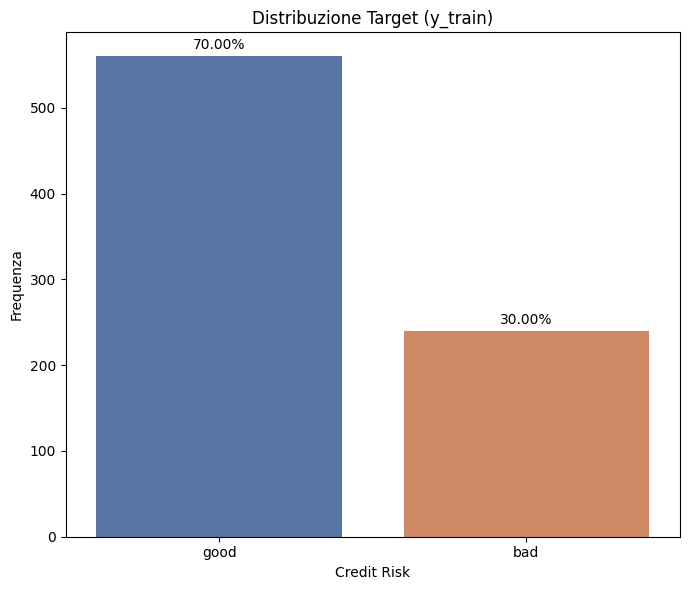

Credit_risk
good    0.7
bad     0.3
Name: proportion, dtype: float64


In [ ]:
print("\n--- EDA: Distribuzione Variabile Target (Training Set) ---")

plot_target_distribution(y_train, title="Distribuzione Target (y_train)")
print(y_train.value_counts(normalize=True))


- **Distribuzione delle Variabili Numeriche**: analizziamo la forma della distribuzione di ciascuna feature numerica usando istogrammi, grafici di densità (KDE) e box plot. Cerchiamo assimetrie (skewness) e la presenza di outliers.


--- EDA: Distribuzione Features Numeriche (Training Set) ---

Analisi Feature: Duration


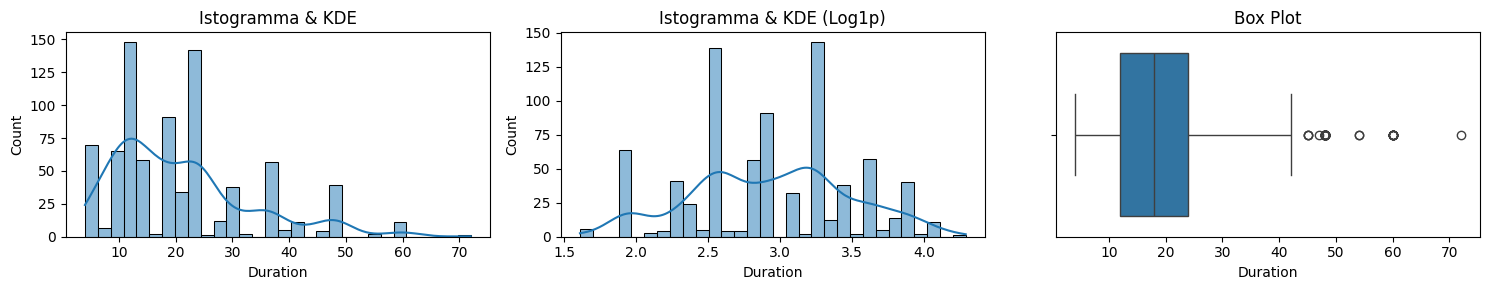

Skewness: 1.13
  -> Suggerisce trasformazione (es. log) per ridurre asimmetria.

Analisi Feature: Credit_amount


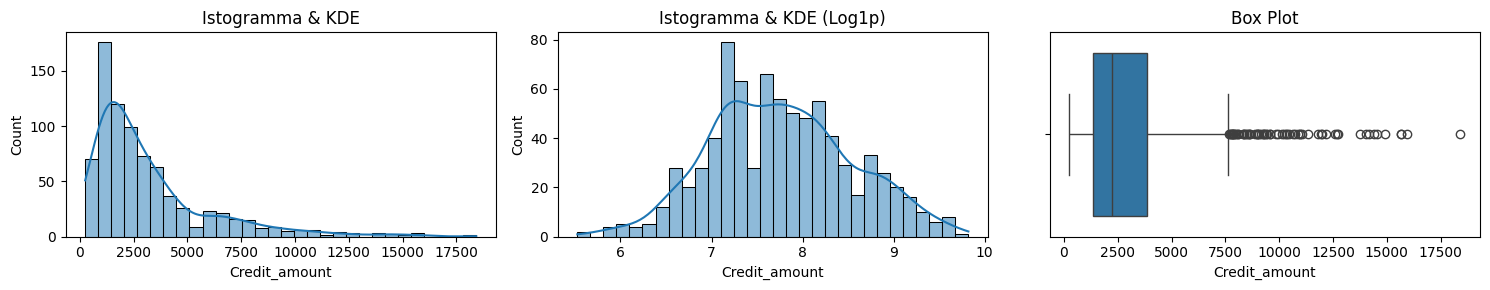

Skewness: 2.00
  -> Suggerisce trasformazione (es. log) per ridurre asimmetria.

Analisi Feature: Installment_rate


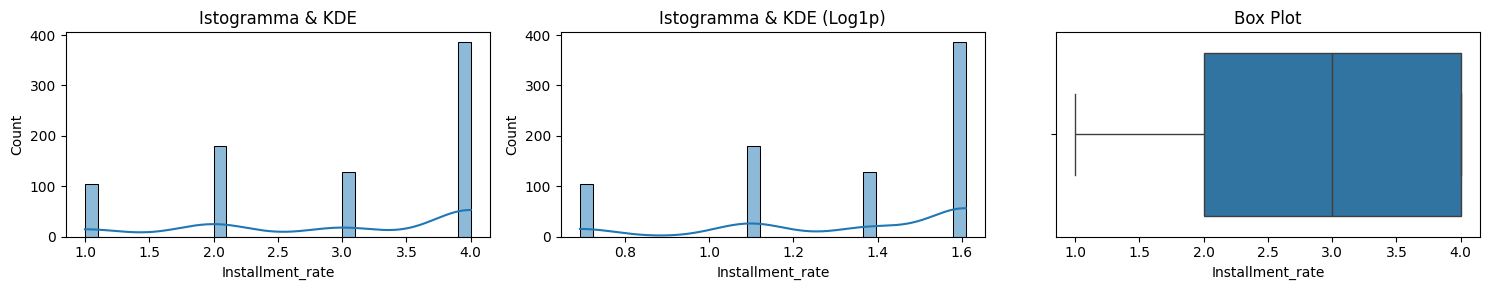

Skewness: -0.57

Analisi Feature: Residence_duration


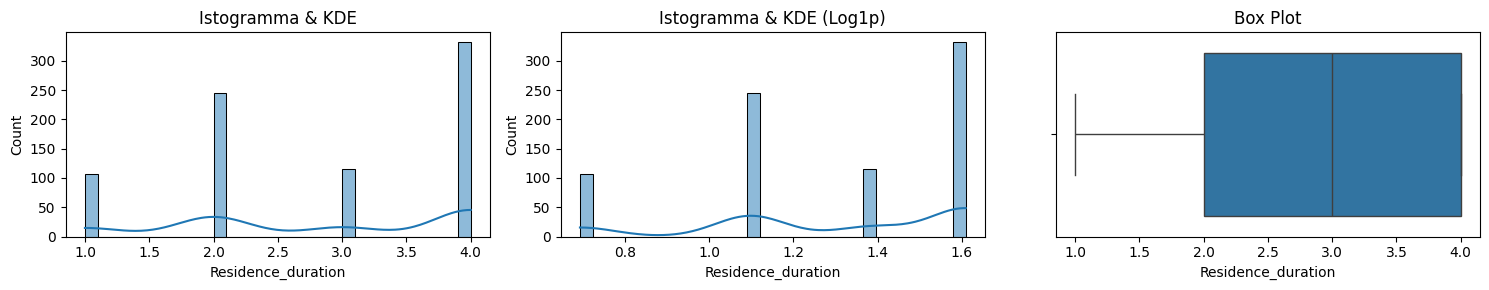

Skewness: -0.27

Analisi Feature: Age


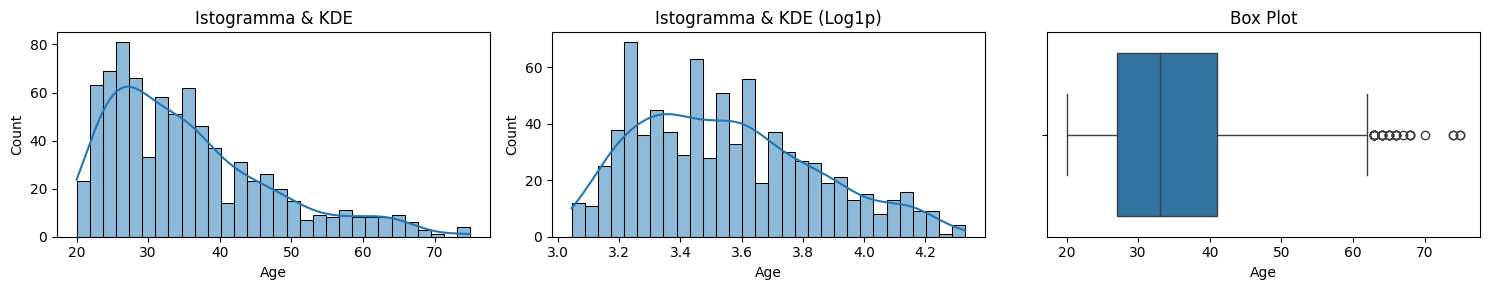

Skewness: 1.06
  -> Suggerisce trasformazione (es. log) per ridurre asimmetria.

Analisi Feature: Existing_credits_count


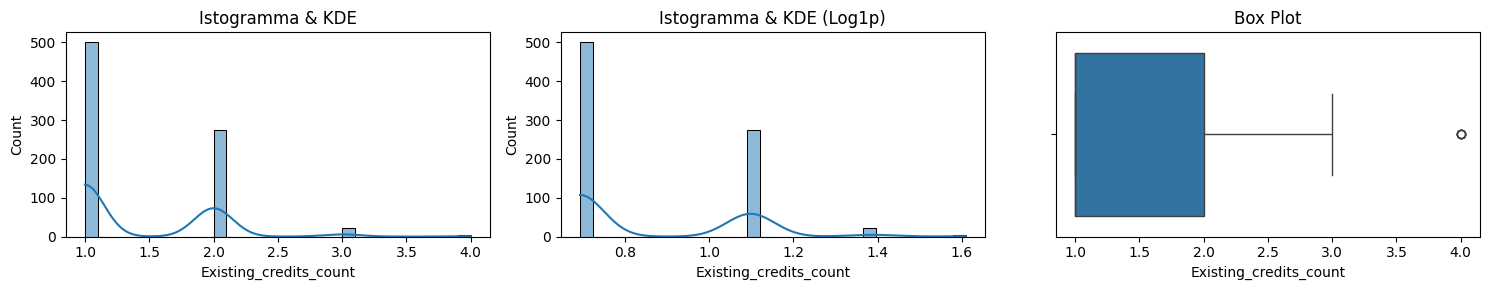

Skewness: 1.19
  -> Suggerisce trasformazione (es. log) per ridurre asimmetria.

Analisi Feature: Dependents_count


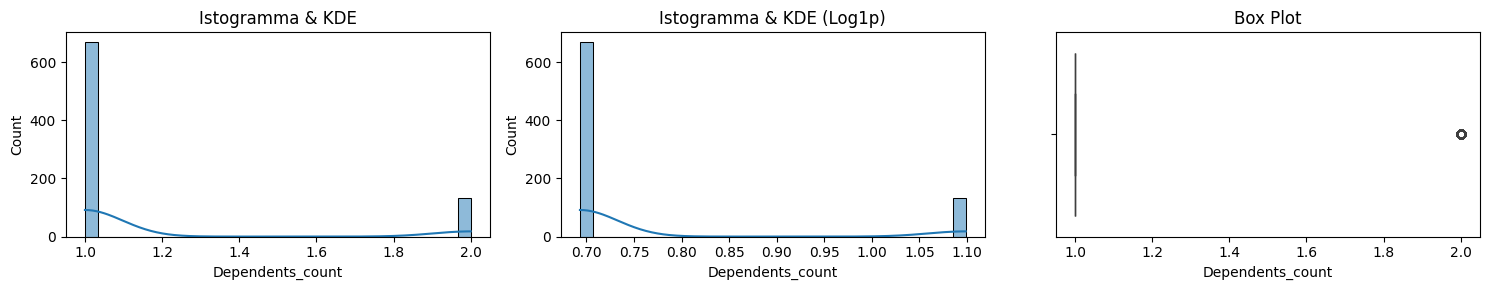

Skewness: 1.82
  -> Suggerisce trasformazione (es. log) per ridurre asimmetria.


In [ ]:
print("\n--- EDA: Distribuzione Features Numeriche (Training Set) ---")
numerical_cols_train = X_train.select_dtypes(include=np.number).columns
for col in numerical_cols_train:
    print(f"\nAnalisi Feature: {col}")
    plt.figure(figsize=(15, 3))
    plt.subplot(1, 3, 1)
    sns.histplot(X_train[col], kde=True, bins=30)
    plt.title('Istogramma & KDE')
    plt.subplot(1, 3, 2)
    sns.histplot(np.log1p(X_train[col]), kde=True, bins=30) # Visualizza effetto log
    plt.title('Istogramma & KDE (Log1p)')
    plt.subplot(1, 3, 3)
    sns.boxplot(x=X_train[col])
    plt.title('Box Plot')
    plt.tight_layout()
    plt.show()
    # Calcola skewness
    skew = X_train[col].skew()
    print(f"Skewness: {skew:.2f}")
    if abs(skew) > 0.7: # Soglia comune per skewness significativa
         print(f"  -> Suggerisce trasformazione (es. log) per ridurre asimmetria.")

Analisi distribuzioni Variabili Numeriche:


| Feature                 | Skewness | Distribuzione/Note                                      | Outliers  | Trasformazione Log Raccomandata? | Altre Considerazioni                                |
| :---------------------- | :------: | :------------------------------------------------------ | :-------- | :-------------------------------: | :-------------------------------------------------- |
| **Duration**            |  ~1.13   | Fortemente asimmetrica a destra (coda lunga)            | Sì (alti) |          **Sì (Altamente)**         | -                                                   |
| **Credit_amount**       |  ~2.00   | Estremamente asimmetrica a destra (coda molto lunga)  | Sì (alti) |         **Sì (Altamente)**       | -                                                   |
| **Installment_rate**    |  ~-0.57  | Discreta (valori 1-4), leggera asimmetria negativa    | No        |                 No                | Quasi ordinale/categorica.                          |
| **Residence_duration**  |  ~-0.27  | Discreta (valori 1-4), molto bassa asimmetria         | No        |                 No                | Quasi ordinale/categorica.                          |
| **Age**                 |  ~1.06   | Moderatamente asimmetrica a destra (coda verso anziani) | Sì (alti) |           **Sì (Benefica)**         | -                                                   |
| **Existing_credits**    |  ~1.19   | Discreta (conteggio), fortemente asimmetrica a destra | Sì (3, 4) |            No (Discutibile)         | Valutare se trattare come ordinale.               |
| **Dependents_count**    |  ~1.82   | Discreta (1, 2), estremamente concentrata su 1       | Sì (2)    |                 No                | Varianza molto bassa, potenziale scarsa utilità. |

**Legenda:**

*   **Skewness:** Indica l'asimmetria (valori > 0.5 o < -0.5 suggeriscono asimmetria significativa).
*   **Trasformazione Log Raccomandata:** Indica se l'applicazione di `log1p` è suggerita per migliorare la simmetria e ridurre l'impatto degli outliers.
*   **Altre Considerazioni:** Note aggiuntive sulla natura della variabile o possibili azioni.

- **Distribuzione delle Variabili Categoriche**


--- EDA: Distribuzione Features Categoriche (Training Set) ---


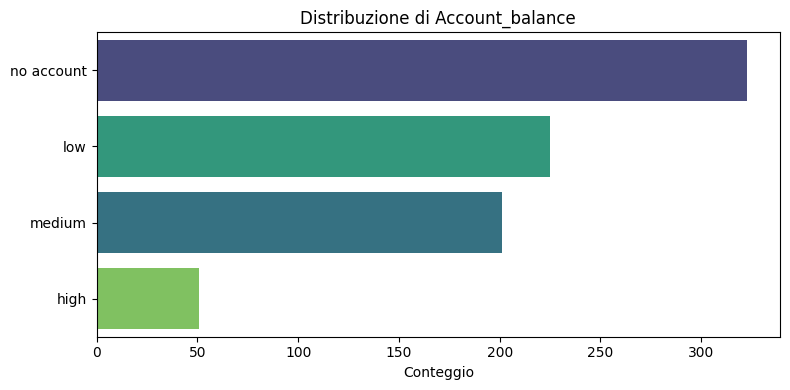

Account_balance
no account    0.404
low           0.281
medium        0.251
high          0.064
Name: proportion, dtype: float64
------------------------------


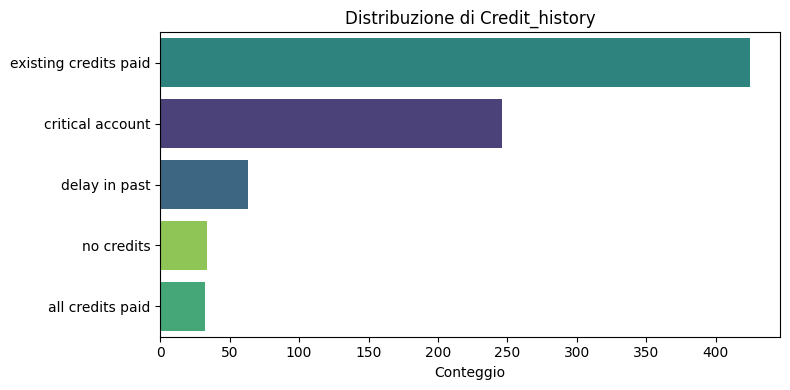

Credit_history
existing credits paid    0.531
critical account         0.308
delay in past            0.079
no credits               0.042
all credits paid         0.040
Name: proportion, dtype: float64
------------------------------


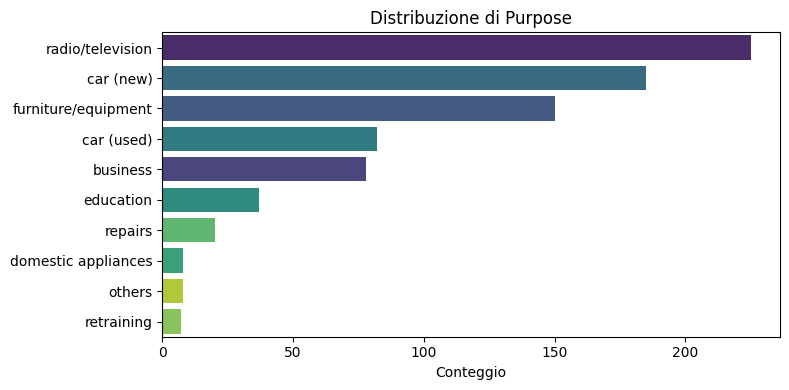

Purpose
radio/television       0.281
car (new)              0.231
furniture/equipment    0.188
car (used)             0.102
business               0.098
education              0.046
repairs                0.025
domestic appliances    0.010
others                 0.010
retraining             0.009
Name: proportion, dtype: float64
------------------------------


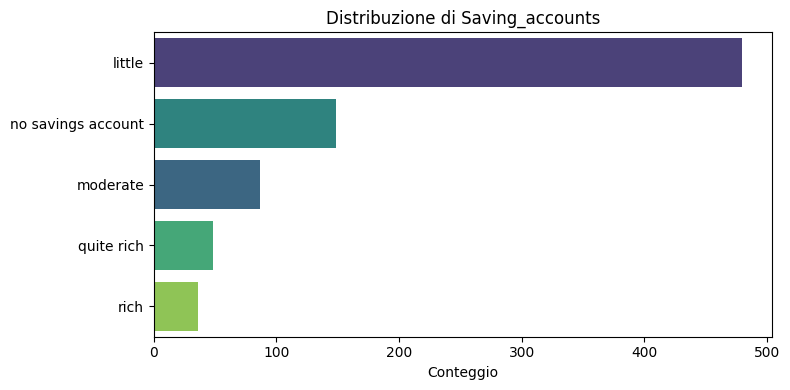

Saving_accounts
little                0.600
no savings account    0.186
moderate              0.109
quite rich            0.060
rich                  0.045
Name: proportion, dtype: float64
------------------------------


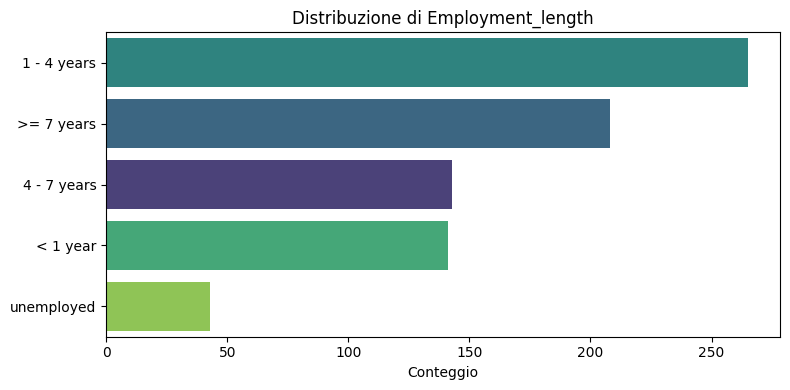

Employment_length
1 - 4 years    0.331
>= 7 years     0.260
4 - 7 years    0.179
< 1 year       0.176
unemployed     0.054
Name: proportion, dtype: float64
------------------------------


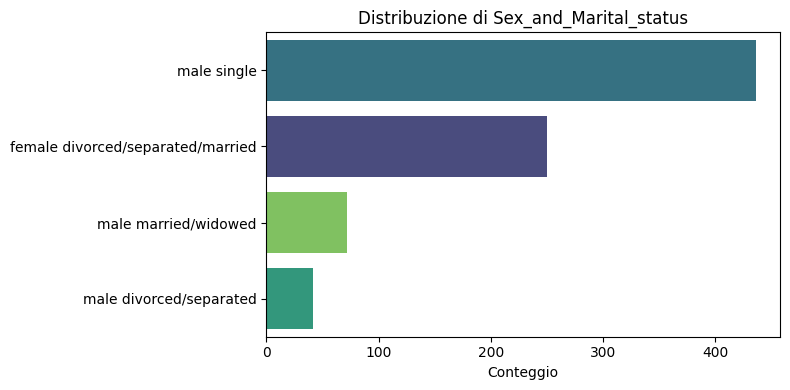

Sex_and_Marital_status
male single                          0.545
female divorced/separated/married    0.312
male married/widowed                 0.090
male divorced/separated              0.052
Name: proportion, dtype: float64
------------------------------


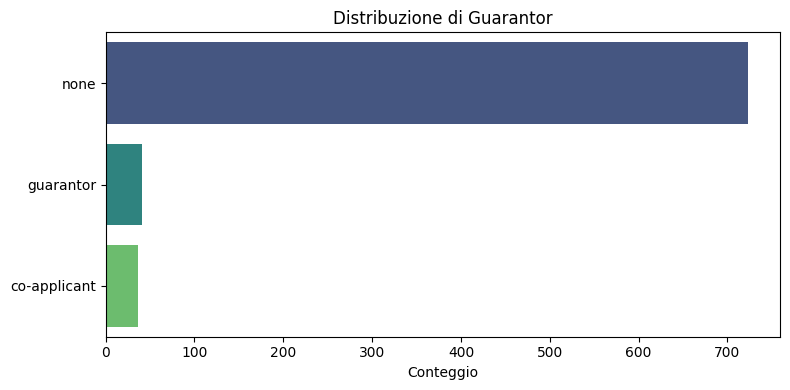

Guarantor
none            0.904
guarantor       0.051
co-applicant    0.045
Name: proportion, dtype: float64
------------------------------


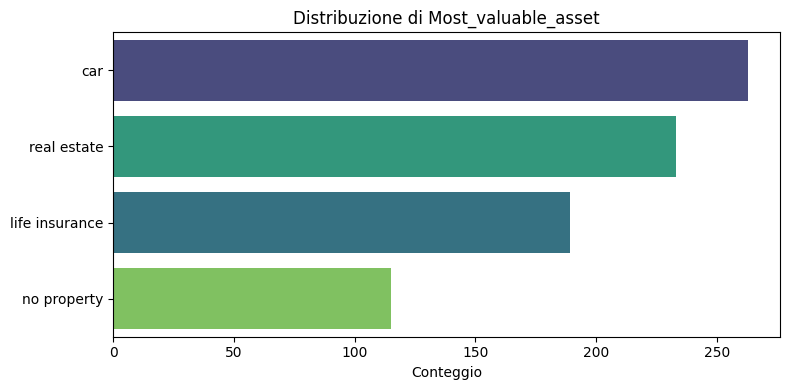

Most_valuable_asset
car               0.329
real estate       0.291
life insurance    0.236
no property       0.144
Name: proportion, dtype: float64
------------------------------


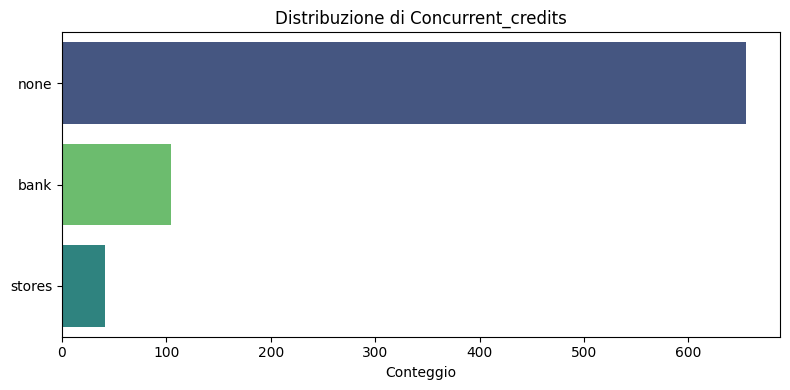

Concurrent_credits
none      0.819
bank      0.130
stores    0.051
Name: proportion, dtype: float64
------------------------------


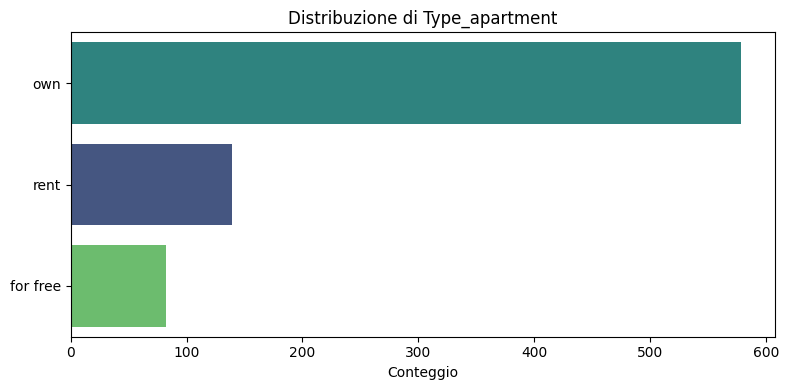

Type_apartment
own         0.724
rent        0.174
for free    0.102
Name: proportion, dtype: float64
------------------------------


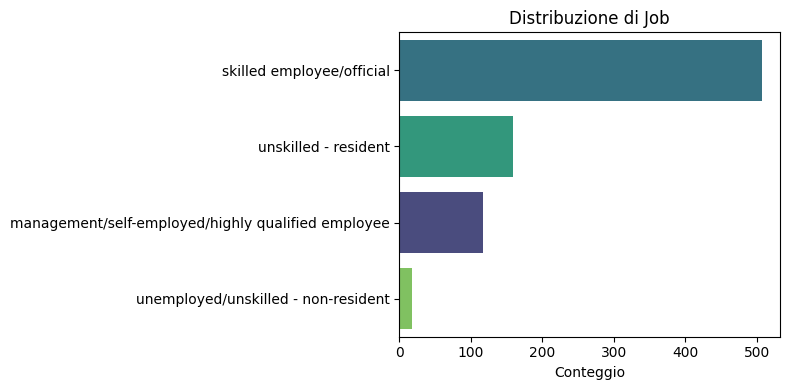

Job
skilled employee/official                             0.634
unskilled - resident                                  0.199
management/self-employed/highly qualified employee    0.146
unemployed/unskilled - non-resident                   0.021
Name: proportion, dtype: float64
------------------------------


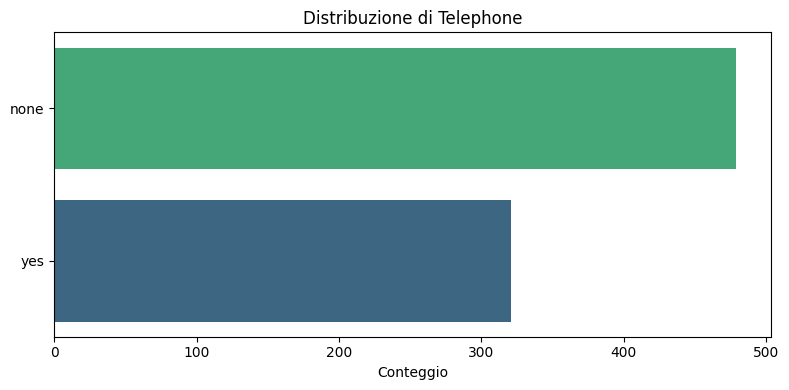

Telephone
none    0.599
yes     0.401
Name: proportion, dtype: float64
------------------------------


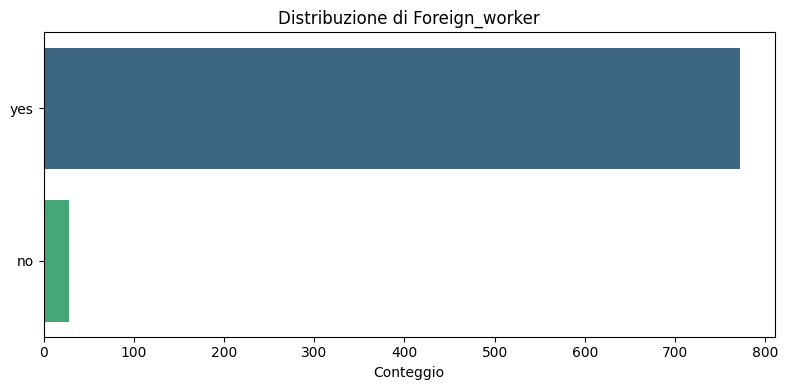

Foreign_worker
yes    0.965
no     0.035
Name: proportion, dtype: float64
------------------------------


In [ ]:
print("\n--- EDA: Distribuzione Features Categoriche (Training Set) ---")
categorical_cols_train = X_train.select_dtypes(exclude=np.number).columns
for col in categorical_cols_train:
    plt.figure(figsize=(8, 4))
    # Calcola l'ordine per visualizzare le categorie più frequenti prima
    order = X_train[col].value_counts().index
    # Fix: Pass 'y' to 'hue' and set 'legend=False'
    sns.countplot(y=X_train[col], order=order, hue=X_train[col], palette='viridis', legend=False)
    plt.title(f'Distribuzione di {col}')
    plt.xlabel('Conteggio')
    plt.ylabel('') # Rimuovi label asse y per chiarezza
    plt.tight_layout()
    plt.show()
    print(X_train[col].value_counts(normalize=True).round(3)) # Mostra proporzioni
    print("-" * 30)

Analisi delle distribuzioni delle variabili categoriche:

| Feature                  | Categoria/e Dominante/i         | Distribuzione Note                                  | Categorie Rare? | Encoding Proposto | Considerazioni                                     |
| :----------------------- | :------------------------------ | :-------------------------------------------------- | :-------------- | :----------------- | :------------------------------------------------- |
| **Account\_balance**     | `no account` (~40%), `low` (~28%) | `high` è rara (~6%)                               | Sì (`high`)     | Ordinal            | Informativa.                                       |
| **Credit\_history**      | `existing credits paid` (~53%)  | `critical account` (~21%) comune, altre < 8%      | Sì              | Ordinal            | Ordine semantico importante. Informativa.        |
| **Purpose**              | `radio/TV`, `car (new)`, `furn.`| Diverse categorie molto rare (< 3%)               | Sì              | OHE                | Raggruppare rare in 'other'?                       |
| **Saving\_accounts**     | `little` (60%)                  | `rich`, `quite rich` rare (< 10% combinate)       | Sì              | Ordinal            | Informativa.                                       |
| **Employment\_length**   | `1-4y` (~33%), `>=7y` (~26%)    | Abbastanza bilanciata (eccetto `unemployed` ~5%) | Sì (`unemployed`)| Ordinal            | -                                                  |
| **Sex\_Marital\_status** | `male single` (~55%)            | Altre categorie < 15% (eccetto `female div/mar`)  | Sì              | OHE                | **Problemi etici?**                     |
| **Guarantor**            | `none` (~90%)                   | `guarantor`, `co-applicant` molto rare (< 5%)     | Sì              | OHE                | Bassa varianza, potenziale scarsa utilità.       |
| **Most\_valuable\_asset**| `car`, `real estate`, `life ins.`| Abbastanza bilanciata, `no property` ~14%        | No              | OHE                | -                                                  |
| **Concurrent\_credits**  | `none` (~82%)                   | `bank` (~13%), `stores` (~5%)                     | Sì (`stores`)   | OHE                | Bassa varianza, potenziale scarsa utilità.       |
| **Type\_apartment**      | `own` (~72%)                    | `rent` (~17%), `for free` (~10%)                  | Sì (`for free`) | OHE                | -                                                  |
| **Job**                  | `skilled employee/official` (~63%)| `unemp/unskill-nonres` molto rara (< 2%)        | Sì              | OHE / Ordinal      | Valutare encoding ordinale (qualifica).          |
| **Telephone**            | `none` (~60%)                   | Relativamente bilanciata                          | No              | Binary (0/1)       | Valutare informatività.                            |
| **Foreign\_worker**      | `yes` (~96.5%)                  | `no` estremamente raro (< 4%)                     | Sì (`no`)       | Binary (0/1)       | Varianza bassissima, probabile scarsa utilità. |

**Legenda:**

*   **Categoria/e Dominante/i:** Le categorie con la frequenza più alta.
*   **Distribuzione Note:** Breve descrizione della distribuzione o focus su categorie specifiche.
*   **Categorie Rare?:** Indica se ci sono categorie con frequenza molto bassa.
*   **Encoding Proposto:** Il tipo di encoding più probabile (OHE: One-Hot Encoding, Ordinal, Binary).
*   **Considerazioni:** Note aggiuntive sull'informatività potenziale, problemi etici, o azioni suggerite.

### 3.3.2 Relazioni tra Variabili
Passiamo ora ad analizzare le relazioni tra coppie di variabili, con un focus particolare sulla relazione tra ciascuna feature e la variabile target.

#### Relazione tra Features Numeriche e Target (Credit_risk)
- **Visualizzazioni (KDE e Boxplot con dati separati per classe)**: ci chiediamo come la distribuzione delle features numeriche cambia tra le classi `good` e `bad`.




--- EDA: Features Numeriche vs Target (Training Set) ---

Analisi Feature: Duration vs Credit_risk


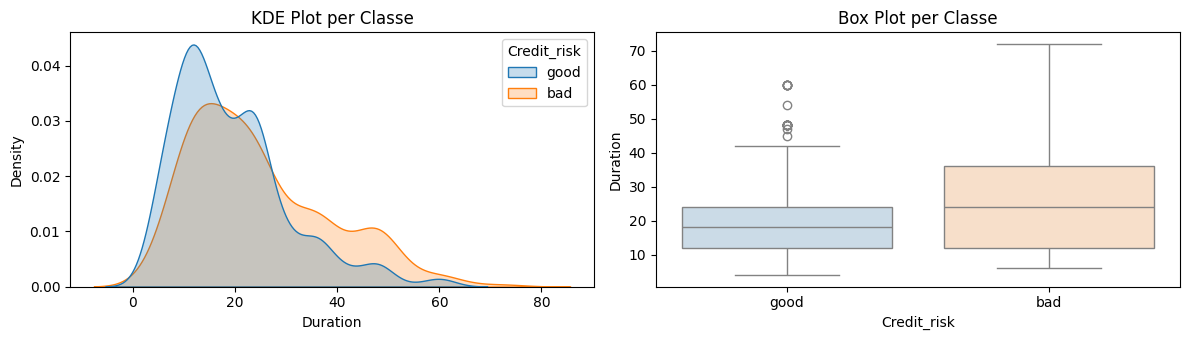


Analisi Feature: Credit_amount vs Credit_risk


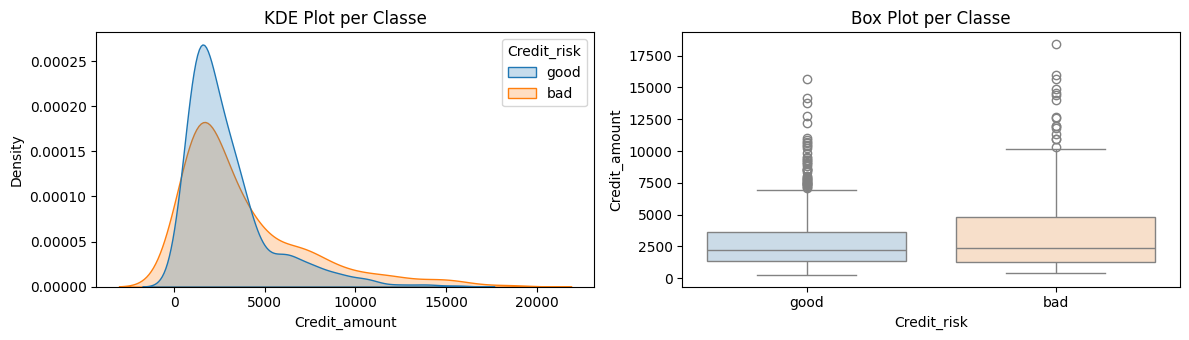


Analisi Feature: Installment_rate vs Credit_risk


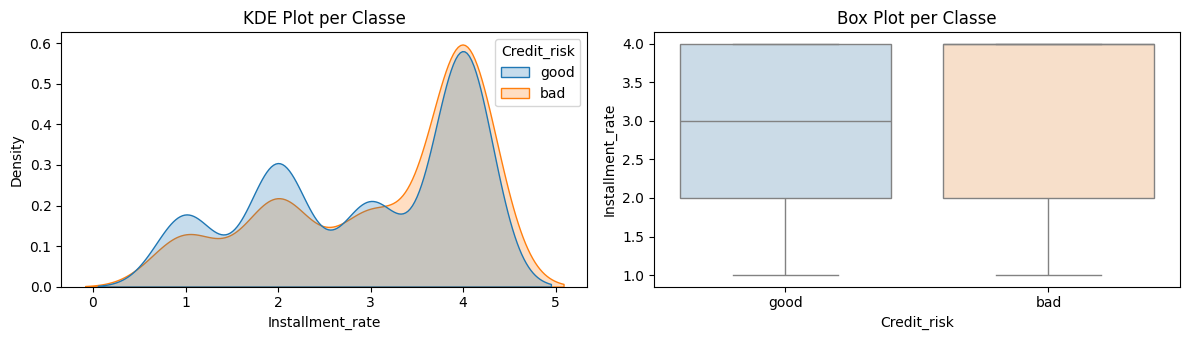


Analisi Feature: Residence_duration vs Credit_risk


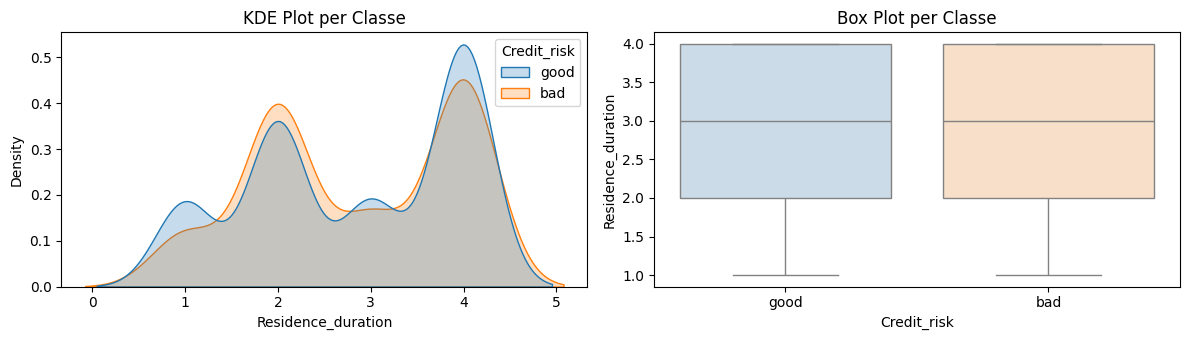


Analisi Feature: Age vs Credit_risk


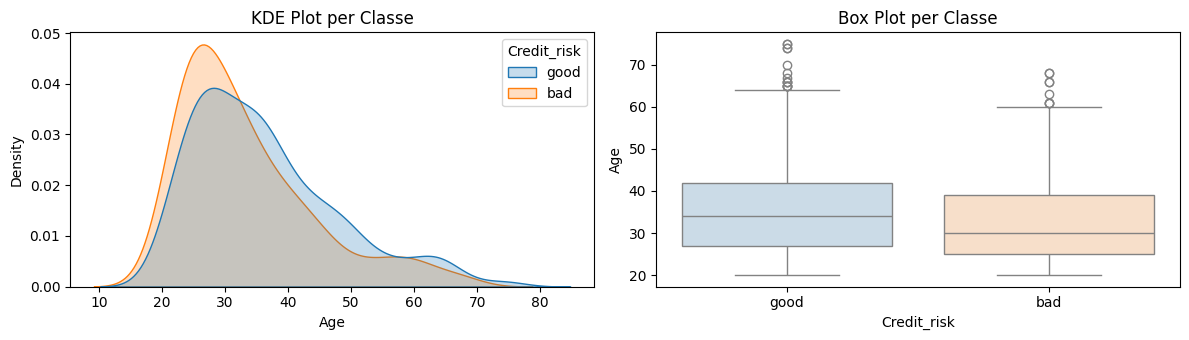


Analisi Feature: Existing_credits_count vs Credit_risk


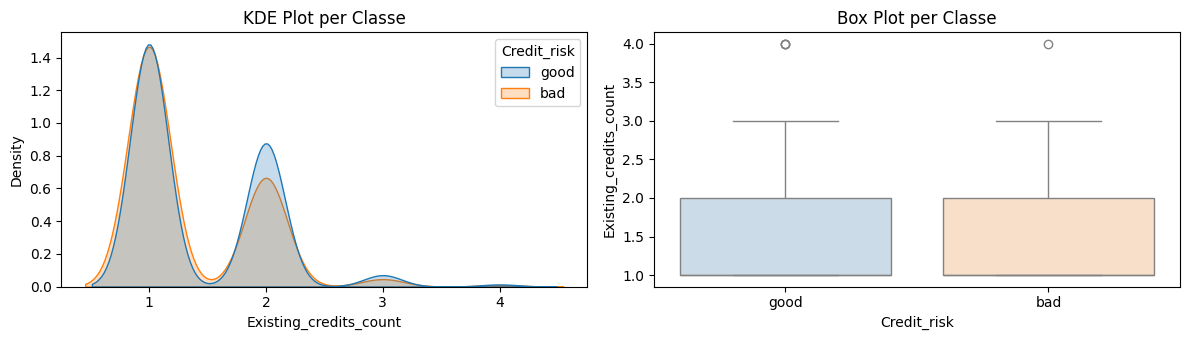


Analisi Feature: Dependents_count vs Credit_risk


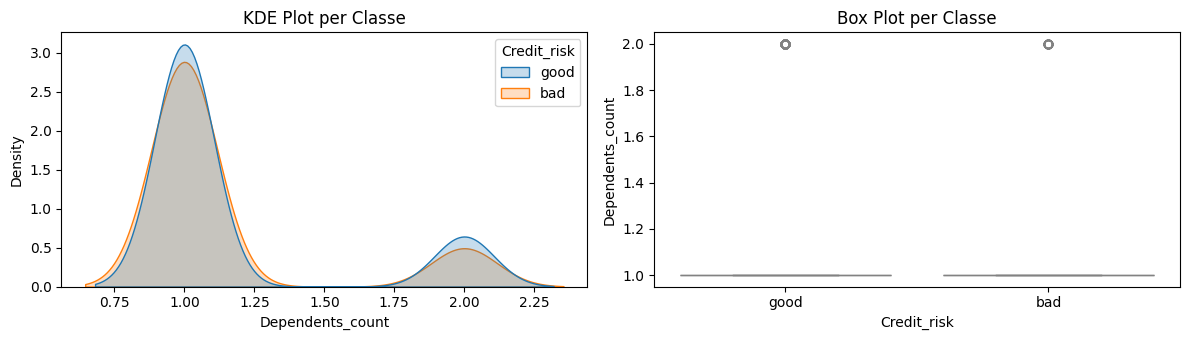

In [ ]:
print("\n--- EDA: Features Numeriche vs Target (Training Set) ---")
# Uniamo X_train e y_train per facilitare il plotting
train_df_eda = X_train.join(y_train)

for col in numerical_cols_train:
    print(f"\nAnalisi Feature: {col} vs {target_col}")
    plt.figure(figsize=(12, 3.5))
    plt.subplot(1, 2, 1)
    sns.kdeplot(data=train_df_eda, x=col, hue=target_col, fill=True, common_norm=False)
    plt.title(f'KDE Plot per Classe')
    plt.subplot(1, 2, 2)
    sns.boxplot(data=train_df_eda, y=col, x=target_col, hue=target_col, palette=['#c6dcec','#ffdec2'], legend=False)
    plt.title(f'Box Plot per Classe')
    plt.tight_layout()
    plt.show()

Aanalisi delle features numeriche rispetto alla variabile target `Credit_risk`:

| Feature                 | Relazione Osservata con `Credit_risk` ('Bad' vs 'Good')                      | Chiarezza Separazione | Potenziale Predittivo | Note Aggiuntive                                    |
| :---------------------- | :--------------------------------------------------------------------------- | :-------------------- | :-------------------- | :------------------------------------------------- |
| **Duration**            | 'Bad' ha **durate significativamente maggiori** (mediana e distribuzione spostate a dx) | Alta                  | Alto                  | Feature molto informativa.                         |
| **Credit\_amount**      | 'Bad' ha importi **leggermente maggiori** (mediana lievemente >), ma alta sovrapposizione | Bassa/Moderata        | Moderato              | Skewness/outliers richiedono trasformazione (log). |
| **Installment\_rate**   | 'Bad' ha **tassi significativamente maggiori** (specie valore 4)               | Alta                  | Alto                  | Forte indicatore di rischio.                     |
| **Residence\_duration** | Distribuzioni **quasi identiche**, nessuna differenza chiara                   | Molto Bassa           | Molto Basso           | Probabilmente non utile.                           |
| **Age**                 | 'Bad' tende ad essere **più giovane** (mediana e distribuzione spostate a sx)   | Moderata              | Moderato/Alto         | Associazione chiara.                             |
| **Existing\_credits**   | 'Bad' ha proporzione **leggermente maggiore a 2 crediti** vs 1 credito        | Bassa                 | Basso/Moderato        | Differenza sottile, ma potrebbe contribuire.     |
| **Dependents\_count**   | Distribuzioni **quasi identiche**, dominate da 1 dipendente                  | Molto Bassa           | Molto Basso           | Probabilmente non utile, considerare rimozione.  |

**Legenda:**

*   **Relazione Osservata:** Descrive la tendenza principale vista confrontando le distribuzioni 'bad' e 'good'.
*   **Chiarezza Separazione:** Valuta quanto nettamente le distribuzioni delle due classi differiscono per quella feature.
*   **Potenziale Predittivo:** Stima soggettiva dell'utilità della feature per la classificazione, basata sulla chiarezza della separazione.
*   **Note Aggiuntive:** Commenti su trasformazioni necessarie o altre considerazioni.

----


#### Anova Test
Ci chiediamo se esistano delle differenze statisticamente significative tra la media di una variabile numerica rispetto ai gruppi `good` e `bad` della variabile target (`Credit_risk`).

In [ ]:
print("\n--- EDA: Anova Test ---")
numerical_data_train = X_train[numerical_cols]
categorical_data_train = X_train[categorical_cols]

train_df_eda = X_train.join(y_train)
train_df_eda[target_col] = train_df_eda[target_col].map({'good': 0, 'bad': 1})

results_anova = {}

for col in X_train[numerical_cols]:
  formula = f'{col} ~ C(Credit_risk)' # C() indica che Credit_risk è una variabile categorica
  model = smf.ols(formula, data=train_df_eda).fit()
  anova_table = anova_lm(model, typ=2) # type=2 è spesso raccomandato

  # Estrai il p-value per la variabile target
  p_value = anova_table['PR(>F)'][f'C({target_col})']
  f_statistic = anova_table['F'][f'C({target_col})']
  results_anova[col] = {'F-statistic': f_statistic, 'p-value': p_value}

  print(f'\nANOVA test for {col}:')
  print(f"  F={f_statistic:.2f}, p-value={p_value:.4f}", end="")
  if p_value < 0.05:
      print(" -> Significativo (p < 0.05)")
  else:
      print(" -> Non Significativo (p >= 0.05)")


--- EDA: Anova Test ---

ANOVA test for Duration:
  F=34.97, p-value=0.0000 -> Significativo (p < 0.05)

ANOVA test for Credit_amount:
  F=15.54, p-value=0.0001 -> Significativo (p < 0.05)

ANOVA test for Installment_rate:
  F=4.42, p-value=0.0359 -> Significativo (p < 0.05)

ANOVA test for Residence_duration:
  F=0.00, p-value=0.9945 -> Non Significativo (p >= 0.05)

ANOVA test for Age:
  F=10.71, p-value=0.0011 -> Significativo (p < 0.05)

ANOVA test for Existing_credits_count:
  F=2.82, p-value=0.0932 -> Non Significativo (p >= 0.05)

ANOVA test for Dependents_count:
  F=0.80, p-value=0.3706 -> Non Significativo (p >= 0.05)


Il test ANOVA ha confermato che `Duration`, `Credit_amount`, `Installment_rate`, e `Age` hanno medie statisticamente diverse tra i clienti `good` e `bad`, per tanto sono delle variabili predittive importanti. Al contrario, `Residence_duration` e `Dependents_count` non risultano poco informative. Il risultato per `Existing_credits_count` è borderline, indicando che la relazione con il target, se presente, potrebbe non essere ben catturata dalla differenza delle medie.

####Feature categoriche vs Target
Vogliamo determinare se specifiche categorie sono associate a una maggiore o minore probabilità di essere classificate come `bad`.


--- EDA: Features Categoriche vs Target (Training Set) ---

Analisi Feature: Account_balance vs Credit_risk


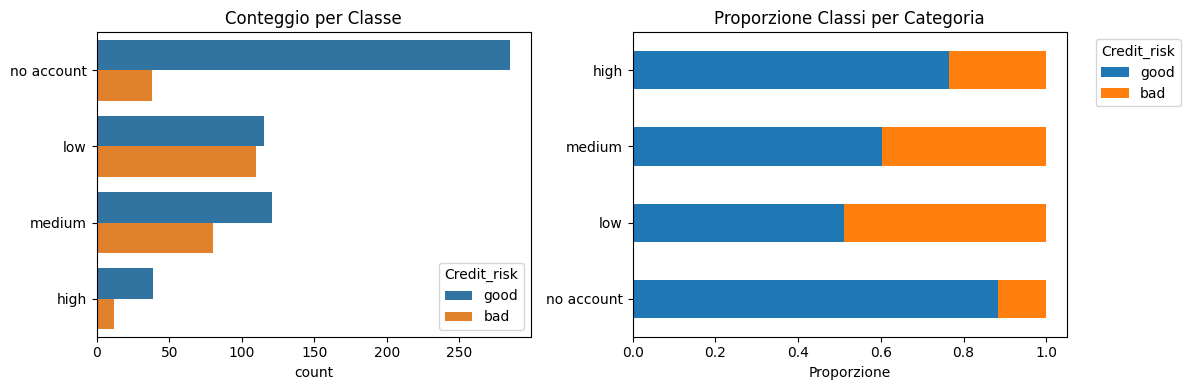

--------------------------------------------------

Analisi Feature: Credit_history vs Credit_risk


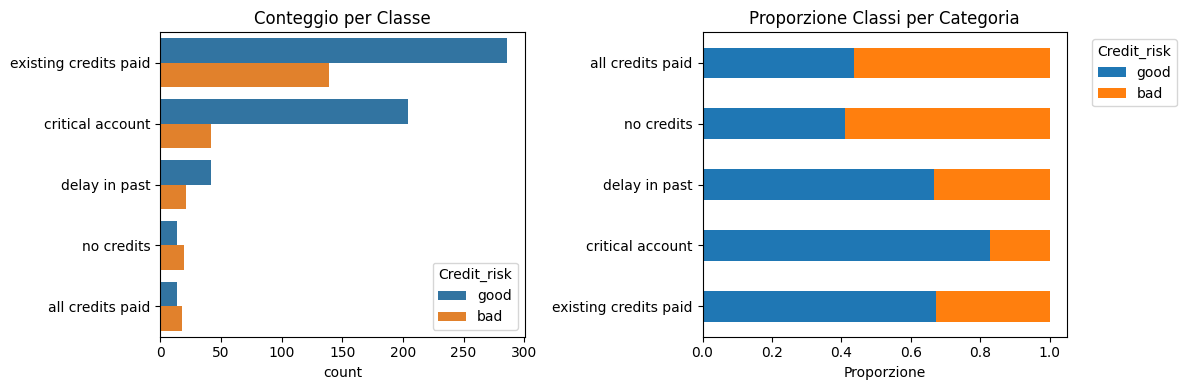

--------------------------------------------------

Analisi Feature: Purpose vs Credit_risk


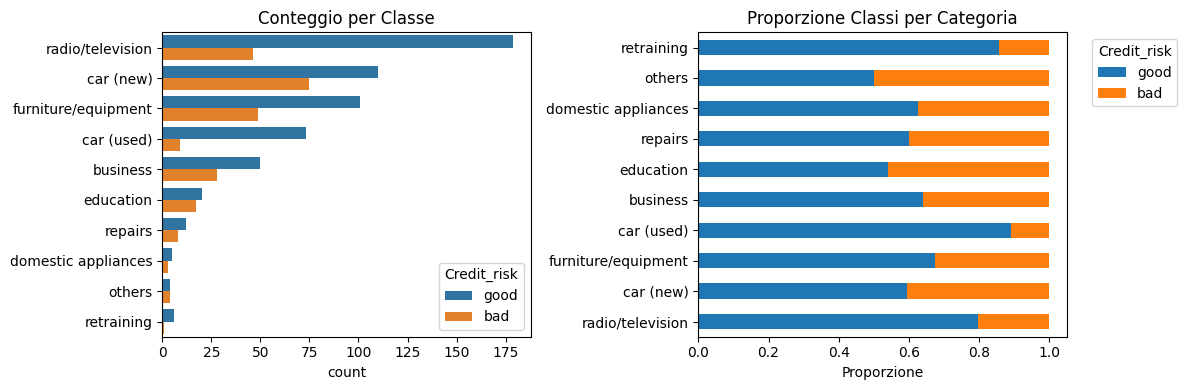

--------------------------------------------------

Analisi Feature: Saving_accounts vs Credit_risk


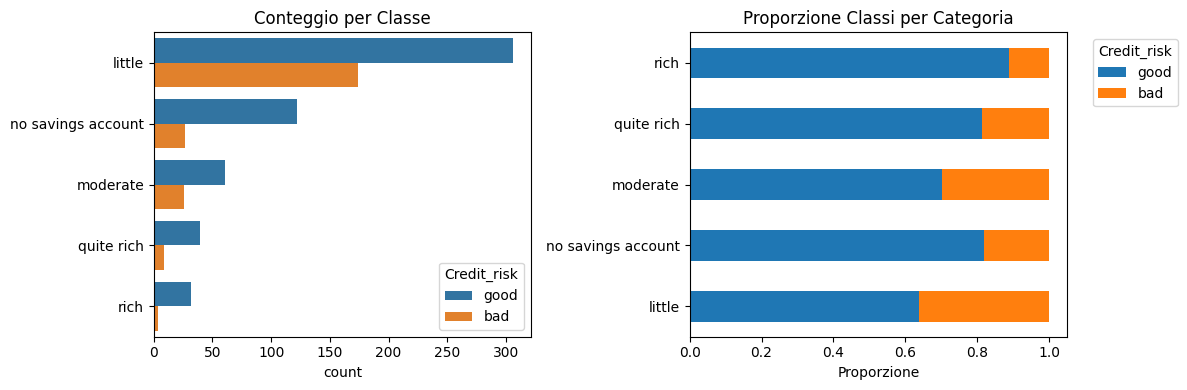

--------------------------------------------------

Analisi Feature: Employment_length vs Credit_risk


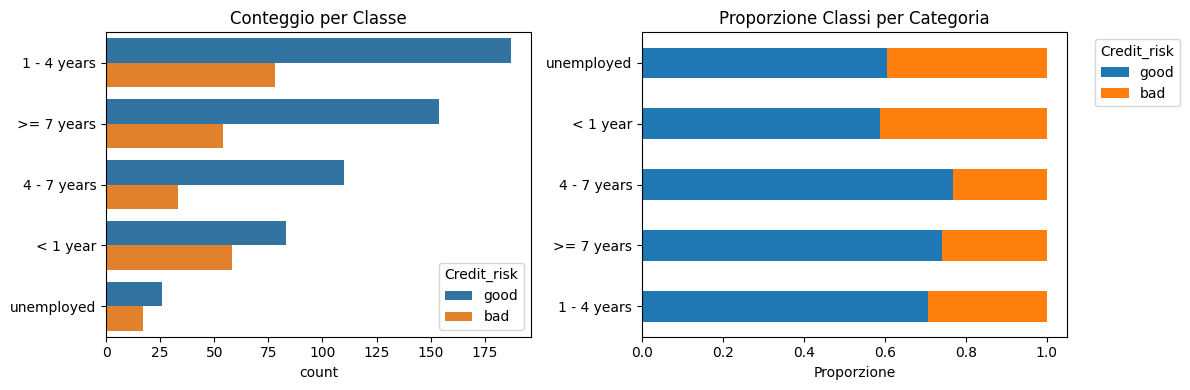

--------------------------------------------------

Analisi Feature: Sex_and_Marital_status vs Credit_risk


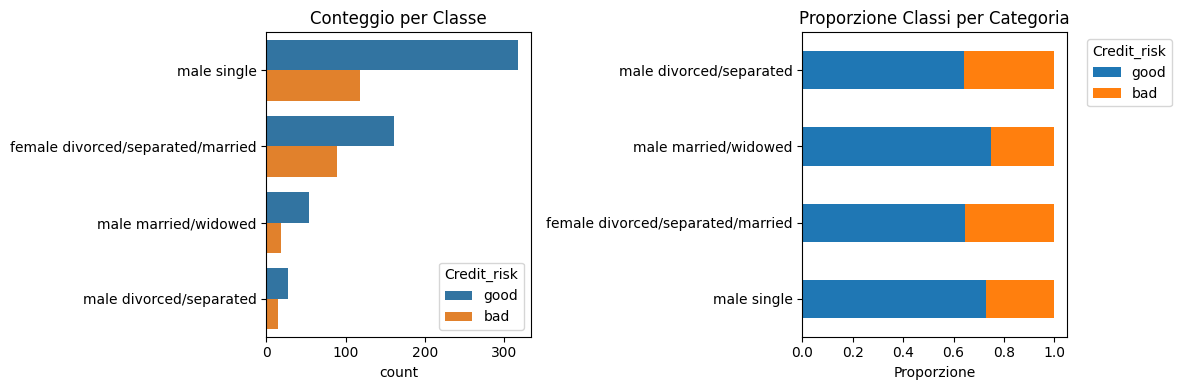

--------------------------------------------------

Analisi Feature: Guarantor vs Credit_risk


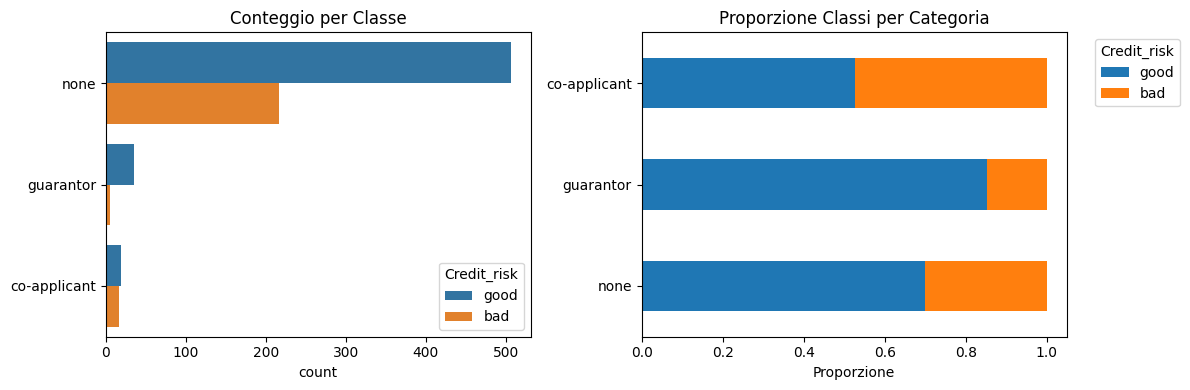

--------------------------------------------------

Analisi Feature: Most_valuable_asset vs Credit_risk


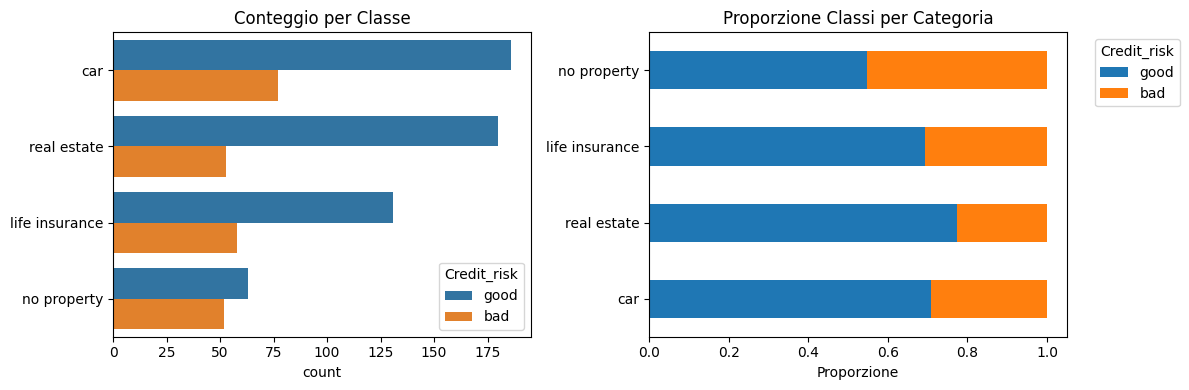

--------------------------------------------------

Analisi Feature: Concurrent_credits vs Credit_risk


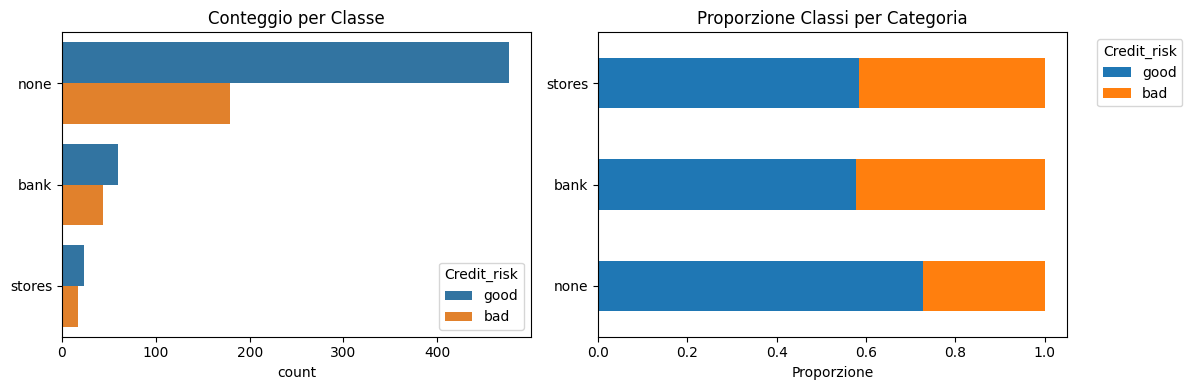

--------------------------------------------------

Analisi Feature: Type_apartment vs Credit_risk


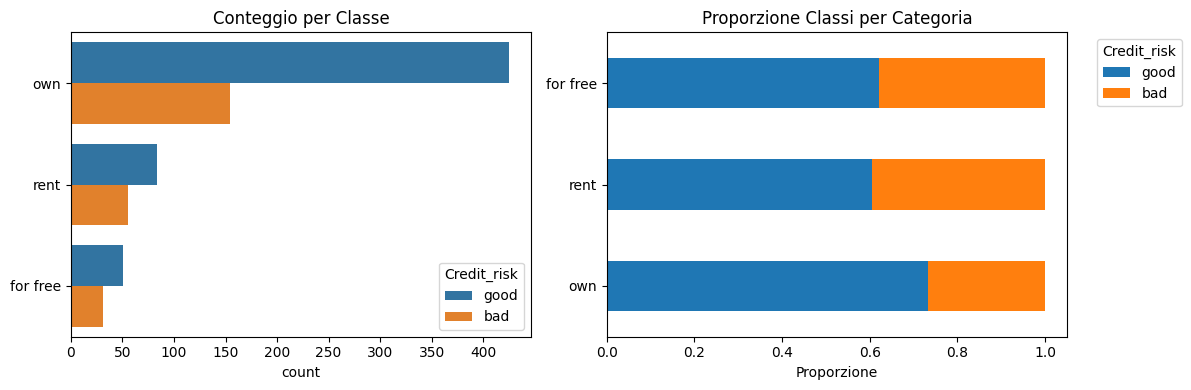

--------------------------------------------------

Analisi Feature: Job vs Credit_risk


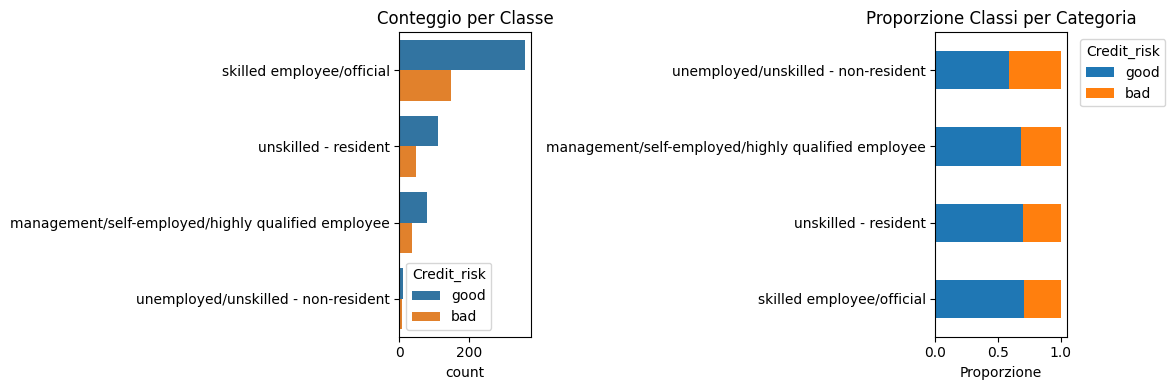

--------------------------------------------------

Analisi Feature: Telephone vs Credit_risk


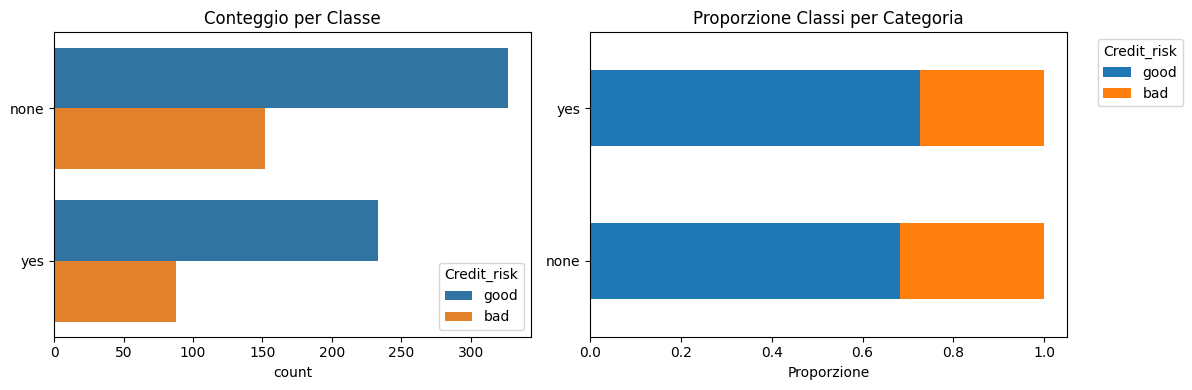

--------------------------------------------------

Analisi Feature: Foreign_worker vs Credit_risk


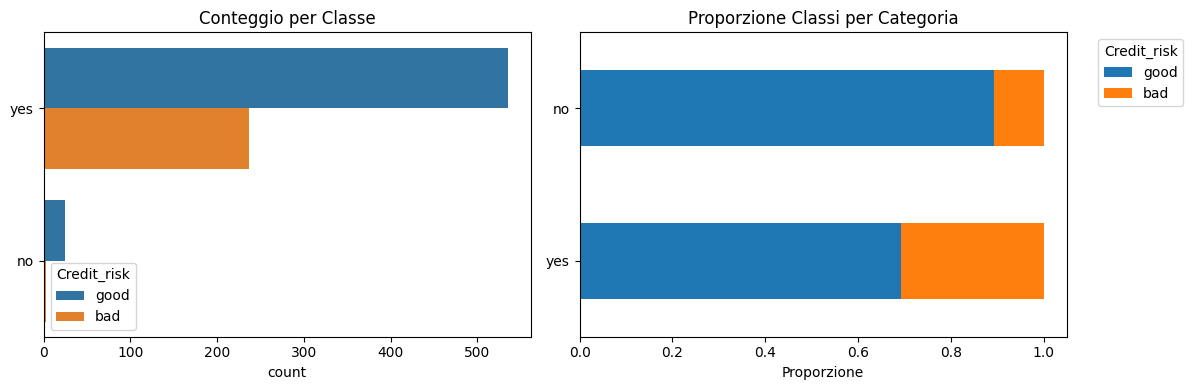

--------------------------------------------------


In [ ]:
print("\n--- EDA: Features Categoriche vs Target (Training Set) ---")
train_df_eda = X_train.join(y_train)

categorical_cols_train = X_train.select_dtypes(exclude=np.number).columns

for col in categorical_cols_train:
    print(f"\nAnalisi Feature: {col} vs {target_col}")
    plt.figure(figsize=(12, 4)) # Regola figsize secondo necessità

    # Conteggio con hue
    plt.subplot(1, 2, 1)
    order = train_df_eda[col].value_counts().index # Ordina per frequenza totale
    sns.countplot(data=train_df_eda, y=col, hue=target_col, order=order) # y per orizzontale
    plt.title('Conteggio per Classe')
    plt.ylabel('')
    plt.legend(title=target_col) # Mostra legenda qui

    # Proporzioni (Stacked bar)
    plt.subplot(1, 2, 2)
    prop_df = train_df_eda.groupby(col, observed=False)[target_col].value_counts(normalize=True).unstack().fillna(0)
    # Assicura ordine colonne 'good', 'bad'
    if 'good' not in prop_df.columns: prop_df['good'] = 0
    if 'bad' not in prop_df.columns: prop_df['bad'] = 0
    prop_df = prop_df[class_names]
    prop_df = prop_df.reindex(order) # Applica lo stesso ordine del countplot
    prop_df.plot(kind='barh', stacked=True, ax=plt.gca()) # Colori consisteni
    plt.title('Proporzione Classi per Categoria')
    plt.xlabel('Proporzione')
    plt.ylabel('')
    plt.legend(title=target_col, bbox_to_anchor=(1.05, 1), loc='upper left') # Legenda fuori asse

    plt.tight_layout()
    plt.show()
    print("-" * 50)

| Feature                  | Rischio Relativo Categorie Chiave ('Bad' > Media / 'Bad' < Media)      | Informatività Stimata | Note / Azioni Suggerite                                    |
| :----------------------- | :----------------------------------------------------------------------- | :-------------------- | :--------------------------------------------------------- |
| **Account\_balance**     | `no account`, `low` > 'Bad' -- `medium`, `high` < 'Bad'                  | Alta                  | Ordinal Encoding                           |
| **Credit\_history**      | `critical`, `delay`, `no credits` > 'Bad' -- `existing`, `all paid` < 'Bad' | Alta                  | Ordinal Encoding             |
| **Purpose**              | `business`, `edu`, `retrain`? > 'Bad' -- `radio/TV`, `car`, `furn` < 'Bad' | Moderata              | OHE. Raggruppare categorie rare?                           |
| **Saving\_accounts**     | `no savings`, `little` > 'Bad' -- `moderate`, `rich` < 'Bad'            | Alta                  | Ordinal Encoding                                |
| **Employment\_length**   | `unemployed`, `< 1 year` > 'Bad' -- `>= 7 years`, `1-4y` < 'Bad'          | Moderata              | Ordinal Encoding.                                          |
| **Sex\_Marital\_status** | Differenze lievi, `female div/sep/mar`? > 'Bad'                          | Bassa/Moderata        | **Problemi Etici/Fairness** OHE. |
| **Guarantor**            | `none` ~ Media, altre troppo rare                                      | Molto Bassa           | Bassa varianza. Considerare esclusione. OHE.             |
| **Most\_valuable\_asset**| `no property` > 'Bad' -- `real estate` < 'Bad'                          | Moderata              | OHE.                                                       |
| **Concurrent\_credits**  | `none` > 'Bad' -- `bank`, `stores` < 'Bad'                               | Bassa/Moderata        | OHE.                                                       |
| **Type\_apartment**      | `rent`, `for free` > 'Bad' -- `own` < 'Bad'                              | Moderata              | OHE.                                                       |
| **Job**                  | `unskilled`, `unemp` > 'Bad' -- `skilled`, `manage` < 'Bad'            | Moderata/Alta         | OHE o Ordinal (valutare ordine).                           |
| **Telephone**            | Nessuna differenza significativa                                         | Molto Bassa           | Binary Encoding. Considerare esclusione.                   |
| **Foreign\_worker**      | `no` (raro) > 'Bad', ma non affidabile                                   | Molto Bassa           | Bassa varianza estrema. Considerare esclusione. Binary.  |

**Legenda:**

*   **Rischio Relativo Categorie Chiave:** Indica quali categorie mostrano una proporzione della classe 'bad' significativamente sopra (>) o sotto (<) la media generale del 30%, o se non ci sono differenze (~ Media).
*   **Informatività Stimata:** Valutazione soggettiva dell'utilità della feature per la predizione.
*   **Note / Azioni Suggerite:** Commenti su encoding, problemi etici, o possibili azioni (es. raggruppamento, esclusione).

#### Chi-square Test

In [ ]:
print("\n--- EDA: Chi-square Test ---")
result_chi2 = {}

for col in X_train[categorical_cols]:
    contingency_table = pd.crosstab(train_df_eda[col], train_df_eda[target_col])
    chi2, p, dof, expected = chi2_contingency(contingency_table)
    result_chi2[col] = {'chi2': chi2, 'p-value': p, 'dof': dof}
    print(f'\nChi-square test for {col}: Chi2={chi2:.2f}, p-value={p:.4f}')
    if p < 0.05:
        print(" -> Significativo (p < 0.05)")
    else:
        print(" -> Non Significativo (p >= 0.05)")


--- EDA: Chi-square Test ---

Chi-square test for Account_balance: Chi2=99.58, p-value=0.0000
 -> Significativo (p < 0.05)

Chi-square test for Credit_history: Chi2=45.34, p-value=0.0000
 -> Significativo (p < 0.05)

Chi-square test for Purpose: Chi2=43.50, p-value=0.0000
 -> Significativo (p < 0.05)

Chi-square test for Saving_accounts: Chi2=27.95, p-value=0.0000
 -> Significativo (p < 0.05)

Chi-square test for Employment_length: Chi2=15.11, p-value=0.0045
 -> Significativo (p < 0.05)

Chi-square test for Sex_and_Marital_status: Chi2=7.03, p-value=0.0709
 -> Non Significativo (p >= 0.05)

Chi-square test for Guarantor: Chi2=9.69, p-value=0.0079
 -> Significativo (p < 0.05)

Chi-square test for Most_valuable_asset: Chi2=18.63, p-value=0.0003
 -> Significativo (p < 0.05)

Chi-square test for Concurrent_credits: Chi2=12.29, p-value=0.0021
 -> Significativo (p < 0.05)

Chi-square test for Type_apartment: Chi2=11.63, p-value=0.0030
 -> Significativo (p < 0.05)

Chi-square test for Job: C

I test confermano che molte delle variabili categoriche identificate come importanti per via grafica (`Account_balance`, `Credit_history`, `Saving_accounts`, `Purpose`, `Most_valuable_asset`, `Type_apartment`, `Concurrent_credits`, `Employment_length`) hanno un'associazione statisticamente significativa con il `Credit_risk`.

Sorprendentemente (o forse a causa di categorie rare), anche `Guarantor` e `Foreign_worker` risultano significative, anche se la loro utilità pratica rimane discutibile.

 `Sex_and_Marital_status`, `Job` e `Telephone` non mostrano un'associazione statisticamente significativa, rafforzando i dubbi sulla loro utilità predittiva.

### 3.3.3 Analisi Multivariate e Identificazione Potenziali Problemi

Fino ad ora ci siamo concentrati sulle singole variabili considerando anche la relazione il target. In questa sottosezione ci cocentraimo sulle interazioni tre le feature individuando possibili problemi.

- **Multicollinearità tra Features Numeriche**: andiamo ad indagare la correlazione lineare tra due o più variabili. Per valutare la multicollinearità tra le *features numeriche* calcoliamo la *matrice di correlazione di Person* la andiamo a visualizzare tramite una heatmap per identificare le coppie di variabili con coefficienti di correlazione elevati (generalemente, valori assoluti > 0.7 o 0.8 indicano potenziale multicollinearità).


--- Analisi Multicollinearità: Features Numeriche Originali (Training Set) ---


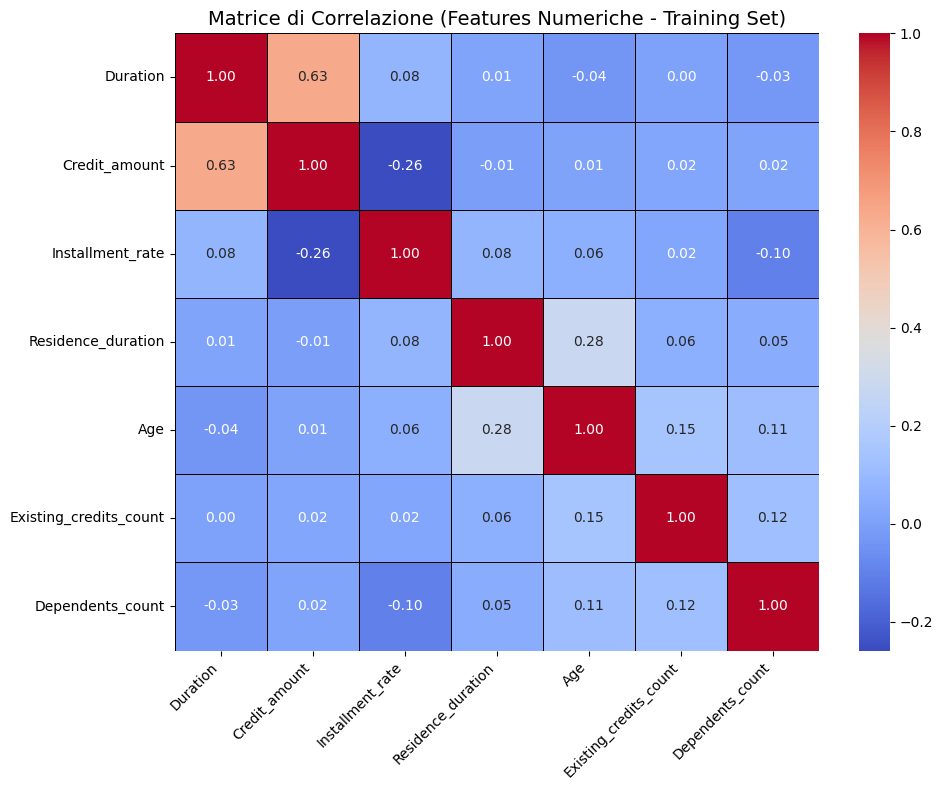

In [ ]:
print("\n--- Analisi Multicollinearità: Features Numeriche Originali (Training Set) ---")

numerical_data_train = X_train[numerical_cols]

# Calcola la matrice di correlazione
correlation_matrix = numerical_data_train.corr()

# Visualizza la heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix,
            annot=True,        # Mostra i valori nelle celle
            cmap='coolwarm',
            fmt=".2f",
            linewidths=.5,
            linecolor='black',
            cbar=True)
plt.title('Matrice di Correlazione (Features Numeriche - Training Set)', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

La correlazione lineare più elevata è quella tra `Duration` e `Credit_amount`, con un coefficiente di Person pari a **+0.63**. Tale valore indica che all'aumentare della durata del prestito tende ad aumentare l'importo richiesto (e viceversa), il che è logicamente sensato.

Considerando che in letteratura le thresold più comunemente accettate hanno valori di 0.7 o 0.8, possiamo affermare che non emergono problemi significativi di multicollinearità tre le feature numeriche. Pertanto, per quanto riguarda le variabili numeriche, non sembra necessario rimuovere alcuna feature a causa della multicollinearità. Rimane da considerare la potenziale multicollinearità che potrebbe emergere dopo l'encoding delle variabili categoriche.

>**Attenzione**: Logistic Regression è sensibile alla multicollinearità.

Oltre alla matrice di correlazione che misura le tendenze lineari, è utilie visualizzare direttamente le relazioni tra coppie di features numeriche tramite scatter plot. Questo consente di identificare:
- relazioni tre due verabili (positiva, negativa o nessuna correlazione)
- rivelare pattern non-lineari o cluster di dati (non evidenti dalla matrice di correlazione)
- identificare eventuali outlier bivariati.


--- Analisi Bivariata: Scatter Plots tra Features Numeriche (Training Set) ---


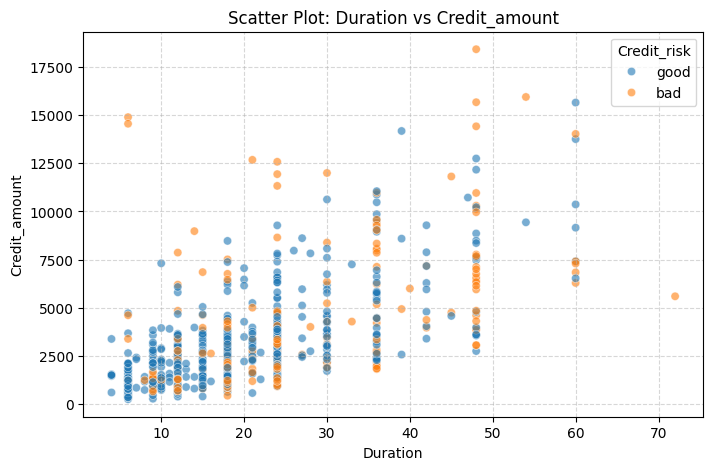

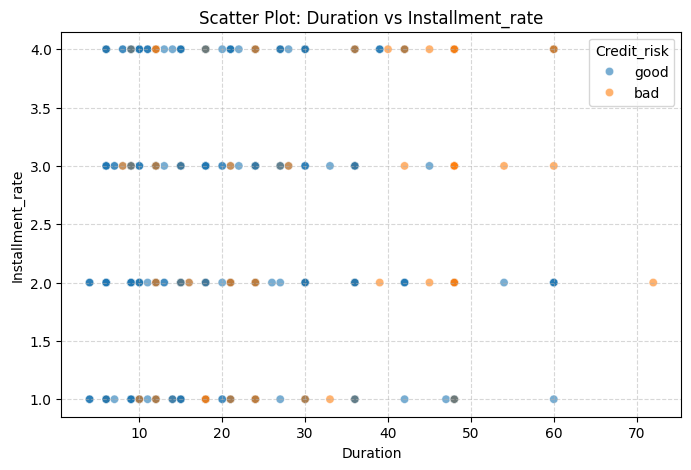

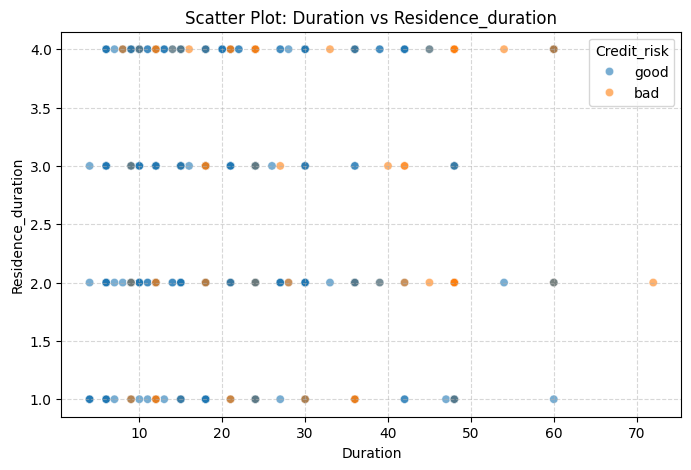

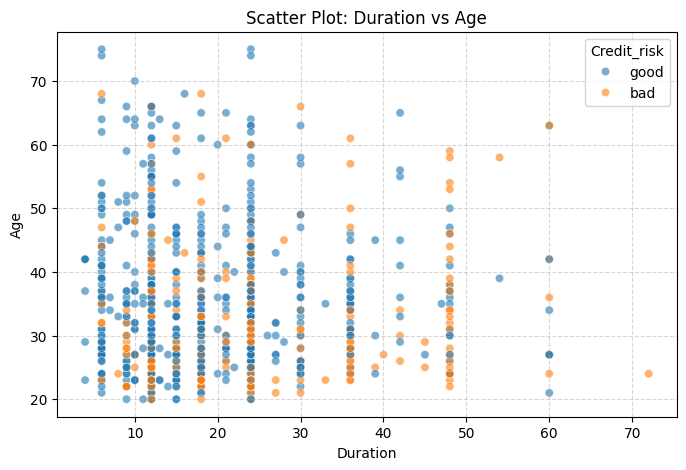

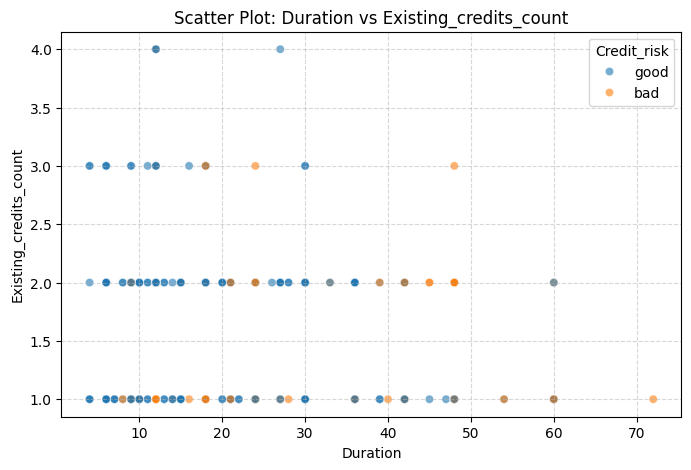

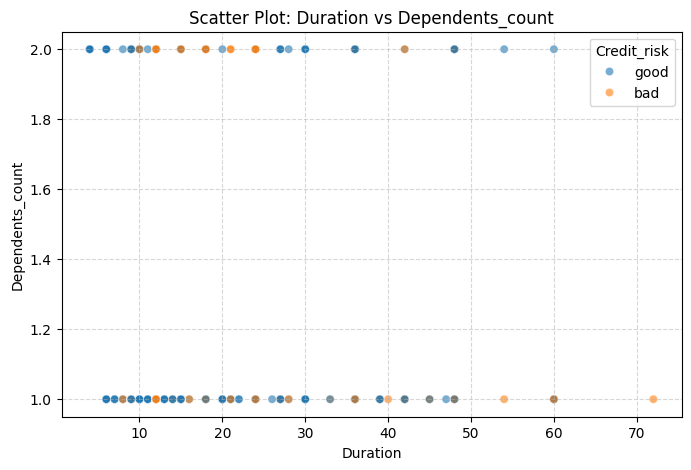

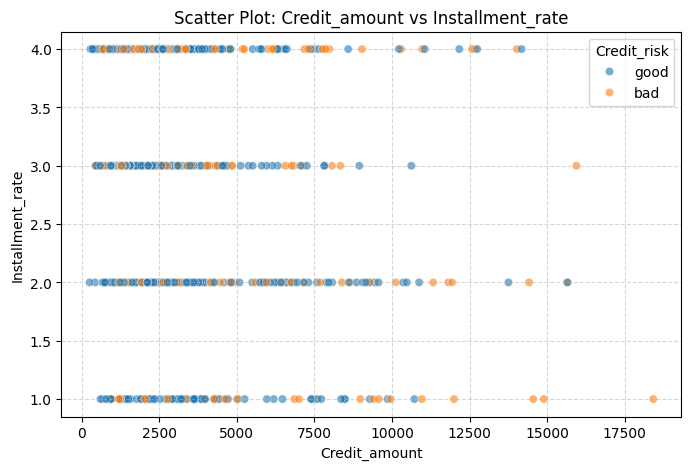

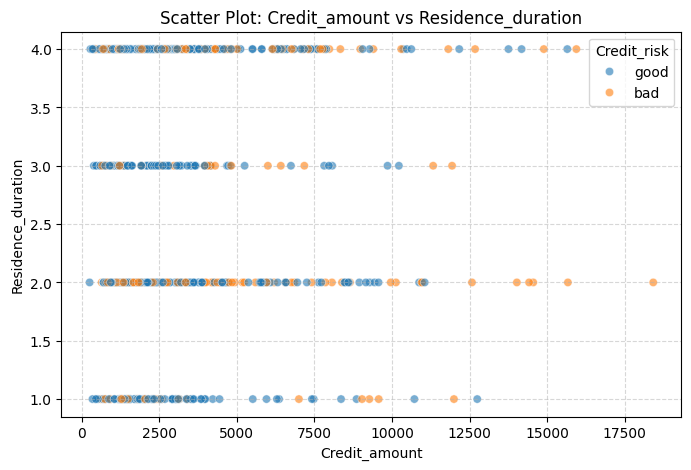

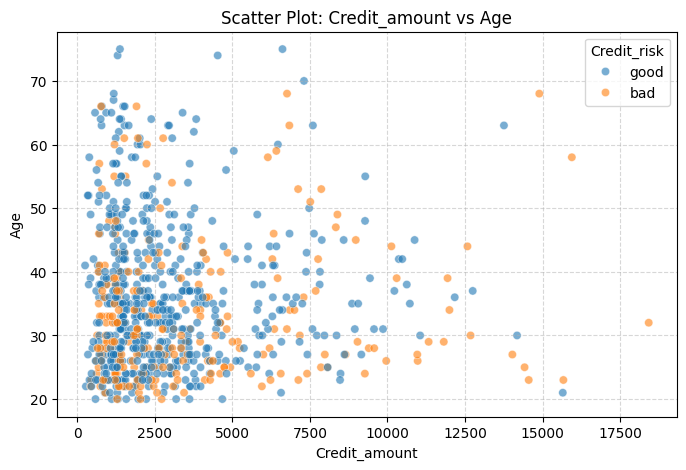

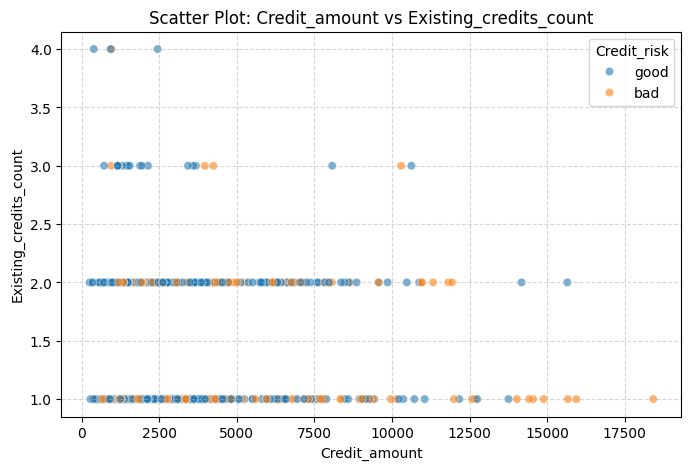

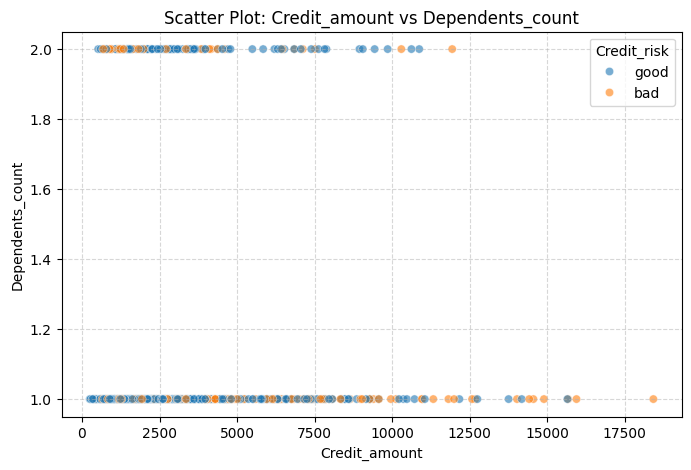

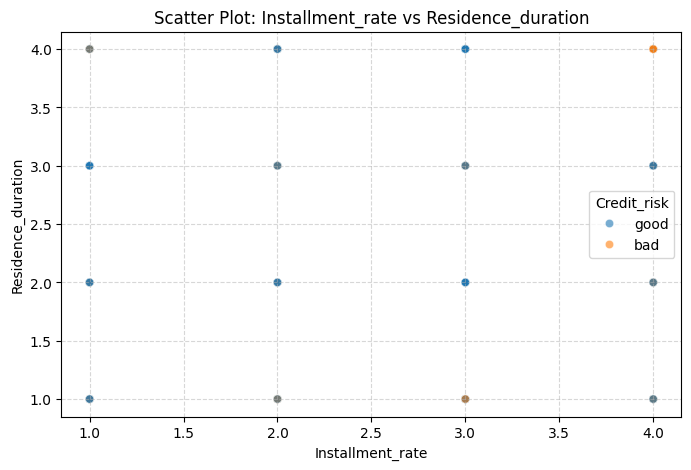

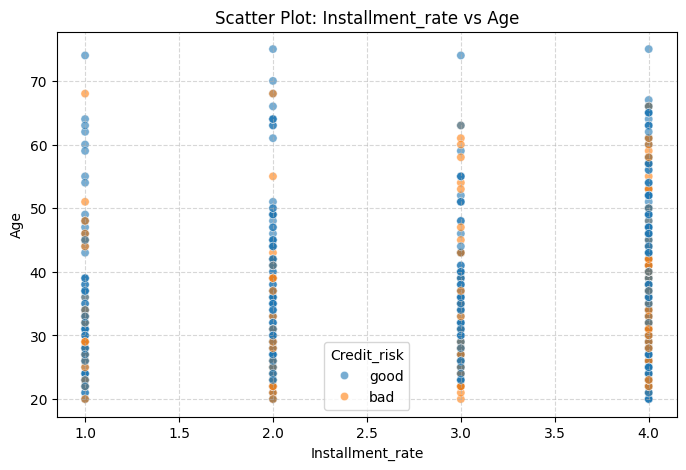

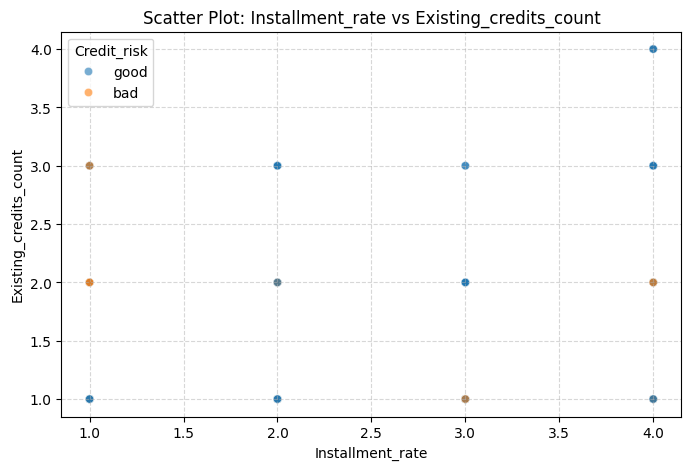

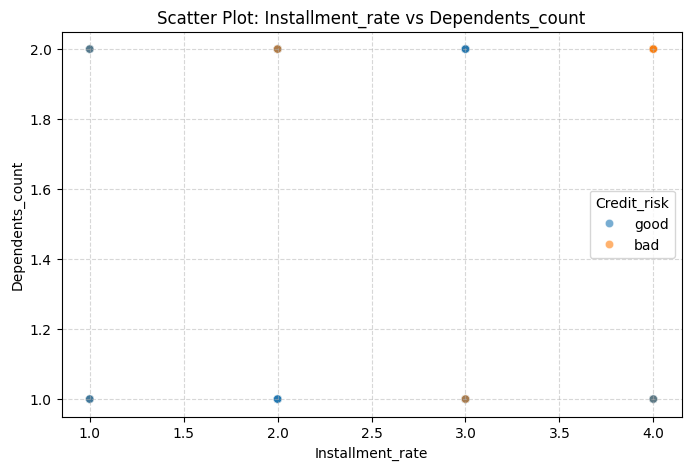

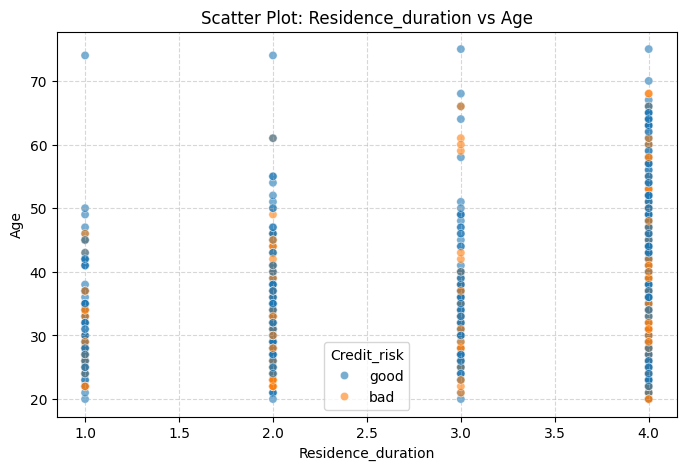

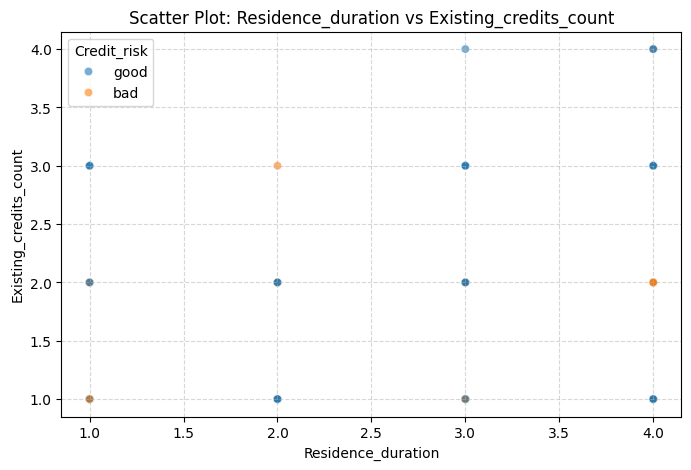

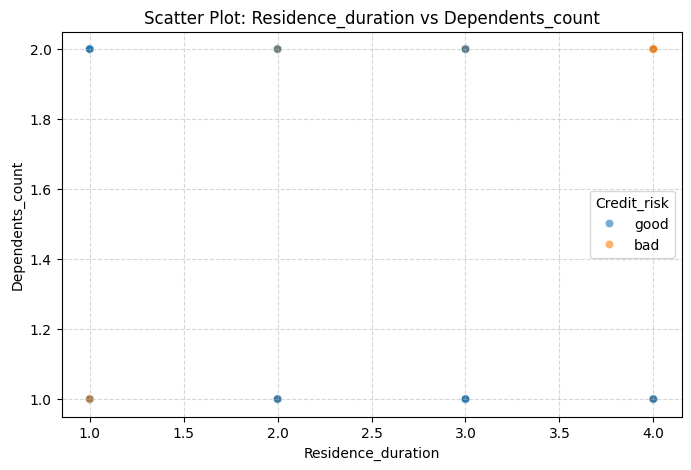

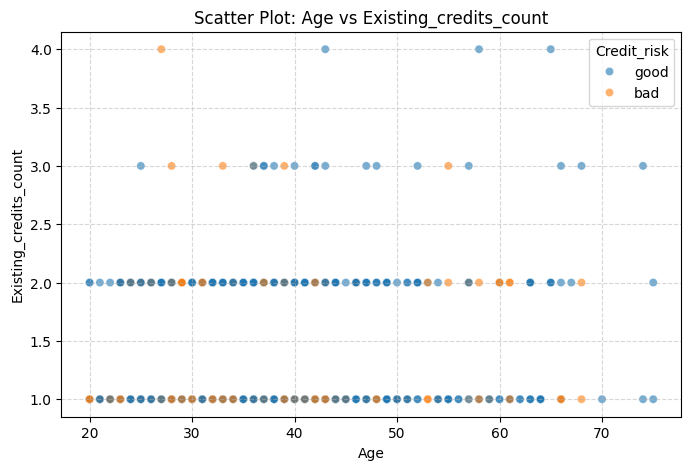

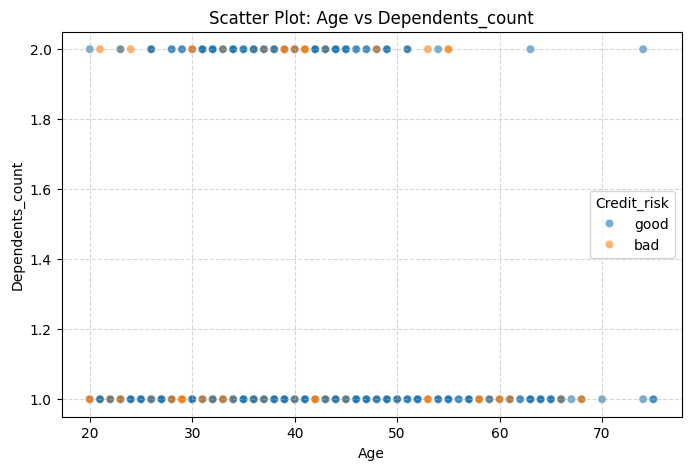

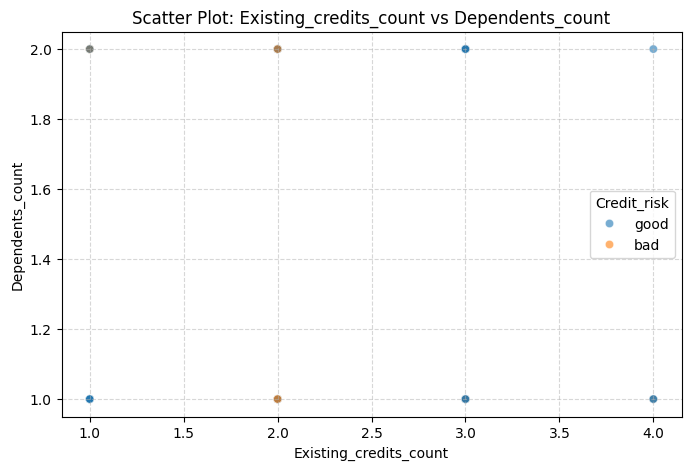

In [ ]:
print("\n--- Analisi Bivariata: Scatter Plots tra Features Numeriche (Training Set) ---")


def plot_scatterplot(data, col1, col2, target_col):
    plt.figure(figsize=(8, 5))
    sns.scatterplot(data=data, x=col1, y=col2, hue=target_col, alpha=0.6)
    plt.title(f'Scatter Plot: {col1} vs {col2}')
    plt.xlabel(col1)
    plt.ylabel(col2)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()

# Unisci con il target per il 'hue'
train_df_eda = X_train.join(y_train) # Creato precedentemente

# Usa itertools.combinations per generare tutte le coppie uniche
for col1, col2 in itertools.combinations(X_train[numerical_cols], 2):
  plot_scatterplot(train_df_eda, col1, col2, target_col)



Si osserva per **Duration vs Credit_amount** che la nuvola di punti ha una tendenza positiva in linea con quanto osservato in precedenza tramite la matrice di correlazione (+0.63)

In generale, dall'osservazione del pair plot non emergono nuove tendenze, al contrario, si conferma l'assenza di pattern non lineri, di relazioni apparentemente lineari (o assenti).

Le distribuzioni sulla diagonale sottolineano ancora una volta la necessità di trasformare (log1p) `Duration`, `Credit_amount` e `Age` per migliorare la simmetria.

Le distribuzioni e gli scatter plot relativi a `Residence_duration` e `Dependents_count` mostrano scarsa separazione tra le classi, rafforando l'idea che queste potrebbero essere candidate alla rimozione.

### 3.3.4 Sintesi EDA e Implicazioni per il Pre-processing

1. **Sbilanciamento delle Classi Target (`Credit_risk`)**:
- classe `bad` rappresenta circa il 30% del training-set.
- Di conseguenza, considerare solo l'**accuracy** come metrica è insufficiente e fuorviante. Bisogna considerare delle metriche sensibili alla classe minoritaria (`bad`), come ad esempio **F1-score (specifica per `bad`), Precision, Recall**, e visualizzare la **Matrice di confusione**. Inoltre, è possibile considerare le curve ROC AUC e Precision-Recall AUC per avere una visione d'insieme delle performance.
- Per ribilanciare il training-set si potrebbe usare delle tecniche di *resampling* o l'uso del parametro `class_weight=balanced` durante l'addestramento.

2. **Asimettria (Skewness) e Outliers nelle Variabili Numeriche**:
- `Duration`, `Credit_amount`, e in misura minore `Age`, mostrano una significativa asimmetria positiva (coda a destra) e outliers che possono influenzare negativamente le performance e la stabilità dei modelli sensibili alla distribuzione e alla scala dei dati (es. modelli lineari, SVM).
- Per mitigare tali effetti è necessario applicare una **trasformazione logaritmica** alle features `Duration`, `Credit_amount` ed eventualmente `Age`, per renderle più simmetriche e ridurre l'impatto degli outliers.

3. **Scale Diverse tra Variabili Numeriche**:
- Le variabili numeriche hanno scale di misura molto diverse.
- Ciò crea problemi a modelli basati sulla distanza come  il *gradient boosting* o *SVM*. In particolare, le featueres con scale più grandi potrebbero dominare il processo di apprendimento. Per tanto, nel pre-processing bisogna applicare lo scaling a tutte le features numeriche dopo la trasformazione log.
- Usiamo `StandardScaler` per fare si che tutte le feature siano centrate sullo 0 e abbiano deviazione standard 1.

4. **Necessità di Encoding per Variabili Categoriche**:
- Sono presenti numerose feature categoriche
- Buona parte dei modelli di ML richiedono input numerici.
- Di conseguenza, bisogna applicare le conversioni numeriche nella fase di pre-processing tenendo conto che la variabilie categorica può essere di ordinale o nominale. Per le ordinali `Account_balance`, `Credit_history`, `Saving_accounts`, `Employment_length`, si utilizzerà `OrdinalEncoder` specificando l'ordine corretto dei valori seguito dallo scaling. Per le nominali, si utilizzerà `OneHotEncoder` per creare colonne binarie facendo attenzione ad impostare `drop=first` per evitare la multicollinearità e `handle_unknown=ignore` per gestire eventuali categorie presenti nel test set ma non nel tranining set.
- **Problemi**:
  - `Foreign_worker` $(\text{p-value Chi2} < 0.05)$ risulta statisticamente significativa, ma la varianza è quasi nulla. L'associazione con target è poco rilevante. **Candidata alla rimozione** (vedi punto 5). Se mantenuta, OHE (o encoding binario).
  - `Sex_and_Marital_status $(\text{p-value Chi2 > 0.05})$: risulta non stasticamente significativa inoltre presenta delle implicazioni etiche. **Candidata alla rimozione**
  - `Job` $(\text{p-value Chi2 > 0.05})$: non stasticamente significativa secondo Chi-quadro, nonostante l'EDA suggerisce qualche differenza. La sua utilità è dubbia. **Bisogna considerare attentamente la rimozione**.

5. **Feature potenzialmente poco informative**:
- L'EDA e i test statistici hanno identificato un insieme di features con scara relazione con il target.
- La loro presenza può aggiungere una complessità e un rumore poco utile.
- `Telephone` sicuramente può essere rimossa.
- `Foreign_worker` ha $(\text{p-value Chi2} < 0.05)$, ma varianza quasi nulla. L'associazione è probabilmente spuria. Da rimuovere.
- `Residence_duration` ha ($\text{ANOVA p-value} > 0.05$, EDA piatta). Da rimuovere.
- `Dependents_count` ha $(\text{ANOVA p-value} > 0.05)$, bassa varianza, EDA piatta. Da rimuovere.
- `Sex_and_Marital_status` $(\text{p-value Chi2} > 0.05)$ e problemi etici. Da rimuovere.
- `Job` $(\text{p-value Chi2} > 0.05)$. Candidata alla rimozione
- `Guarantor` e `Existing_credits_count` hanno $(\text{p-value Chi2} > 0.05)$ sono borderline e potrebbero non avere una rilevanza pratica, per tanto si potrebbe pensare di rimuovere in fase di post-modeling con tecniche di feature selection.

6. **Multicollinearità**: bassa tra le feature originariamente numeriche, ma può essere introdotta con la conversione numerica tramite OHE per tanto è consigiabile usare `drop=first' in `OneHotEncoder`.

## 3.4 Preparazione dei dati (pre-processing)

## 4.1 Data cleaning
Applichiamo la trasformazione logaritmica a `Duration,` `Credit_amount` e `Age` poichè in fase EDA abbiamo notato una significativa assimetria positiva (skewness > ~0.7 - 1-0).

Per evitare di scartare features potenzialmente utili, in questa fase preliminare ci limitiamo a rimuovere  `Telephone` che sicuramente è poco predittiva della variabile target. Le altre features identificate come potenzialmente poco informative o problematiche (`Foreign_worker`, `Sex_and_Marital_status`, `Dependents_count`, `Residence_duration`, `Job`, `Guarantor`, `Existing_credits_count`) verranno mantenute per ora e la loro effettiva importanza verrà valutata durante la fase di **feature selection e fine-tuning**.




In [ ]:
print("--- Fase 4.1: Data Cleaning (Rimozione Colonne) ---")


cols_to_drop = ['Telephone']

print(f"Colonne identificate per la rimozione preliminare: {cols_to_drop}")

# Applica la rimozione delle colonne a X_train e X_test
X_train = X_train.drop(columns=cols_to_drop, errors='ignore')
X_test = X_test.drop(columns=cols_to_drop, errors='ignore')


# Aggiorna le liste di colonne
numerical_cols= [col for col in numerical_cols if col not in cols_to_drop]
categorical_cols = [col for col in categorical_cols if col not in cols_to_drop]
ordinal_cols = [col for col in ordinal_cols if col not in cols_to_drop]
nominal_cols = [col for col in nominal_cols if col not in cols_to_drop]

# Colonne numeriche che riceveranno il log nella pipeline
log_transform_cols = ['Duration', 'Credit_amount', 'Age']

#Colonne numeriche che necessiteranno solo di standard scaling nella pipeline
numeric_cols_to_scale = [col for col in numerical_cols if col not in log_transform_cols]




print(f"\nColonne rimosse: {cols_to_drop}")
print(f"Nuove colonne numeriche: {numerical_cols}")
print(f"Nuove colonne categoriche: {categorical_cols}")
print(f"Nuove colonne ordinali: {ordinal_cols}")
print(f"Nuove colonne nominali: {nominal_cols}")
print(f"Colonne per Log-Transform (nella pipeline): {log_transform_cols}")
print(f"Colonne per Scaling (nella pipeline): {numeric_cols_to_scale}")

display(X_train.head())

--- Fase 4.1: Data Cleaning (Rimozione Colonne) ---
Colonne identificate per la rimozione preliminare: ['Telephone']

Colonne rimosse: ['Telephone']
Nuove colonne numeriche: ['Duration', 'Credit_amount', 'Installment_rate', 'Residence_duration', 'Age', 'Existing_credits_count', 'Dependents_count']
Nuove colonne categoriche: ['Account_balance', 'Credit_history', 'Purpose', 'Saving_accounts', 'Employment_length', 'Sex_and_Marital_status', 'Guarantor', 'Most_valuable_asset', 'Concurrent_credits', 'Type_apartment', 'Job', 'Foreign_worker']
Nuove colonne ordinali: ['Account_balance', 'Credit_history', 'Saving_accounts', 'Employment_length']
Nuove colonne nominali: ['Purpose', 'Sex_and_Marital_status', 'Guarantor', 'Most_valuable_asset', 'Concurrent_credits', 'Type_apartment', 'Job', 'Foreign_worker']
Colonne per Log-Transform (nella pipeline): ['Duration', 'Credit_amount', 'Age']
Colonne per Scaling (nella pipeline): ['Installment_rate', 'Residence_duration', 'Existing_credits_count', 'Depe

,Account_balance,Duration,Credit_history,Purpose,Credit_amount,Saving_accounts,Employment_length,Installment_rate,Sex_and_Marital_status,Guarantor,Residence_duration,Most_valuable_asset,Age,Concurrent_credits,Type_apartment,Existing_credits_count,Job,Dependents_count,Foreign_worker
675,no account,30,critical account,radio/television,4530,little,4 - 7 years,4,female divorced/separated/married,none,4,car,26,none,rent,1,management/self-employed/highly qualified empl...,1,yes
703,medium,30,delay in past,business,2503,moderate,>= 7 years,4,male single,none,2,life insurance,41,stores,own,2,skilled employee/official,1,yes
12,medium,12,existing credits paid,radio/television,1567,little,1 - 4 years,1,female divorced/separated/married,none,1,car,22,none,own,1,skilled employee/official,1,yes
845,medium,21,existing credits paid,furniture/equipment,3976,no savings account,4 - 7 years,2,male single,none,3,car,35,none,own,1,skilled employee/official,1,yes
795,no account,9,existing credits paid,furniture/equipment,2301,moderate,< 1 year,2,female divorced/separated/married,none,4,life insurance,22,none,rent,1,skilled employee/official,1,yes


### 3.4.2 Data Transformation



Avendo completato la pulizia preliminare (rimozione di `Telephone`) nella sezione precedente *4.1*, costuiamo ora la **pipeline di pre-processing completa** utilizzando `sckit-learn`. Tale pipeline incapsulerà tutte le trasformazioni necessarie identificate dall'EDA:
1.  **Trasformazione Logaritmica:** per le colonne numeriche asimmetriche (`Duration`, `Credit_amount`, `Age`).
2.  **Scaling (Standardizzazione):** per tutte le colonne numeriche per portarle a media 0 e deviazione standard 1.
3.  **Encoding Ordinale:** per le colonne ordinali (`Account_balance`, `Credit_history`, `Saving_accounts`, `Employment_length`), seguito da scaling.
4.  **Encoding Nominale (One-Hot):** per le colonne nominali, con gestione delle categorie sconosciute e rimozione della prima categoria dummy per evitare multicollinearità.

L'uso di una pipeline garantisce che tutte le fasi di trasformazione vengano apprese (fittate) **esclusivamente sul training set (`X_train_cleaned`)** e poi applicate in modo identico e coerente sia al training set che al test set (`X_test`), prevenendo data leakage e assicurando la riproducibilità.

Useremo `ColumnTransformer` per applicare selettivamente le trasformazioni corrette a ciascun gruppo di colonne.

In [ ]:
print("--- Fase 4.2: Costruzione Pipeline di Pre-processing ---")

# --- Definiamo le Categorie Ordinali ---

def log_transform(x):
    return np.log1p(x)

def get_log_feature_names(function_transformer, feature_names_in):
    """Genera i nomi per le feature dopo la trasformazione log."""
    return [f"log_{col}" for col in feature_names_in]

log_transformer = FunctionTransformer(log_transform, feature_names_out=get_log_feature_names)


# Definiamo le categorie ordinali e le colonne (dal peggiore al migliore)
ordinal_categories_map = {
    'Account_balance': ['no account', 'low', 'medium', 'high'],
    'Credit_history': ['critical account', 'delay in past', 'existing credits paid', 'all credits paid', 'no credits'],
    'Saving_accounts': ['no savings account', 'little', 'moderate', 'quite rich', 'rich'],
    'Employment_length': ['unemployed', '< 1 year', '1 - 4 years', '4 - 7 years', '>= 7 years']
}

# Estrai le liste di categorie nell'ordine delle ordinal_cols
ordinal_categories_list = [ordinal_categories_map[col] for col in ordinal_cols if col in ordinal_categories_map]
# Verifica che tutte le colonne ordinali abbiano categorie definite
if len(ordinal_categories_list) != len(ordinal_cols):
    print("ATTENZIONE: Non tutte le colonne in ordinal_cols hanno categorie definite in ordinal_categories_map!")

# --- Creiamo le Pipeline per ciascun tipo di trasformazione ---

# Pipeline per Log Transform + Scaling
log_pipeline = Pipeline([
    ('log1p', FunctionTransformer(log_transform, feature_names_out=get_log_feature_names)),
    ('scaler_log', StandardScaler())
])


# Pipeline per Numeriche Standard (solo Scaling)
numeric_pipeline = Pipeline([
    ('scaler_num', StandardScaler())
])

# Pipeline per Ordinali (Encoding + Scaling)
ordinal_pipeline = Pipeline([
    ('ordinal', OrdinalEncoder(categories=ordinal_categories_list,
                               handle_unknown='use_encoded_value', # Assegna un valore specifico se trova categorie non viste nel train
                               unknown_value=-1)), # assegna -1 a categorie sconosciute
    ('scaler_ord', StandardScaler()) # Scala dopo encoding
])

# Pipeline per Nominali (One-Hot Encoding)
nominal_pipeline = Pipeline([
    ('onehot', OneHotEncoder(handle_unknown='ignore', # Ignora categorie sconosciute nel test
                             sparse_output=False, # Restituisce array numpy denso
                             drop='first')) # Evita multicollinearità (rimuove la prima categoria)
])


# Assembliamo il ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('log', log_pipeline, log_transform_cols),
        ('num', numeric_pipeline, numeric_cols_to_scale),
        ('ord', ordinal_pipeline, ordinal_cols),
        ('nom', nominal_pipeline, nominal_cols)
    ],
    remainder='passthrough', # Lascia invariate eventuali colonne non specificate
    verbose_feature_names_out=False # Usa nomi di colonna più puliti (es. `col` invece di `transf__col)
)

print("\nPipeline di pre-processing (preprocessor) definita con successo.")

# --- Applichiamo a Pipeline ai Dati (Fit su Train, Transform su Train & Test) ---
print("\nApplicazione della pipeline (fit su training, transform su training e test)...")

# Adatta il preprocessor SOLO sul training set e trasforma entrambi
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Applicazione pipeline completata.")
print(f"Dimensioni X_train processato: {X_train_processed.shape}")
print(f"Dimensioni X_test processato: {X_test_processed.shape}")

# --- 6. Ottenere Nomi Feature e Creare DataFrame ---
# Questo è importante per l'interpretabilità dei modelli successivi

feature_names_out = preprocessor.get_feature_names_out()
print(f"\nNumero di feature dopo il preprocessing: {len(feature_names_out)}")


# Converti gli array NumPy processati in  DataFrame Pandas
X_train_processed_df = pd.DataFrame(X_train_processed, columns=feature_names_out, index=X_train.index)
X_test_processed_df = pd.DataFrame(X_test_processed, columns=feature_names_out, index=X_test.index)

print("\nPrime 5 righe del Training Set Processato (DataFrame):")
display(X_train_processed_df.head())

# Verifica presenza di NaN (dopo tutte le trasformazioni)
print("\nVerifica NaN nei DataFrame processati:")
print(f"  NaN in X_train_processed_df: {X_train_processed_df.isnull().sum().sum()}")
print(f"  NaN in X_test_processed_df: {X_test_processed_df.isnull().sum().sum()}")

# --- Encoding del Target ---
print("\n--- Encoding Variabile Target ---")
# Converti y_train e y_test in numerico (es. 0 e 1) per i modelli
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train) # Adatta e trasforma su train
y_test_encoded = label_encoder.transform(y_test) # Trasforma solo su test

class_names = list(label_encoder.classes_)
print(f"\nClassi target oridinali: {class_names}")
print(f"Codifica numerica target: {dict(zip(class_names, label_encoder.transform(class_names)))}")

# Trova l'indice numerico per la classe 'bad' (utile per metriche)

bad_label_index = class_names.index('bad')
print(f"Indice numerico per 'bad': {bad_label_index}")

--- Fase 4.2: Costruzione Pipeline di Pre-processing ---

Pipeline di pre-processing (preprocessor) definita con successo.

Applicazione della pipeline (fit su training, transform su training e test)...
Applicazione pipeline completata.
Dimensioni X_train processato: (800, 36)
Dimensioni X_test processato: (200, 36)

Numero di feature dopo il preprocessing: 36

Prime 5 righe del Training Set Processato (DataFrame):


,log_Duration,log_Credit_amount,log_Age,Installment_rate,Residence_duration,Existing_credits_count,Dependents_count,Account_balance,Credit_history,Saving_accounts,...,Most_valuable_asset_no property,Most_valuable_asset_real estate,Concurrent_credits_none,Concurrent_credits_stores,Type_apartment_own,Type_apartment_rent,Job_skilled employee/official,Job_unemployed/unskilled - non-resident,Job_unskilled - resident,Foreign_worker_yes
675,0.906740,0.847376,-0.874701,0.905268,1.044365,-0.719852,-0.442509,-1.022429,-1.309127,-0.186225,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
703,0.906740,0.082595,0.644893,0.905268,-0.758207,1.035885,-0.442509,1.074861,-0.394453,0.862929,...,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0
12,-0.672812,-0.521035,-1.426168,-1.797024,-1.659492,-0.719852,-0.442509,1.074861,0.520221,-0.186225,...,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0
845,0.283408,0.679197,0.114723,-0.896260,0.143079,-0.719852,-0.442509,1.074861,0.520221,-1.235378,...,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0
795,-1.149681,-0.025872,-1.426168,-0.896260,1.044365,-0.719852,-0.442509,-1.022429,0.520221,0.862929,...,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0



Verifica NaN nei DataFrame processati:
  NaN in X_train_processed_df: 0
  NaN in X_test_processed_df: 0

--- Encoding Variabile Target ---

Classi target oridinali: ['bad', 'good']
Codifica numerica target: {'bad': np.int64(0), 'good': np.int64(1)}
Indice numerico per 'bad': 0


#4 Training classificatore binario

In questa sezione ci occupiamo dell'addestramento e della valutazione di diversi modelli di machine learning al fine di classificare il rischio di credito (`Credit_risk`).

Per farlo procediamo nel seguente modo:
1. Stabiliamo una Baseline, ovvero scegliamo alcuni classificatori standard e ne valutiamo le performance ("out-of-the box") sui dati pre-elaborati. In questo modo, abbiamo un benchmark di riferimento per comprendere la difficoltà e confrontare i risultati con i modelli più ottimizzati.
2. Miglioriamo i classificatori tramite delle tecniche di ottimizzazione degli iperparametri e strategie di gestione dello sbilanciamento delle classi.
3. Selezioniamo il classificatore finale con le migliori performance secondo le metriche di interesse (in particolare l'F1-score sulla classe `bad`).

La valutazione verrà sviluppata nel seguente modo: usiamo la cross-validation sul training set per ottenere delle stime robuste delle performance mentre la valutazione finale, in cui valutiamo la capacità di generalizzazione del modelo, viene fatta sul test-set.

## 4.1 Valutazione preliminare dei modelli (Baseline)

Prima di addentrarci nell'ottimizzazione degli iperparametri, costruiamo una baseline, ovvero prendiamo alcuni algoritmi di classificazione con le impostazioni predefinite o configurazioni standard e ne valutiamo la bontà.

Questo ci permette di confrontare rapidamente le diverse famiglie di modelli, identificare i modelli più promettenti, stabilire un benchmark che i modelli ottimizzati dovranno superare.


Valuteremo i seguenti modelli base, applicandoli ai dati già pre-elaborati nella sezione precedente:

*   **Dummy Classifier (Stratified):** Un classificatore "ingenuo" che predice le classi basandosi sulla loro distribuzione nel training set. Serve come baseline minima assoluta; qualsiasi modello utile deve performare significativamente meglio.
*   **Logistic Regression:**
*   **Decision Tree Classifier:** (rischio overfitting)
*   **Random Forest Classifier:** (robusto; buone performance)
*   **Support Vector Machine (SVC con kernel RBF):** (buone performance; cattura relazioni non-lineari)
*   **AdaBoost Classifier:** Un algoritmo di boosting che combina sequenzialmente weak learners.
*   **XGBoost Classifier:** Un'implementazione ottimizzata e regolarizzata del Gradient Boosting, spesso molto performante.

Per ciascun modello, utilizzeremo la funzione `evaluate_models` per eseguire la cross-validation stratificata a 10 fold sul traning-set e la valutazione finale sul test-set. Ci concentreremo su diverse metriche, con particolare attenzione all'**F1-score (bad)** e l'**accuracy** complessiva.



=============== SEZIONE 5.1: VALUTAZIONE PRELIMINARE MODELLI ===============

==================== Dummy Classifier ====================
Cross-Validation (10-fold) Results:
  Accuracy       : 0.5825 (±0.0548)
  F1(good)       : 0.7018 (±0.0392)
  F1(bad)        : 0.3042 (±0.0914)
  F1(w)          : 0.5825 (±0.0548)

Test Set Results:
  Accuracy:        0.5500
  F1 Score (good):  0.6786
  F1 Score (bad):  0.2500
  F1 Score (w):    0.5500
  --- Metriche per classe 'bad' ---
  Precision (bad): 0.2500
  Recall (bad):    0.2500


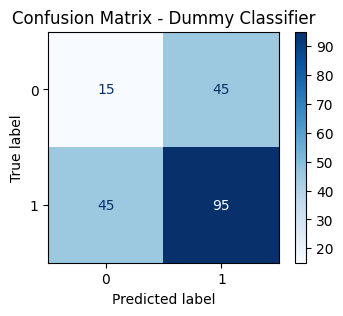


==================== Logistic Regression ====================
Cross-Validation (10-fold) Results:
  Accuracy       : 0.7250 (±0.0539)
  F1(good)       : 0.8183 (±0.0350)
  F1(bad)        : 0.4306 (±0.1236)
  F1(w)          : 0.7020 (±0.0603)

Test Set Results:
  Accuracy:        0.7100
  F1 Score (good):  0.8014
  F1 Score (bad):  0.4630
  F1 Score (w):    0.6998
  --- Metriche per classe 'bad' ---
  Precision (bad): 0.5208
  Recall (bad):    0.4167


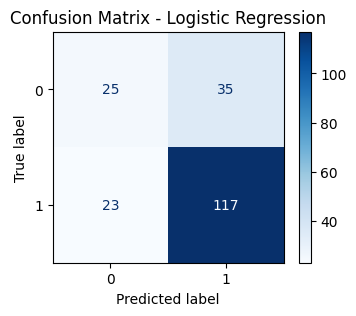


==================== Decision Tree ====================
Cross-Validation (10-fold) Results:
  Accuracy       : 0.6787 (±0.0447)
  F1(good)       : 0.7669 (±0.0363)
  F1(bad)        : 0.4739 (±0.0856)
  F1(w)          : 0.6790 (±0.0441)

Test Set Results:
  Accuracy:        0.6950
  F1 Score (good):  0.7814
  F1 Score (bad):  0.4959
  F1 Score (w):    0.6957
  --- Metriche per classe 'bad' ---
  Precision (bad): 0.4918
  Recall (bad):    0.5000


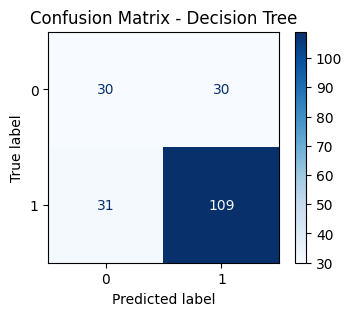


==================== Random Forest ====================
Cross-Validation (10-fold) Results:
  Accuracy       : 0.7525 (±0.0536)
  F1(good)       : 0.8379 (±0.0343)
  F1(bad)        : 0.4722 (±0.1300)
  F1(w)          : 0.7282 (±0.0615)

Test Set Results:
  Accuracy:        0.7250
  F1 Score (good):  0.8208
  F1 Score (bad):  0.4086
  F1 Score (w):    0.6972
  --- Metriche per classe 'bad' ---
  Precision (bad): 0.5758
  Recall (bad):    0.3167


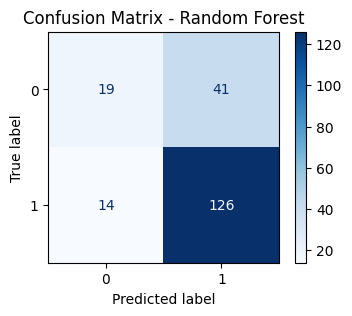


==================== SVM (RBF) ====================
Cross-Validation (10-fold) Results:
  Accuracy       : 0.7450 (±0.0522)
  F1(good)       : 0.8362 (±0.0330)
  F1(bad)        : 0.4210 (±0.1314)
  F1(w)          : 0.7116 (±0.0613)

Test Set Results:
  Accuracy:        0.7200
  F1 Score (good):  0.8182
  F1 Score (bad):  0.3913
  F1 Score (w):    0.6901
  --- Metriche per classe 'bad' ---
  Precision (bad): 0.5625
  Recall (bad):    0.3000


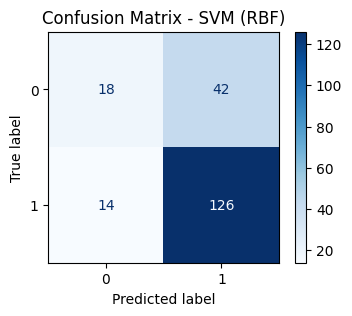


==================== AdaBoost ====================
Cross-Validation (10-fold) Results:
  Accuracy       : 0.7362 (±0.0574)
  F1(good)       : 0.8236 (±0.0389)
  F1(bad)        : 0.4709 (±0.1264)
  F1(w)          : 0.7178 (±0.0625)

Test Set Results:
  Accuracy:        0.6800
  F1 Score (good):  0.7793
  F1 Score (bad):  0.4182
  F1 Score (w):    0.6710
  --- Metriche per classe 'bad' ---
  Precision (bad): 0.4600
  Recall (bad):    0.3833


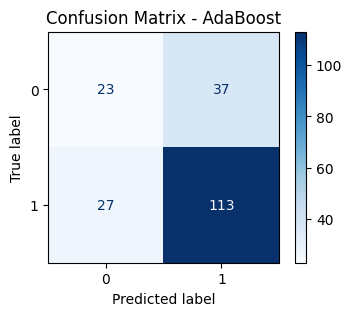


==================== XGBoost ====================
Cross-Validation (10-fold) Results:
  Accuracy       : 0.7488 (±0.0595)
  F1(good)       : 0.8257 (±0.0435)
  F1(bad)        : 0.5425 (±0.1116)
  F1(w)          : 0.7407 (±0.0605)

Test Set Results:
  Accuracy:        0.6950
  F1 Score (good):  0.7845
  F1 Score (bad):  0.4786
  F1 Score (w):    0.6927
  --- Metriche per classe 'bad' ---
  Precision (bad): 0.4912
  Recall (bad):    0.4667


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [06:53:51] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


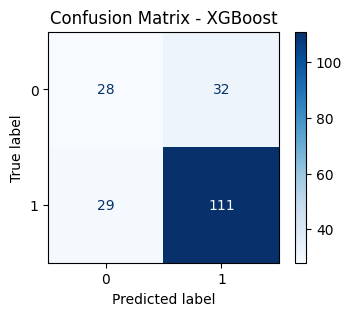


--- Riepilogo Performance Modelli Base ---
Tabella Riassuntiva Performance Base:


,Modello,CV F1 (bad),Test F1 (bad),Test Accuracy,CV Accuracy
0,Dummy Classifier,0.3042,0.2500,0.550,0.5825
1,Logistic Regression,0.4306,0.4630,0.710,0.7250
2,Decision Tree,0.4739,0.4959,0.695,0.6788
3,Random Forest,0.4722,0.4086,0.725,0.7525
4,SVM (RBF),0.4210,0.3913,0.720,0.7450
5,AdaBoost,0.4709,0.4182,0.680,0.7362
6,XGBoost,0.5425,0.4786,0.695,0.7488


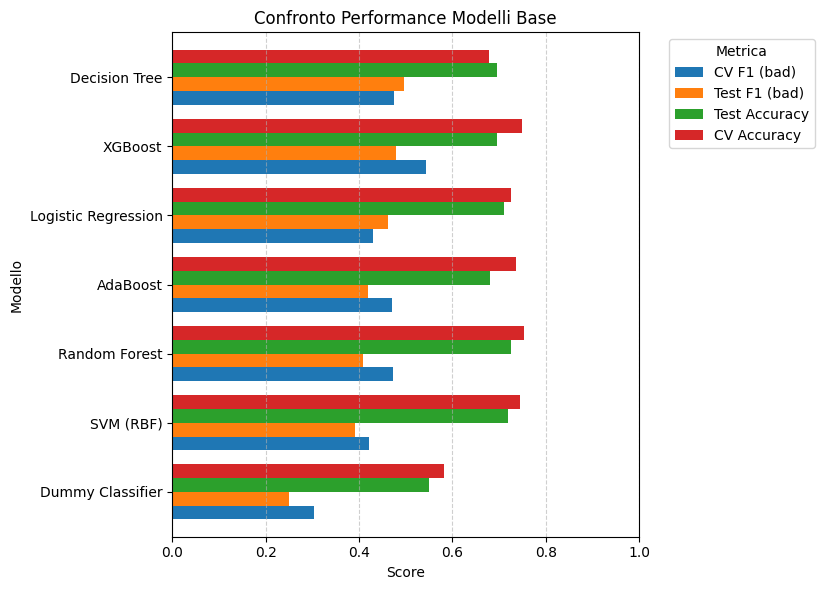


Miglior modello base (basato su Test F1 'bad'): Decision Tree (Score: 0.4959)
Miglior modello base (basato su Test Accuracy): Random Forest (Score: 0.7250)


In [ ]:
print(f"\n{'='*15} SEZIONE 5.1: VALUTAZIONE PRELIMINARE MODELLI {'='*15}")

def evaluate_models(model_pipeline, model_name, X_train, y_train, X_test, y_test, cv_strategy,class_names, pos_label='good',neg_label='bad'):
    """
    Valuta un modello usando Cross-Validation sul training set e poi sul test set.
    Restituisce un dizionario con le metriche medie della CV e le metriche del test set.
    """
    results = {}
    print(f"\n{'='*20} {model_name} {'='*20}")

    local_pos_label_index = list(label_encoder.classes_).index(pos_label)
    local_neg_label_index = list(label_encoder.classes_).index(neg_label)


    # --- Cross Validation sul Training Set ---
    cv_scoring_keys = ['accuracy', 'f1_pos', 'f1_neg', 'f1_weighted']
    scoring = {
        'accuracy': make_scorer(accuracy_score),
        'f1_pos': make_scorer(f1_score, pos_label=local_pos_label_index, zero_division=0),
        'f1_neg': make_scorer(f1_score, pos_label=local_neg_label_index, zero_division=0),
        'f1_weighted': make_scorer(f1_score, average='weighted', zero_division=0)
    }

    # Chiavi attese nei risultati CV
    cv_result_keys_mean = [f'cv_{k}_mean' for k in cv_scoring_keys]
    cv_result_keys_std = [f'cv_{k}_std' for k in cv_scoring_keys]

    try:
        # Esegue la cross_validate
        cv_results = cross_validate(model_pipeline, X_train, y_train,
                                    cv=cv_strategy, scoring=scoring, n_jobs=-1)

        print(f"Cross-Validation ({cv_strategy.get_n_splits()}-fold) Results:")
        # Calcola media e deviazione standard per ogni metrica CV
        for metric in scoring.keys():
            key_mean = f'cv_{metric}_mean'
            key_std = f'cv_{metric}_std'
            test_scores = cv_results[f'test_{metric}']
            results[key_mean] = np.mean(test_scores)
            results[key_std] = np.std(test_scores)

            # Stampa risultati CV
            label = metric.replace('f1_pos', f'F1({pos_label})').replace('f1_neg', f'F1({neg_label})').replace('f1_weighted','F1(w)').capitalize()
            print(f"  {label:<15}: {results[key_mean]:.4f} (±{results[key_std]:.4f})")

    except Exception as e:
        print(f"Errore durante la Cross-Validation per {model_name}: {e}")
        # Inizializza a NaN se CV fallisce
        for key in cv_result_keys_mean + cv_result_keys_std:
             results[key] = np.nan


    # --- Valutazione sul Test Set ---
    # Chiavi attese nei risultati Test
    test_result_keys = ['test_accuracy', 'test_f1_pos', 'test_f1_neg', 'test_f1_weighted']

    try:
        # Addestra il modello sull'intero training set
        model_pipeline.fit(X_train, y_train) # Usa y_train (codificato)
        y_pred = model_pipeline.predict(X_test) # Predice etichette codificate (0/1)

        report_dict = classification_report(y_test, y_pred, target_names=class_names, output_dict=True, zero_division=0)

        # Estrai metriche dal dizionario del report
        results['test_accuracy'] = report_dict['accuracy']
        results['test_f1_pos'] = report_dict[pos_label]['f1-score']
        results['test_f1_neg'] = report_dict[neg_label]['f1-score']
        results['test_f1_weighted'] = report_dict['weighted avg']['f1-score']
        # Estrai precision/recall se servono per la stampa
        test_precision_neg = report_dict[neg_label]['precision']
        test_recall_neg = report_dict[neg_label]['recall']

        print("\nTest Set Results:")
        print(f"  Accuracy:        {results['test_accuracy']:.4f}")
        print(f"  F1 Score ({pos_label}):  {results['test_f1_pos']:.4f}")
        print(f"  F1 Score ({neg_label}):  {results['test_f1_neg']:.4f}")
        print(f"  F1 Score (w):    {results['test_f1_weighted']:.4f}")
        print(f"  --- Metriche per classe '{neg_label}' ---")
        print(f"  Precision ({neg_label}): {test_precision_neg:.4f}")
        print(f"  Recall ({neg_label}):    {test_recall_neg:.4f}")


        # Visualizzazione matrice di confusione
        cm = confusion_matrix(y_test, y_pred, labels=model_pipeline.classes_) # Usa l'ordine delle classi originali'
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model_pipeline.classes_) # Mostra nomi originali
        fig, ax = plt.subplots(figsize=(4, 3))
        disp.plot(ax=ax, cmap='Blues', xticks_rotation='horizontal')
        plt.title(f'Confusion Matrix - {model_name}')
        plt.grid(False)
        plt.show()

        # Stampa classification report completo
        # print("\nClassification Report (Test Set):")
        # print(classification_report(y_test, y_pred, target_names=class_names, zero_division=0))


    except Exception as e:
      print(f"Errore durante la valutazione sul Test Set per {model_name}: {e}")
      for key in test_result_keys:
             results[key] = np.nan


    return results



from csv import unregister_dialect
# --- Definizione Modelli Base ---
RANDOM_SEED = 42
# Usiamo i dati processati (X_train_processed_df, y_train_encoded, etc.)
# MA la valutazione la facciamo con le etichette originali ('good'/'bad') per chiarezza
# La pipeline interna si occuperà della codifica se necessario

# Strategia di Cross-Validation
cv_strategy = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Dizionario dei modelli base (pipeline semplici)
# NOTA: I modelli ora ricevono i dati GIA' processati, quindi non includiamo il preprocessor qui.
#       Tuttavia, per coerenza con evaluate_models che si aspetta una pipeline,
#       incapsuliamo ogni classificatore in una sua mini-pipeline.
models_dict_base = {
    'Dummy Classifier': Pipeline([('classifier', DummyClassifier(strategy='stratified', random_state=RANDOM_SEED))]),
    'Logistic Regression': Pipeline([('classifier', LogisticRegression(random_state=RANDOM_SEED, solver='liblinear', max_iter=1000))]), # Aumentato max_iter
    'Decision Tree': Pipeline([('classifier', DecisionTreeClassifier(random_state=RANDOM_SEED))]),
    'Random Forest': Pipeline([('classifier', RandomForestClassifier(random_state=RANDOM_SEED, n_estimators=100))]),
    'SVM (RBF)': Pipeline([('classifier', SVC(kernel='rbf', random_state=RANDOM_SEED, probability=True))]), # probability=True per ROC AUC se servirà
    'AdaBoost': Pipeline([('classifier', AdaBoostClassifier(random_state=RANDOM_SEED))]),
    'XGBoost': Pipeline([('classifier', xgb.XGBClassifier(random_state=RANDOM_SEED, eval_metric='logloss', use_label_encoder=False))]) # use_label_encoder=False è raccomandato
}

# --- Esecuzione Valutazione Base ---
all_base_results = {}
for model_name, model_pipeline in models_dict_base.items():
    # Passiamo i dati GIA' processati e le etichette CODIFICATE
    model_results = evaluate_models(model_pipeline,
                                     model_name,
                                     X_train_processed_df,
                                     label_encoder.transform(y_train), # Usa le etichette codificate
                                     X_test_processed_df,
                                     label_encoder.transform(y_test),  # Usa le etichette codificate
                                     cv_strategy=cv_strategy,
                                     class_names=class_names,
                                     pos_label='good',
                                     neg_label='bad')

    all_base_results[model_name] = model_results


# --- Confronto Risultati Base ---
print("\n--- Riepilogo Performance Modelli Base ---")
results_summary_list = []
for name, res in all_base_results.items():
    results_summary_list.append({
        'Modello': name,
        'CV F1 (bad)': res.get('cv_f1_neg_mean', np.nan), # Usa cv_f1_neg_mean
        'Test F1 (bad)': res.get('test_f1_neg', np.nan),  # Usa test_f1_neg
        'Test Accuracy': res.get('test_accuracy', np.nan),
        'CV Accuracy': res.get('cv_accuracy_mean', np.nan) # Usa cv_accuracy_mean
    })

summary_df = pd.DataFrame(results_summary_list)
print("Tabella Riassuntiva Performance Base:")
display(summary_df.round(4))

summary_df_for_plot = summary_df.set_index('Modello')


# --- Creazione Grafico a Barre Raggruppate ---

# Prepara il DataFrame per il plot: imposta 'Modello' come indice
summary_df_for_plot = summary_df.set_index('Modello')

# Ordina i modelli per una metrica specifica, es. Test F1 (bad), per una visualizzazione migliore
summary_df_for_plot = summary_df_for_plot.sort_values(by='Test F1 (bad)', ascending=True) # Ascending così le barre migliori sono più in alto

# Crea il grafico
ax = summary_df_for_plot.plot(kind='barh', figsize=(10, 6), width=0.8) # barh per orizzontale

# Personalizza il grafico
plt.title('Confronto Performance Modelli Base')
plt.xlabel('Score')
plt.ylabel('Modello')
plt.xlim(0, 1.0) # Imposta limite asse x da 0 a poco più di 1
plt.legend(title='Metrica', bbox_to_anchor=(1.05, 1), loc='upper left') # Legenda fuori dal plot
plt.grid(axis='x', linestyle='--', alpha=0.6) # Griglia verticale leggera

# Aggiungi valori sulle barre (opzionale, può affollare)
# for container in ax.containers:
#    ax.bar_label(container, fmt='%.3f', label_type='edge', padding=2, fontsize=8)

plt.tight_layout(rect=[0, 0, 0.85, 1]) # Aggiusta layout per far spazio alla legenda
plt.show()


# Trova il modello base migliore (es. basato su Test F1 'bad')
# Nota: l'ordinamento del DataFrame aiuta già a identificarlo visivamente
best_f1_bad_model_idx = summary_df['Test F1 (bad)'].idxmax()
# Usa l'indice numerico restituito da idxmax per accedere alla riga corretta
best_f1_bad_score = summary_df.loc[best_f1_bad_model_idx, 'Test F1 (bad)']
best_f1_bad_model_label = summary_df.loc[best_f1_bad_model_idx, 'Modello'] # Prendi il nome modello
print(f"\nMiglior modello base (basato su Test F1 'bad'): {best_f1_bad_model_label} (Score: {best_f1_bad_score:.4f})")

best_accuracy_model_idx = summary_df['Test Accuracy'].idxmax()
best_accuracy_score = summary_df.loc[best_accuracy_model_idx, 'Test Accuracy']
best_accuracy_model_label = summary_df.loc[best_accuracy_model_idx, 'Modello']
print(f"Miglior modello base (basato su Test Accuracy): {best_accuracy_model_label} (Score: {best_accuracy_score:.4f})")

**Osservazioni**:

*   I modelli *XGBoost* e *Random Forest* sembrano essere i candidati più promettenti dalla valutazione base, a seconda che si prioritizzi l'F1-score su `bad` o l'accuratezza generale.
*   Il *Decision Tree* offre performance ragionevoli e potrebbe essere una valida alternativa
*   *SVM* e *AdaBoost* sembrano essere i modelli meno performanti in questo scenario iniziale, in particolare sulla classe `bad`.

## 4.2 Fine-tuning del Decision Tree Classifier

Il Decision Tree è un modello interpretabile e semplice, ma incline all'overfitting. Per evitare ciò, si usiamo delle teniche di **regolarizzazione**.

In questa sezione, esploreremo due strategie principali per ottimizzare un decision tree, in modo da ottenere la configurazione che massimizza le performance . (in particolare l'F1-score sulla classe `bad`):

1. **Pre-Pruning**: limita la screscita dell'albero durante la sua costruzione agendo sugli iperparametri. Cercheremo la conbinazione ottimale di questi parametri tramite Grid Search.
2. **Minimal Cost-Complexity Pruning (CCP)**: fa crescere un albero potenzialmente complesso e poi fa il pruning dei rami meno importanti basandosi sul parametro `ccp_alpha`. Troveremo l'alpha ottimale sempre tramite Grid Search.

Per entrambi gli approcci, testeremo diverse strategie per gestire lo sbilanciamento delle classi: nessuna azione, varie tecniche di *resempling* (SMOTE, ADASYN, RandomOver/UnderSampler, ecc.) che verranno applicate all'interno della cross-validation tramite `imblearn.pipeline`, e l'uso del parametro `class_weight='balanced'`.

Selezioneremo infine la combinazione di approccio di pruning, resempling e configurazione di iperparametri che fornisce il migliore F1-score (bad) durante la cross-validation, per poi valutarla definitivamente sul test set.

Sono state definite alcune funzioni utilizzate nel training dei modelli e nella valutazione:


*   `plot_confusion_matrix`: permette di visualizzare graficamente le performance di un modello di classificazione tramite una matrice di confusione.

*   `evaluate_model`: permette di valutare in modo completo un modello addestrato sul set di test.

*   `get_feature_importances`: permette di estrarre le feature importances da un modello addestrato.

*   `visualize_feature_importances`: genera una visualizzazione grafica delle feature importances.

*   `visualize_best_tree`: permette di visualizzare la struttura di un albero decisionale addestrato.

*  `run_grid_search_cv`: esegue una *Grid Search* per trovare i migliori iperparametri per un dato modello, gestendo opzionalmente il ricampionamento (resampling) dei dati in modo corretto all'interno della cross-validation.

In [ ]:
### sezione per inserire una sola volta tutte le costanti per i training dei modelli coome random, numero di split, valutazione f1 scelta ecc in modo da commentarle



=============== SEZIONE 4.2: OTTIMIZZAZIONE DECISION TREE ===============

==================== PASSO 1: Decision Tree - Pre-Pruning ====================
Min neighbors per SMOTE: 1
Min neighbors per ADASYN: 1

==================== GridSearch DT Pre-Pruning: Baseline (No Balancing) ====================

==================== GridSearch DT Pre-Pruning: RandomOver ====================
Fitting 5 folds for each of 2160 candidates, totalling 10800 fits
Migliori iperparametri (con sampler RandomOverSampler): {'classifier__criterion': 'gini', 'classifier__max_depth': 3, 'classifier__max_features': 0.6, 'classifier__min_samples_leaf': 20, 'classifier__min_samples_split': 5}
Miglior score (custom) (CV): 0.5896 su CV: 0.5896

==================== GridSearch DT Pre-Pruning: SMOTE ====================
Fitting 5 folds for each of 2160 candidates, totalling 10800 fits
Migliori iperparametri (con sampler SMOTE): {'classifier__criterion': 'gini', 'classifier__max_depth': 5, 'classifier__max_features': 

,Metodo,best_f1_bad_cv
1,PrePruning_SMOTE,0.5961
4,PrePruning_SMOTETomek,0.5936
2,PrePruning_ADASYN,0.5910
5,PrePruning_ClassWeight,0.5898
0,PrePruning_RandomOver,0.5896
3,PrePruning_RandomUnder,0.5795
7,CCP_Alpha,0.5667
6,PrePruning_NoBalance,0.5463



---> Miglior Metodo Complessivo per Decision Tree (basato su CV F1 'bad'): PrePruning_SMOTE
---> Miglior F1-score 'bad' (CV): 0.5961
Parametri Ottimali (all'interno della pipeline):
  classifier__criterion: gini
  classifier__max_depth: 5
  classifier__max_features: None
  classifier__min_samples_leaf: 3
  classifier__min_samples_split: 5

--- Valutazione Finale del Modello Migliore (PrePruning_SMOTE) sul Test Set ---


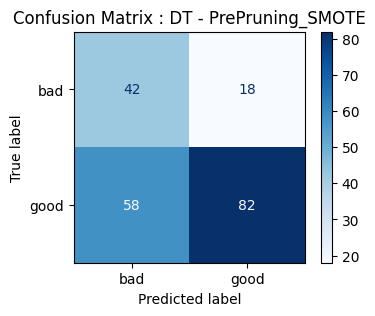


--- Classification Report for DT - PrePruning_SMOTE on Test Set ---
              precision    recall  f1-score   support

         bad       0.42      0.70      0.53        60
        good       0.82      0.59      0.68       140

    accuracy                           0.62       200
   macro avg       0.62      0.64      0.60       200
weighted avg       0.70      0.62      0.64       200


--- Key Metrics for DT - PrePruning_SMOTE on Test Set ---
  Accuracy: 0.6200
  F1-score (weighted): 0.6358
  F1-score (bad): 0.5250
  Precision (bad): 0.4200
  Recall (bad): 0.7000
---------------------------------------------------

F1 Score 'bad' finale sul Test Set: 0.5250

Estratto classificatore DT dalla pipeline finale.
Estratto classificatore dalla pipeline.


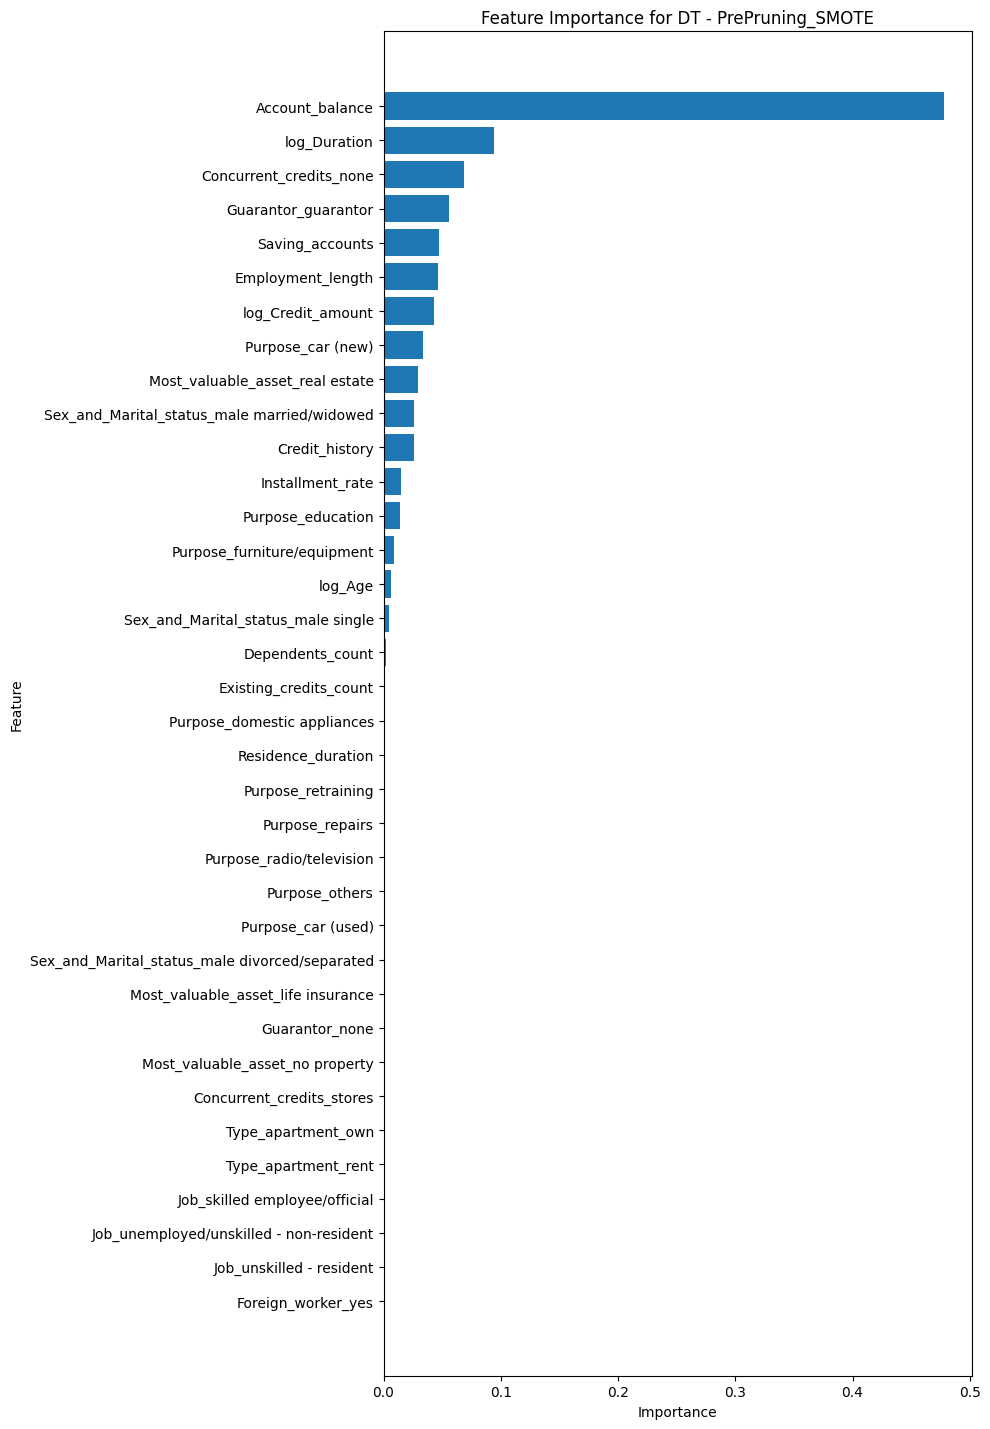


Visualizzazione albero decisionale (Profondità attuale: 5).


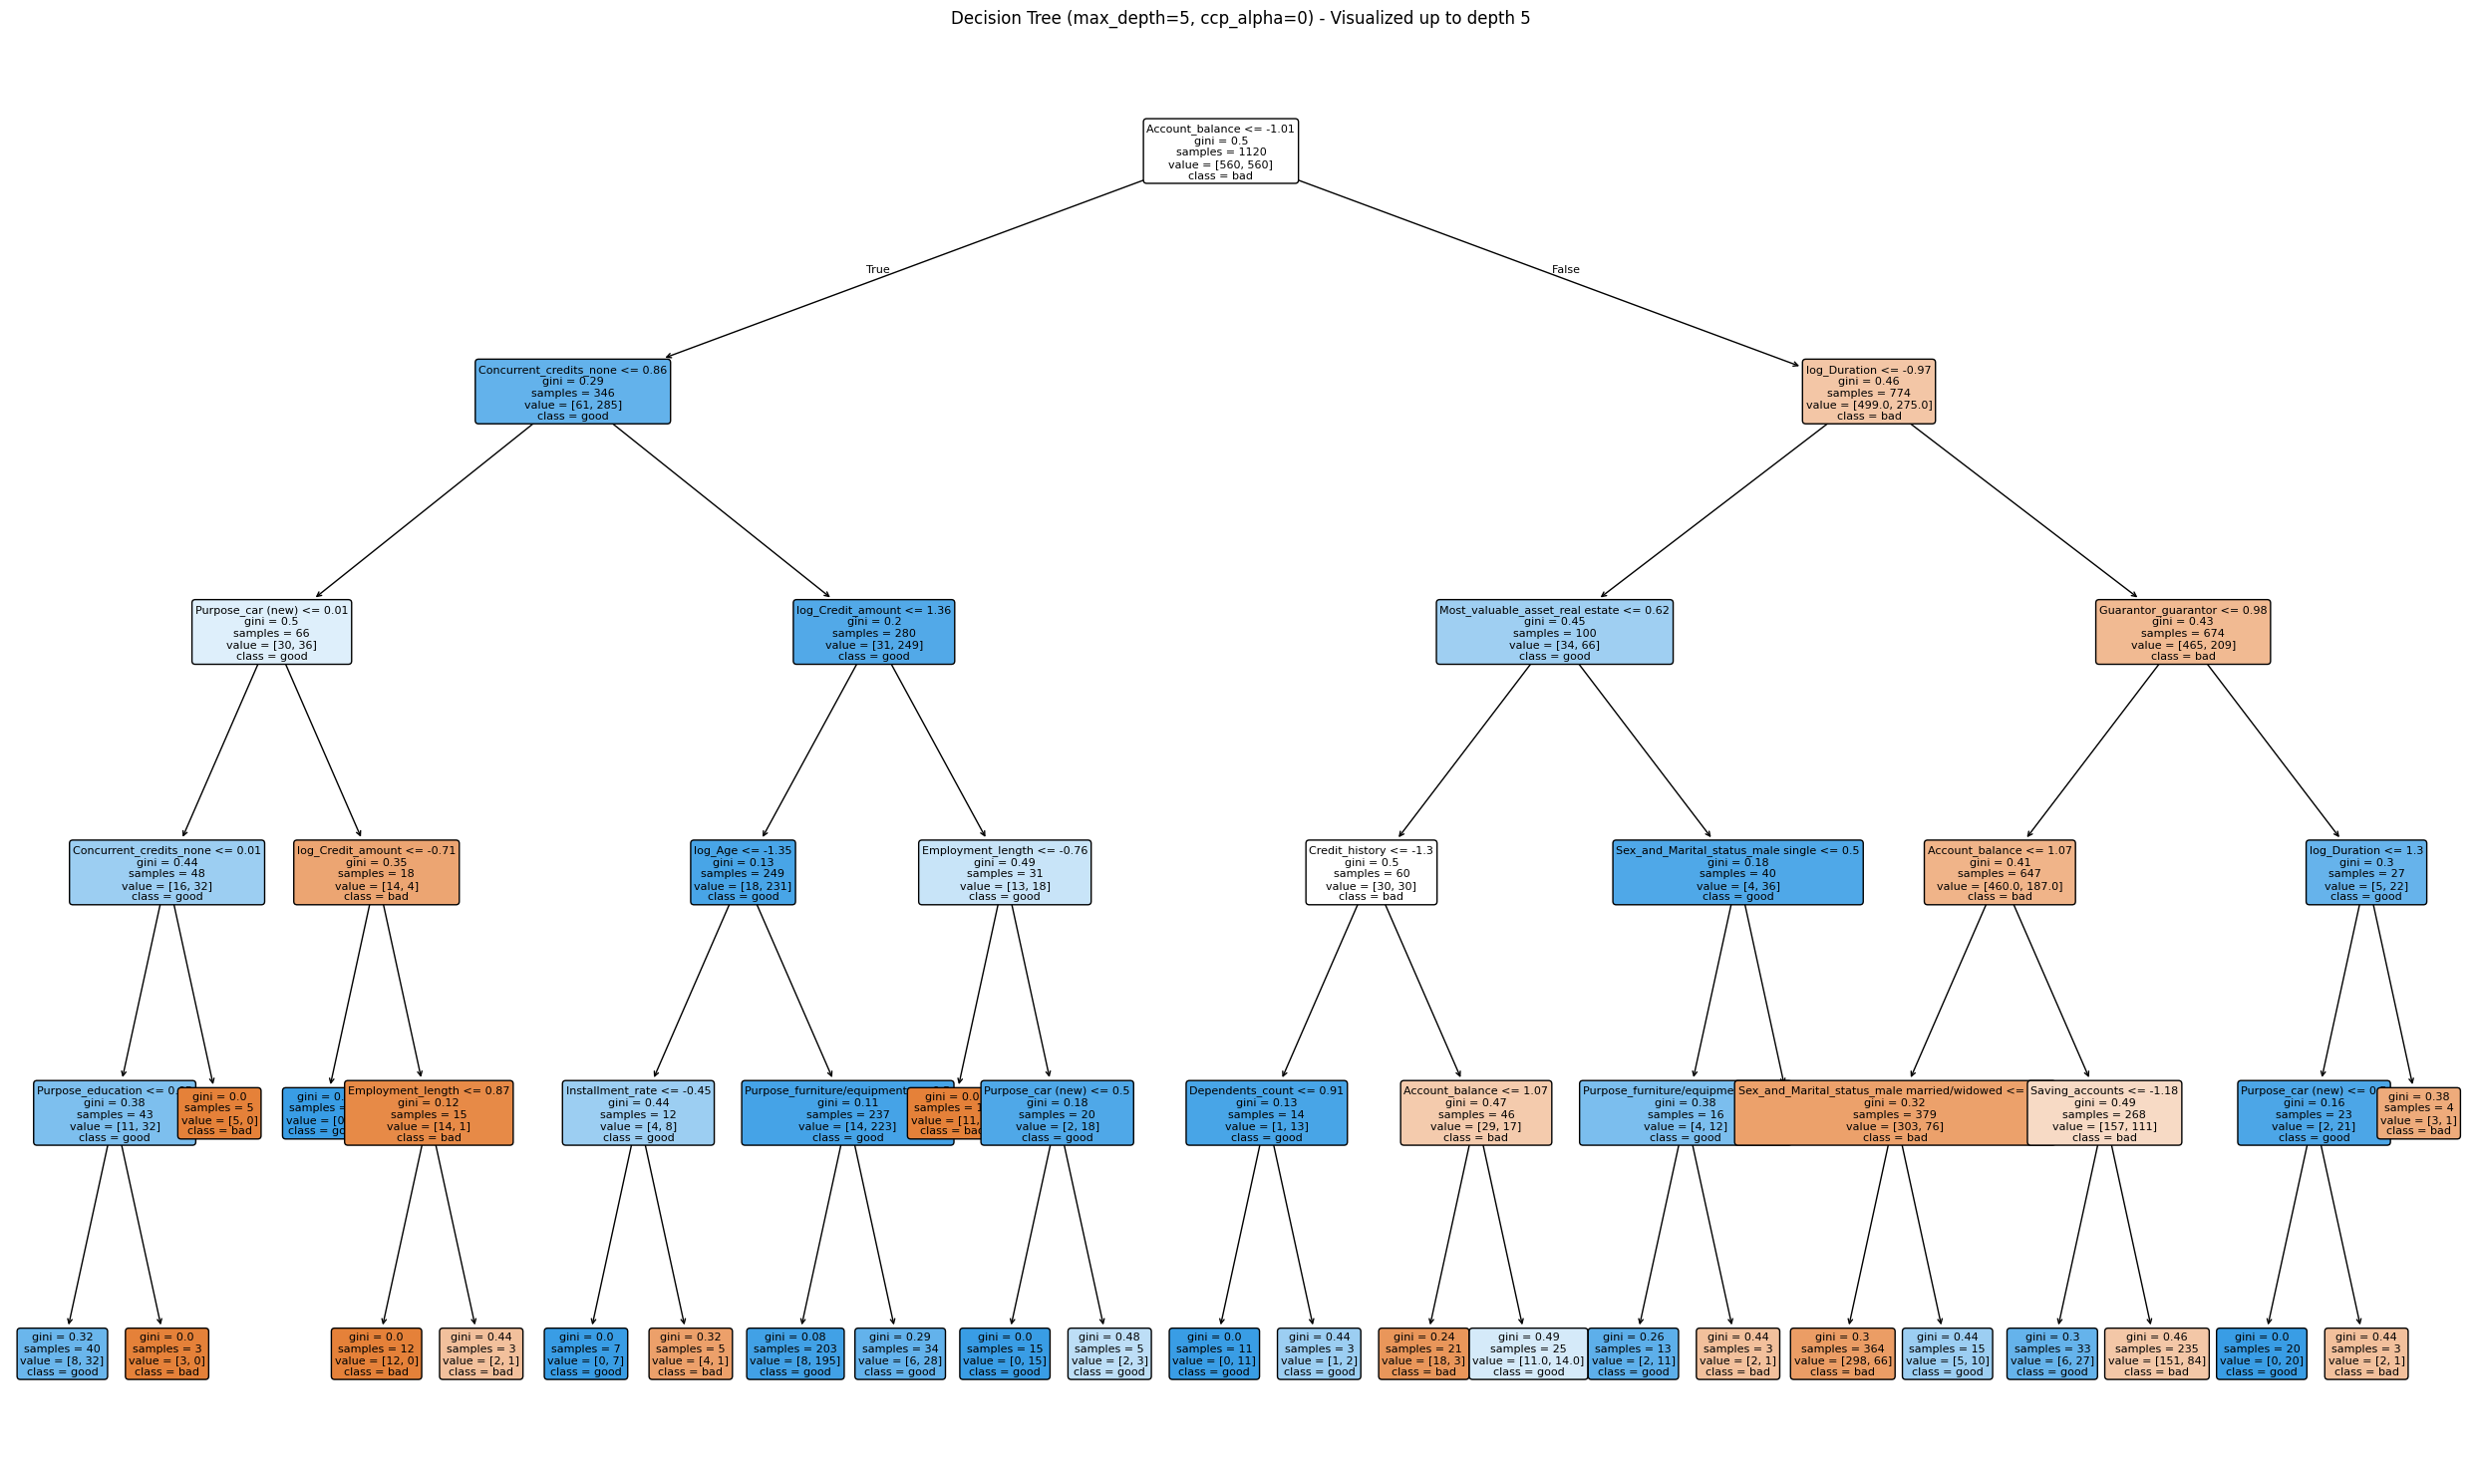


Regole testuali dell'albero:
|--- Account_balance <= -1.01
|   |--- Concurrent_credits_none <= 0.86
|   |   |--- Purpose_car (new) <= 0.01
|   |   |   |--- Concurrent_credits_none <= 0.01
|   |   |   |   |--- Purpose_education <= 0.05
|   |   |   |   |   |--- class: 1
|   |   |   |   |--- Purpose_education >  0.05
|   |   |   |   |   |--- class: 0
|   |   |   |--- Concurrent_credits_none >  0.01
|   |   |   |   |--- class: 0
|   |   |--- Purpose_car (new) >  0.01
|   |   |   |--- log_Credit_amount <= -0.71
|   |   |   |   |--- class: 1
|   |   |   |--- log_Credit_amount >  -0.71
|   |   |   |   |--- Employment_length <= 0.87
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- Employment_length >  0.87
|   |   |   |   |   |--- class: 0
|   |--- Concurrent_credits_none >  0.86
|   |   |--- log_Credit_amount <= 1.36
|   |   |   |--- log_Age <= -1.35
|   |   |   |   |--- Installment_rate <= -0.45
|   |   |   |   |   |--- class: 1
|   |   |   |   |--- Installment_rate >  -0.45
|   |   |

In [ ]:
print(f"\n{'='*15} SEZIONE 4.2: OTTIMIZZAZIONE DECISION TREE {'='*15}")
RANDOM_SEED = 42
N_SPLIT_CV = 5
cv = StratifiedKFold(n_splits=N_SPLIT_CV, shuffle=True, random_state=RANDOM_SEED)

f1_bad_scorer = make_scorer(f1_score, pos_label=bad_label_index, average='binary', zero_division=0)

# Chiave per salvare lo score CV nel dizionario dei risultati
best_cv_score_key = 'best_f1_bad_cv' # F1 'bad' medio su cv

def plot_confusion_matrix(y_true, y_pred, title, class_names):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=class_names)
    fig, ax = plt.subplots(figsize=(4, 3))
    disp.plot(ax=ax, cmap='Blues')
    plt.title(title)
    plt.grid(False)
    plt.show()

def evaluate_model(model,X_test,y_test, model_name, class_names, bad_label_index):
    """ Valuta le performance del modello e ne visualizza i risultati"""

    y_pred = model.predict(X_test)

    # Visualizza la matrice di confusione
    title = f'Confusion Matrix : {model_name}'
    plot_confusion_matrix(y_test, y_pred,title, class_names)

    # Stampa il classification report completo
    print(f"\n--- Classification Report for {model_name} on Test Set ---")
    print(classification_report(y_test, y_pred, target_names=class_names))

  # Calcola e stampa metriche chiave separatamente per chiarezza
    accuracy = accuracy_score(y_test, y_pred)
    f1_bad = f1_score(y_test, y_pred, pos_label=bad_label_index)
    precision_bad = precision_score(y_test, y_pred, pos_label=bad_label_index, zero_division=0)
    recall_bad = recall_score(y_test, y_pred, pos_label=bad_label_index, zero_division=0)
    f1_weighted_test = f1_score(y_test, y_pred, average='weighted')

    print(f"\n--- Key Metrics for {model_name} on Test Set ---")
    print(f"  Accuracy: {accuracy:.4f}")
    print(f"  F1-score (weighted): {f1_weighted_test:.4f}")
    print(f"  F1-score (bad): {f1_bad:.4f}")
    print(f"  Precision (bad): {precision_bad:.4f}")
    print(f"  Recall (bad): {recall_bad:.4f}")
    print("-"*(30 + len(model_name)))

    return f1_bad

def get_feature_importances(model, feature_names):
    """ Ottiene le feature importances da un modello o da una pipeline (step 'classifier'). """

    classifier = None

    # Prova ad estrarre il classificatore se è una pipeline
    if hasattr(model, 'named_steps') and 'classifier' in model.named_steps:
        classifier = model.named_steps['classifier']
        print("Estratto classificatore dalla pipeline.") # Debug
    else:
        # Altrimenti, assumi che 'model' sia già il classificatore
        classifier = model
        print("Input 'model' trattato come classificatore diretto.") # Debug


    # Controlla se abbiamo un classificatore valido con feature_importances_
    if not hasattr(classifier, 'feature_importances_'):
        print(f"ERRORE: L'oggetto classificatore ({type(classifier).__name__}) non ha l'attributo 'feature_importances_'.")
        return None # Gestiamo il caso in cui il modello non ha feature_importances_

    # --- CORREZIONE QUI ---
    # Accedi a feature_importances_ sull'oggetto 'classifier' estratto, non su 'model'
    try:
        importances = classifier.feature_importances_
    except AttributeError:
         # Fallback nel caso improbabile che hasattr passi ma l'accesso fallisca
        print(f"ERRORE: Impossibile accedere a 'feature_importances_' su {type(classifier).__name__}.")
        return None


    # Creiamo un DataFrame
    # Assicurati che feature_names abbia la lunghezza corretta
    if len(feature_names) != len(importances):
        print(f"ATTENZIONE: Numero di feature names ({len(feature_names)}) non corrisponde al numero di importances ({len(importances)}).")
        # Potresti troncare o gestire l'errore in modo diverso
        min_len = min(len(feature_names), len(importances))
        feature_names = feature_names[:min_len]
        importances = importances[:min_len]


    feature_importance_df = pd.DataFrame({
        'Feature': list(feature_names), # Assicurati che feature_names sia una lista o simile
        'Importance': importances
    })

    return feature_importance_df.sort_values(by='Importance', ascending=False)

def visualize_feature_importances(feature_importance_df, model_name):

  if feature_importance_df is None or feature_importance_df.empty:
    print(f"Nessuna feature importante è disponibile per il modello {model_name}.")
    return

  plt.figure(figsize=(10, max(6, len(feature_importance_df) * 0.4))) # Altezza dinamica
  plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'])
  plt.xlabel("Importance")
  plt.ylabel("Feature")
  plt.title(f"Feature Importance for {model_name}")
  plt.gca().invert_yaxis() # Mostra la più importante in alto
  plt.tight_layout()
  plt.show()

def visualize_best_tree(model, feature_names, class_names):
  if hasattr(model, 'named_steps') and 'classifier' in model.named_steps:
      tree = model.named_steps['classifier']
  else:
      tree = model # Se non è una pipeline

  if not isinstance(tree, DecisionTreeClassifier):
      print(f"Il classificatore ({type(tree).__name__}) non è un Decision Tree, impossibile visualizzare.")
      return

  # Limita la profondità massima per maggiore leggibilità
  max_depth_plot = 5
  current_depth = tree.get_depth()
  print(f"\nVisualizzazione albero decisionale (Profondità attuale: {current_depth}).")
  if current_depth > max_depth_plot:
      print(f"L'albero è profondo, visualizzo solo fino a profondità {max_depth_plot} per leggibilità.")

  plt.figure(figsize=(25, 15))
  plot_tree(tree,
            feature_names=feature_names,
            class_names=class_names,
            filled=True,
            rounded=True,
            fontsize=8, # Riduci fontsize se l'albero è complesso
            max_depth=max_depth_plot, # Limita profondità visualizzata
            precision=2) # Numero di decimali

  plt.title(f"Decision Tree (max_depth={tree.max_depth}, ccp_alpha={tree.ccp_alpha:.4g}) - Visualized up to depth {max_depth_plot}")
  plt.tight_layout()
  plt.show()


  # Stampo le regole testuali utili nel caso di albero profondo
  print("\nRegole testuali dell'albero:")
  tree_rules = export_text(tree, feature_names=list(feature_names))
  print(tree_rules)

def run_grid_search_cv(model, sampler, param_grid, X_train, y_train, cv, scoring_metric, cv_score_key):
  """Esegue la grid search con cross-validation, ritorna il modello migliore e score CV"""


  # Costruiamo la pipeline con o senza resampling
  pipeline_steps = []
  sampler_name = "None"
  if sampler is not None:
      # Usiamo ImbPipeline se c'è un sampler
      pipeline_steps.append(('sampling', sampler))
      pipeline_steps.append(('classifier', model))
      sampler_name = sampler.__class__.__name__
      pipeline = ImbPipeline(pipeline_steps)
  else:
      # Usiamo Pipeline standard se non c'è sampler (per class_weight o CCP)
      pipeline_steps.append(('classifier', model))
      pipeline = Pipeline(pipeline_steps)

  # Configura e avvia GridSearchCV
  grid_search = GridSearchCV(
      estimator=pipeline,
      param_grid=param_grid,
      scoring=scoring_metric, # <-- Usa la metrica passata
      cv=cv,
      n_jobs=-1,
      verbose=1,
      error_score='raise'
  )

  grid_search.fit(X_train, y_train)

  print(f"Migliori iperparametri ({'con' if sampler else 'senza'} sampler {sampler_name}): {grid_search.best_params_}")
  print(f"Miglior score ({getattr(scoring_metric, '__name__', 'custom')}) (CV): {grid_search.best_score_:.4f} su CV: {grid_search.best_score_:.4f}")

  return {
      'best_params': grid_search.best_params_,
      cv_score_key: grid_search.best_score_, # <-- Usa la chiave passata
      'best_model_estimator': grid_search.best_estimator_ # L'intera pipeline ottimizzata
    }

# --- PASSO 1: Approccio Pre-Prunning ---
print(f"\n{'='*20} PASSO 1: Decision Tree - Pre-Pruning {'='*20}")

dt_param_grid_prepruning = {
    'classifier__max_depth': [3,4,5, 6, 7, 8, 10, 15, None],
    'classifier__min_samples_split': [5, 10, 15, 20],
    'classifier__min_samples_leaf': [3, 5, 10, 15, 20],
    'classifier__max_features': [0.6,0.8,0.9,'sqrt', 'log2', None],
    'classifier__criterion': ['gini', 'entropy']
}


# Definiamo i sampler (assicurandoci che k_neighbors sia valido)
# Calcoliamo min_neighbors dniamicamente basandosi sulla classe minoritaria nel training set
count_minority = np.sum(y_train == bad_label_index)
min_neighbors_smote = max(1, min(5, count_minority - 1)) # Usa min(5, count-1), min 1
min_neighbors_adasyn = max(1, min(7, count_minority - 1)) # Usa min(7, count-1), min 1


print(f"Min neighbors per SMOTE: {min_neighbors_smote}")
print(f"Min neighbors per ADASYN: {min_neighbors_adasyn}")

samplers = {
    'RandomOver': RandomOverSampler(random_state=RANDOM_SEED),
    'SMOTE': SMOTE(random_state=RANDOM_SEED, k_neighbors=min_neighbors_smote),
    'ADASYN': ADASYN(random_state=RANDOM_SEED, n_neighbors=min_neighbors_adasyn),
    'RandomUnder': RandomUnderSampler(random_state=RANDOM_SEED),
    'SMOTETomek': SMOTETomek(random_state=RANDOM_SEED, smote=SMOTE(random_state=RANDOM_SEED, k_neighbors=min_neighbors_smote)),
}

decision_tree_results = {}

print(f"\n{'='*20} GridSearch DT Pre-Pruning: Baseline (No Balancing) {'='*20}")

for name, sampler in samplers.items():
  print(f"\n{'='*20} GridSearch DT Pre-Pruning: {name} {'='*20}")
  # Creiamo un classificatore DT per ogni ricerca
  decision_tree_classifier = DecisionTreeClassifier(random_state=RANDOM_SEED, ccp_alpha=0.0)

  decision_tree_results[f"PrePruning_{name}"] = run_grid_search_cv(
        model=decision_tree_classifier,
        sampler=sampler,
        param_grid=dt_param_grid_prepruning,
        X_train=X_train_processed_df,
        y_train=y_train_encoded,
        cv=cv,
        scoring_metric=f1_bad_scorer,
        cv_score_key=best_cv_score_key
        )


# --- Esegui GridSearch per Pre-Pruning CON CLASS_WEIGHT (senza sampler esterno) ---
print(f"\n{'='*20} GridSearch DT Pre-Pruning: ClassWeight {'='*20}")
decision_tree_param_grid_cw = dt_param_grid_prepruning.copy()
# Aggiungi class_weight alla griglia specifica
decision_tree_param_grid_cw['classifier__class_weight'] = ['balanced']
decision_tree_classifier_cw = DecisionTreeClassifier(random_state=RANDOM_SEED)
# Qui usiamo sampler=None nella chiamata a run_grid_search_cv
decision_tree_results['PrePruning_ClassWeight'] = run_grid_search_cv(
    model=decision_tree_classifier_cw,
    sampler=None,
    param_grid=decision_tree_param_grid_cw, # Usa la griglia con class_weight
    X_train=X_train_processed_df,
    y_train=y_train_encoded,
    cv=cv,
    scoring_metric=f1_bad_scorer,
    cv_score_key=best_cv_score_key
    )

# --- Esegui GridSearch per Pre-Pruning SENZA Bilanciamento (Baseline) ---
print(f"\n{'='*20} GridSearch DT Pre-Pruning: Baseline (No Balancing) {'='*20}")
dt_classifier_nobalance = DecisionTreeClassifier(random_state=RANDOM_SEED)
decision_tree_results['PrePruning_NoBalance'] = run_grid_search_cv(
    model=dt_classifier_nobalance,
    sampler=None,
    param_grid=dt_param_grid_prepruning,
    X_train=X_train_processed_df,
    y_train=y_train_encoded,
    cv=cv,
    scoring_metric=f1_bad_scorer,
    cv_score_key=best_cv_score_key
)

# --- Passo 2: Post-Pruning Minimal Cost-Complexity Pruning (CCP) ---

print(f"\n{'='*20} PASSO 2: Decision Tree - CCP Alpha Pruning {'='*20}")

# 1. Calcola gli alpha candidati
print("Calcolo percorso CCP alpha...")
# Addestra un albero iniziale potenzialmente complesso (puoi usare i migliori parametri
# di pre-pruning senza bilanciamento o class_weight='balanced' come punto di partenza,
# oppure un albero non potato)
# Usiamo class_weight='balanced' per dare una possibilità anche ai rami delle classi minoritarie
initial_clf_ccp = DecisionTreeClassifier(random_state=RANDOM_SEED, class_weight='balanced')
# Fitta sull'intero training set (processato) per ottenere il percorso completo
path = initial_clf_ccp.cost_complexity_pruning_path(X_train_processed, y_train_encoded)
ccp_alphas = path.ccp_alphas

# Filtra alpha: rimuovi l'ultimo (albero banale), negativi, duplicati
ccp_alphas = np.unique(ccp_alphas[ccp_alphas >= 0])
if len(ccp_alphas) > 1:
    # Considera di rimuovere l'ultimo alpha solo se molto grande rispetto agli altri
    # if ccp_alphas[-1] > 0.1: # Esempio di soglia
    ccp_alphas = ccp_alphas[:-1]

# Riduci il numero di alpha se sono troppi per velocizzare GridSearch
# (es. seleziona logaritmicamente o un numero fisso)
if len(ccp_alphas) > 50: # Se ci sono più di 50 alpha
     print(f"Riduzione numero alpha da {len(ccp_alphas)} a ~50 per velocità...")
     indices = np.linspace(0, len(ccp_alphas) - 1, 50, dtype=int)
     ccp_alphas = ccp_alphas[indices]

if len(ccp_alphas) == 0:
     print("ATTENZIONE: Nessun alpha > 0 trovato. Aggiungo 0.0 come fallback.")
     ccp_alphas = np.array([0.0])

print(f"Numero di alpha candidati per CCP GridSearch: {len(ccp_alphas)}")

# 2. Definisci la griglia per CCP
#    Non includere i parametri di pre-pruning (max_depth, etc.)!
#    Testa anche con e senza class_weight='balanced'
param_grid_ccp = {
    'classifier__ccp_alpha': ccp_alphas,
    'classifier__criterion': ['gini', 'entropy'], # Testiamo entrambi i criteri
    'classifier__class_weight': [None, 'balanced'] # Testa entrambe le opzioni
}

# 3. Esegui GridSearch specifica per CCP (SENZA sampler esterno)
print("\n--- GridSearch DT CCP Alpha ---")
ccp_clf_base = DecisionTreeClassifier(random_state=RANDOM_SEED)
# Usa la funzione run_grid_search_cv
decision_tree_results['CCP_Alpha'] = run_grid_search_cv(
    model=ccp_clf_base,
    sampler=None, # CCP non si combina tipicamente con sampler esterni nella gridsearch
                  # perché class_weight viene testato internamente alla griglia.
    param_grid=param_grid_ccp,
    X_train=X_train_processed_df,
    y_train=y_train_encoded,
    cv=cv,
    scoring_metric=f1_bad_scorer,
    cv_score_key=best_cv_score_key
)


# --- Passo 3: Confronto Globale e Valutazione Finale DT ---

print(f"\n{'='*20} Confronto metodi e Valutazione Finale del Modello DT {'='*20}")

# Stampa riepilogo risultati CV per ogni metodo testato
print("\nRiepilogo Risultati Cross-Validation (F1 Score 'bad'):")
results_summary = []
for name, result in decision_tree_results.items():
    if result and best_cv_score_key in result:
        score = result[best_cv_score_key]
        results_summary.append({'Metodo': name, best_cv_score_key: score})
    else:
        results_summary.append({'Metodo': name, best_cv_score_key: np.nan})

summary_cv_df = pd.DataFrame(results_summary).sort_values(best_cv_score_key, ascending=False)
display(summary_cv_df.round(4).fillna('Errore'))


# Trova la miglior configurazione COMPLESSIVA basata sul CV F1 score per 'bad'
best_overall_method_name = summary_cv_df.iloc[0]['Metodo'] # Il primo dopo l'ordinamento

# Gestisci caso in cui nessun risultato sia valido
if pd.isna(summary_cv_df.iloc[0][best_cv_score_key]):
     print("\nERRORE: Nessun risultato valido trovato da nessuna GridSearch per Decision Tree.")
else:
    best_overall_result = decision_tree_results[best_overall_method_name]
    best_overall_cv_score = best_overall_result[best_cv_score_key]
    # Ottieni la pipeline completa (con sampler se presente) e i parametri OTTIMIZZATI
    best_dt_pipeline_final = best_overall_result['best_model_estimator']

    print(f"\n---> Miglior Metodo Complessivo per Decision Tree (basato su CV F1 'bad'): {best_overall_method_name}")
    print(f"---> Miglior F1-score 'bad' (CV): {best_overall_cv_score:.4f}")
    print("Parametri Ottimali (all'interno della pipeline):")
    # Stampa i parametri specifici del classificatore trovati
    best_params_final = best_overall_result['best_params']
    for param, value in best_params_final.items():
         print(f"  {param}: {value}")

    # Esegui la valutazione finale SUL TEST SET usando la pipeline migliore
    print(f"\n--- Valutazione Finale del Modello Migliore ({best_overall_method_name}) sul Test Set ---")

    final_f1_bad_test = evaluate_model(
        model=best_dt_pipeline_final,
        X_test=X_test_processed_df,
        y_test=y_test_encoded,
        model_name=f"DT - {best_overall_method_name}", # Nome descrittivo
        class_names=class_names,
        bad_label_index=bad_label_index
    )
    print(f"\nF1 Score 'bad' finale sul Test Set: {final_f1_bad_test:.4f}")

     # --- Visualizzazioni per il Modello Finale Migliore ---
    # Ottieni i nomi delle feature (assicurati siano corretti dopo il preprocessing)
    if X_train_processed_df is not None:
        feature_names = list(X_train_processed_df.columns)
    elif 'preprocessor' in locals() and hasattr(preprocessor, 'get_feature_names_out'):
         try:
             feature_names = preprocessor.get_feature_names_out()
         except:
             feature_names = [f'feature_{i}' for i in range(X_train_processed.shape[1])]
    else:
        feature_names = [f'feature_{i}' for i in range(X_train_processed.shape[1])]

     # Estrai il classificatore effettivo dalla pipeline finale
    if hasattr(best_dt_pipeline_final, 'named_steps') and 'classifier' in best_dt_pipeline_final.named_steps:
        best_classifier_dt_final = best_dt_pipeline_final.named_steps['classifier']
        print("\nEstratto classificatore DT dalla pipeline finale.")
    else:
         best_classifier_dt_final = best_dt_pipeline_final # Se non è una pipeline
         print("\nUtilizzo l'estimator diretto (non pipeline).")

    # Verifica se è effettivamente un Decision Tree
    if isinstance(best_classifier_dt_final, DecisionTreeClassifier):
        # Visualizza Feature Importances
        importances = get_feature_importances(best_dt_pipeline_final, feature_names) # Passa la pipeline
        visualize_feature_importances(importances, f"DT - {best_overall_method_name}")

        # Visualizza Albero Decisionale
        visualize_best_tree(best_dt_pipeline_final, feature_names, class_names) # Passa la pipeline
    else:
        print(f"\nIl miglior classificatore finale ({type(best_classifier_dt_final).__name__}) non è un Decision Tree.")
        print("Visualizzazione albero e feature importances specifiche dell'albero non possibili.")

## 5.3 Random Forest

Gli iperparametri esplorati per *Random Forest* sono i seguenti:

* `n_estimators`: numero di alberi nella foresta. Generalmente un numero maggiore di alberi migliora le performance e la stabilità (errori dei singoli alberi tendono a compensarsi). Tuttavia, i migliori diminuiscono dopo un certo numero di alberi, ma il tempo di calcolo aumenta linearmente. Per tanto, è necessario trovare un buon compromesso.

* `max_depth`: profondità massima consentita per ciascun albero. Controlla la complessità dei singoli alberi. Valori troppo alti possono portare a overfitting dei singoli alberi, anche se l'ensemble è più robusto.

* `min_samples_split`: valori più alti impediscono al modello di creare split basati su pochi campioni, rendendo gli alberi meno specifici per il training set e quindi riducendo l'overfitting. Valori più bassi permettono agli alberi di adattarsi più finemente ai dati.

* `min_samples_leaf`: specifica il numero minimo di campioni che devono trovarsi in un nodo foglia. Uno split viene considerato valido solo se lascia almeno `min_samples_leaf` campioni in ciascuno dei due rami risultanti (sinistro e destro).
Simile a `min_samples_split`, ma spesso considerato più efficace nel controllare l'overfitting.

* `max_features`: stabilisce la dimensione del sottoinsieme di features da considerare nella scelta del best split in un nodo. Introducendo la casualità nella selezione delle feature ad ogni split riusciamo a de-correlare gli alberi nella foresta, ovvero non sbagliano sugli stessi esempi, e in tal modo riduciamo anche la varianza complessiva dell'ensemble migliorando la capacità di generalizzazione

Abbiamo provato:

  *   **Valori float**: Rappresentano la frazione del numero totale di feature (es. 0.6 significa il 60% delle feature).
  *   `sqrt`: Considera sqrt(n_features) feature. È un valore comunemente usato e spesso il default per la classificazione.
  *   `log2`: Considera log2(n_features) feature.
  *   `None`: Considera tutte le feature ad ogni split (come un albero decisionale standard, meno comune in RF).

* `criterion`: matrica utilizzata per valutare la qualità di uno split. Abbiamo selezionato:

  *   `gini`: impurità di Gini. Misura la probabilità di classificare erroneamente un campione scelto a caso nel nodo.
  *   `entropy`: guadagno informativo (Information Gain), basato sull'entropia di Shannon.

* `bootstrap`: indica se applicare il campionamento bootstrap o meno ai dati per addestrare ciascun albero.

  *   `True`: metodo standard di Random Forest. Ogni albero viene addestrato su un campione diverso ottenuto campionando con reinserimento dal dataset originale. Questo lascia fuori alcuni campioni (Out-of-Bag) che possono essere usati per una stima interna dell'errore.
  *   `False`: l'intero dataset viene utilizzato per addestrare ciascun albero (la casualità deriva ancora da `max_features`).


=============== SEZIONE 4.3: OTTIMIZZAZIONE RANDOM FOREST ===============

============================== RANDOM FOREST ==============================

---- GridSearch RF con None ----
Fitting 5 folds for each of 32 candidates, totalling 160 fits
Migliori iperparametri (senza sampler None): {'classifier__criterion': 'gini', 'classifier__max_depth': None, 'classifier__max_features': 0.7, 'classifier__min_samples_leaf': 2, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 200}
Miglior score (custom) (CV): 0.5369 su CV: 0.5369

---- GridSearch RF con RandomOver ----
Fitting 5 folds for each of 32 candidates, totalling 160 fits
Migliori iperparametri (con sampler RandomOverSampler): {'classifier__criterion': 'gini', 'classifier__max_depth': 10, 'classifier__max_features': 0.7, 'classifier__min_samples_leaf': 2, 'classifier__min_samples_split': 15, 'classifier__n_estimators': 200}
Miglior score (custom) (CV): 0.5828 su CV: 0.5828

---- GridSearch RF con SMOTE ----
Fitting 5 f

,Metodo,best_f1_bad_cv
4,RF_RandomUnder,0.6120
3,RF_ADASYN,0.6058
6,RF_ClassWeight,0.6018
2,RF_SMOTE,0.5844
1,RF_RandomOver,0.5828
5,RF_SMOTETomek,0.5785
0,RF_None,0.5369
7,RF_NoBalance,0.5369



---> Miglior Metodo Complessivo per Random Forest (basato su CV F1 'bad'): RF_RandomUnder
---> Miglior F1-score 'bad' (CV): 0.6120
Parametri Ottimali (all'interno della pipeline):
  classifier__criterion: gini
  classifier__max_depth: 10
  classifier__max_features: sqrt
  classifier__min_samples_leaf: 2
  classifier__min_samples_split: 15
  classifier__n_estimators: 100

--- Valutazione Finale del Modello Migliore (RF_RandomUnder) sul Test Set ---


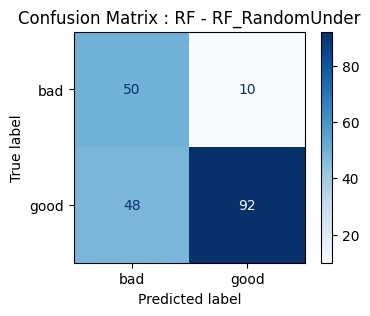


--- Classification Report for RF - RF_RandomUnder on Test Set ---
              precision    recall  f1-score   support

         bad       0.51      0.83      0.63        60
        good       0.90      0.66      0.76       140

    accuracy                           0.71       200
   macro avg       0.71      0.75      0.70       200
weighted avg       0.78      0.71      0.72       200


--- Key Metrics for RF - RF_RandomUnder on Test Set ---
  Accuracy: 0.7100
  F1-score (weighted): 0.7221
  F1-score (bad): 0.6329
  Precision (bad): 0.5102
  Recall (bad): 0.8333
-------------------------------------------------

F1 Score 'bad' finale RF sul Test Set: 0.6329
Estratto classificatore dalla pipeline.


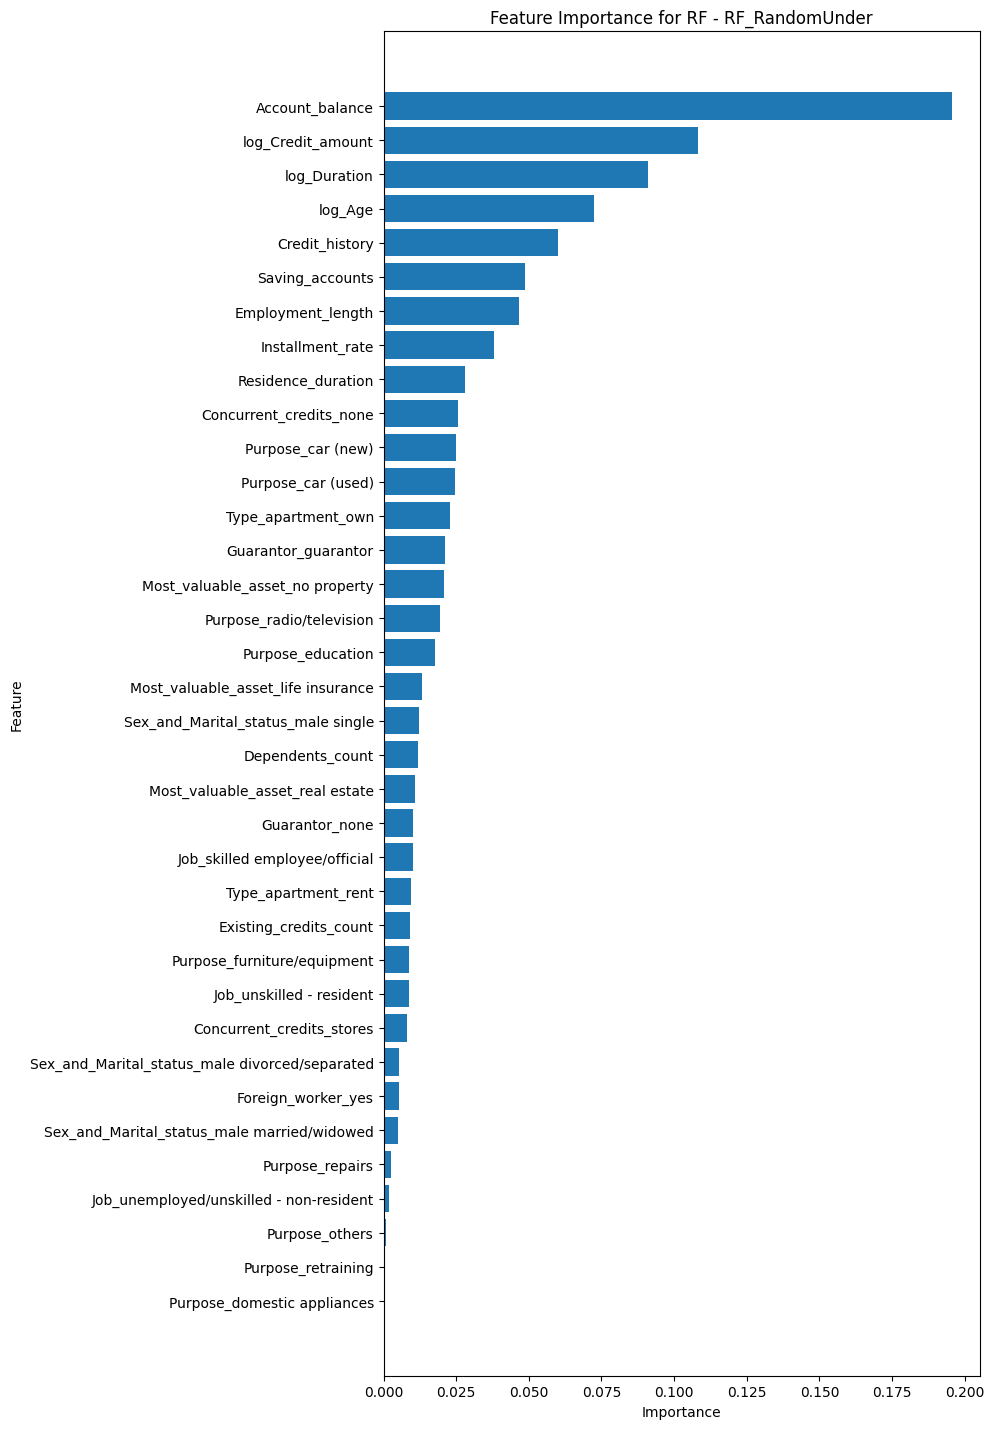

In [ ]:
print(f"\n{'='*15} SEZIONE 4.3: OTTIMIZZAZIONE RANDOM FOREST {'='*15}")

rf_results = {}

rf_param_grid = {
    # Originale: [50, 100, 200]
    'classifier__n_estimators': [100, 200],

    # Originale: [3, 10, None]
    'classifier__max_depth': [10, None],

    # Originale: [5, 10, 20]
    'classifier__min_samples_split': [5, 15],

    # Originale: [2, 10, 20]
    'classifier__min_samples_leaf': [2, 10],

    # Originale: [0.6, 0.8, 'sqrt', 'log2'].
    'classifier__max_features': ['sqrt', 0.7],

    # Originale: ['gini', 'entropy']
    'classifier__criterion': ['gini'],

    # 'classifier__bootstrap': [True, False]
}

samplers = {
    'None': None,
    'RandomOver': RandomOverSampler(random_state=RANDOM_SEED),
    'SMOTE': SMOTE(random_state=42, k_neighbors=min_neighbors_smote),
    'ADASYN': ADASYN(random_state=42, n_neighbors=min_neighbors_adasyn),
    'RandomUnder': RandomUnderSampler(random_state=42),
    'SMOTETomek': SMOTETomek(random_state=42),
}

# ---- Esegui GridSearch per RF con ogni sampler ----
print("\n" + "="*30 + " RANDOM FOREST " + "="*30)

for name, sampler in samplers.items():
    print(f"\n---- GridSearch RF con {name} ----")
    rf_classifier_base = RandomForestClassifier(random_state=RANDOM_SEED, n_jobs=-1) # Usa tutti i core
    rf_results[f"RF_{name}"] = run_grid_search_cv( # Aggiunto prefisso RF_
      model=rf_classifier_base,
      sampler=sampler,
      param_grid=rf_param_grid,
      X_train=X_train_processed_df,
      y_train=y_train_encoded,
      cv=cv,
      scoring_metric=f1_bad_scorer,
      cv_score_key=best_cv_score_key
    )

# ---- Esegui GridSearch per RF con ClassWeight ----
print(f"\n--- GridSearch RF con ClassWeight ---")
rf_param_grid_cw = rf_param_grid.copy()
rf_param_grid_cw['classifier__class_weight'] = ['balanced', 'balanced_subsample']
rf_classifier_cw = RandomForestClassifier(random_state=RANDOM_SEED, n_jobs=-1)
rf_results['RF_ClassWeight'] = run_grid_search_cv(
    model=rf_classifier_cw,
    sampler=None,
    param_grid=rf_param_grid_cw,
    X_train=X_train_processed_df,
    y_train=y_train_encoded,
    cv=cv,
    scoring_metric=f1_bad_scorer,
    cv_score_key=best_cv_score_key
)

# ---- Esegui GridSearch per RF SENZA Bilanciamento (Baseline) ----
print(f"\n--- GridSearch RF SENZA Bilanciamento (Baseline) ---")
rf_classifier_nobalance = RandomForestClassifier(random_state=RANDOM_SEED, n_jobs=-1)
rf_results['RF_NoBalance'] = run_grid_search_cv(
    model=rf_classifier_nobalance,
    sampler=None,
    param_grid=rf_param_grid, # Griglia base
    X_train=X_train_processed_df,
    y_train=y_train_encoded,
    cv=cv,
    scoring_metric=f1_bad_scorer,
    cv_score_key=best_cv_score_key
)

# ---- Confronto e Valutazione Finale Random Forest ----

print(f"\n{'='*20} Selezione Finale del Modello Random Forest {'='*20}")

# Stampa riepilogo risultati CV
print("\nRiepilogo Risultati Cross-Validation RF (F1 Score 'bad'):")
rf_summary = []
for name, result in rf_results.items():
    if result and best_cv_score_key in result:
        score = result[best_cv_score_key]
        rf_summary.append({'Metodo': name, best_cv_score_key: score})
    else:
        rf_summary.append({'Metodo': name, best_cv_score_key: np.nan})

summary_cv_rf_df = pd.DataFrame(rf_summary).sort_values(best_cv_score_key, ascending=False)
display(summary_cv_rf_df.round(4).fillna('Errore'))

# Trova la miglior configurazione COMPLESSIVA
best_overall_rf_method_name = summary_cv_rf_df.iloc[0]['Metodo']

best_overall_rf_result = rf_results[best_overall_rf_method_name]
best_overall_rf_cv_score = best_overall_rf_result[best_cv_score_key]
best_rf_pipeline_final = best_overall_rf_result['best_model_estimator']

print(f"\n---> Miglior Metodo Complessivo per Random Forest (basato su CV F1 'bad'): {best_overall_rf_method_name}")
print(f"---> Miglior F1-score 'bad' (CV): {best_overall_rf_cv_score:.4f}")
print("Parametri Ottimali (all'interno della pipeline):")
best_params_final_rf = best_overall_rf_result['best_params']
for param, value in best_params_final_rf.items():
      print(f"  {param}: {value}")

# Valutazione finale SUL TEST SET
print(f"\n--- Valutazione Finale del Modello Migliore ({best_overall_rf_method_name}) sul Test Set ---")
X_test_input = X_test_processed_df if X_test_processed_df is not None else X_test_processed
final_f1_bad_test_rf = evaluate_model(
    model=best_rf_pipeline_final,
    X_test=X_test_input,
    y_test=y_test_encoded,
    model_name=f"RF - {best_overall_rf_method_name}",
    class_names=class_names,
    bad_label_index=bad_label_index
)
print(f"\nF1 Score 'bad' finale RF sul Test Set: {final_f1_bad_test_rf:.4f}")

# --- Visualizzazioni per il Modello Finale Migliore ---
if X_train_processed_df is not None:
    feature_names = list(X_train_processed_df.columns)
# ... (fallback a feature_i come prima) ...
else:
      feature_names = [f'feature_{i}' for i in range(X_test_processed_df.shape[1])]

# Visualizza Feature Importances (Random Forest ha .feature_importances_)
importances_rf = get_feature_importances(best_rf_pipeline_final, feature_names) # Passa la pipeline
visualize_feature_importances(importances_rf, f"RF - {best_overall_rf_method_name}")

## 4.4 Support Vector Machine

In questa sezione, ottimizzeremo queste due implementazioni (`SVC` con RBF e `LinearSVC`) cercando i valori ottimali per $C$ (e $\gamma$ per RBF), considerando anche le strategie di gestione dello sbilanciamento delle classi e usando l'F1-score sulla classe 'bad' come metrica principale.

**Importante**: abbiamo già scalato i dati con `StandardScaler`, poiché SVM è sensibile alla scala delle feature.

L'obiettivo del soft margin SVM può essere espresso come un problema di ottimizzazione:

$$
\min_{w, b, \xi} \frac{1}{2} ||w||^2 + C \sum_{i=1}^{N} \xi_i
$$

soggetto ai vincoli:

$$
y_i (w \cdot x_i + b) \ge 1 - \xi_i, \quad \xi_i \ge 0 \quad \forall i=1, \dots, N
$$

Dove:
*   $w$ è il vettore normale all'iperpiano.
*   $b$ è il termine di bias (offset).
*   $x_i$ è il vettore delle feature per il campione $i$.
*   $y_i \in \{-1, +1\}$ è l'etichetta della classe per il campione $i$.
*   $N$ è il numero totale di campioni di training.
*   $\xi_i$ sono le variabili di "slack" (o margine lasco) che permettono a certi campioni di violare il margine o di essere classificati erroneamente.
*   $C > 0$ è l'**iperparametro di regolarizzazione**. Questo parametro fondamentale controlla il trade-off tra la massimizzazione del margine (minimizzando $||w||^2$) e la minimizzazione dell'errore di classificazione (minimizzando $\sum \xi_i$).
    *   Un **valore piccolo di $C$** aumenta la penalità relativa al termine $||w||^2$, incoraggiando un margine più ampio anche a costo di più violazioni $\xi_i$. Questo porta a una regolarizzazione più forte, rendendo il modello più tollerante agli errori sui dati di training e potenzialmente più semplice (rischio di underfitting).
    *   Un **valore grande di $C$** riduce la penalità relativa al termine $||w||^2$, dando più peso alla minimizzazione degli errori $\xi_i$. Il modello cercherà di classificare correttamente quanti più campioni di training possibile, anche a costo di un margine più stretto. Questo corrisponde a una regolarizzazione più debole e può portare a modelli più complessi (rischio di overfitting).
    *   *Nota:* Questo iperparametro `C` è presente sia in `SVC` che in `LinearSVC`.

Per gestire relazioni non lineari, `SVC` utilizza il "kernel trick", mappando implicitamente i dati in uno spazio a dimensionalità superiore tramite una funzione kernel $K(x_i, x_j)$. Nel nostro caso usiamo il **Radial Basis Function (RBF)**, poiché è dimostrato sperimentalmente che funziona bene su una vasta gamma di problemi:

$$
K(x_i, x_j) = \exp(-\gamma ||x_i - x_j||^2)
$$

Dove:
*   $x_i, x_j$ sono due campioni.
*   $||x_i - x_j||^2$ è la distanza Euclidea al quadrato tra i due campioni.
*   $\gamma > 0$ è l'**iperparametro gamma**, specifico del kernel RBF (e di altri kernel simili). Questo parametro definisce quanto lontano si estende l'influenza di un singolo campione di training.
    *   Un **valore piccolo di $\gamma$** significa che l'influenza di un punto si estende lontano (la curva esponenziale decresce lentamente con la distanza). Il modello risultante tende ad essere più "liscio" e meno sensibile ai singoli punti, comportandosi in modo più simile a un modello lineare (rischio di underfitting se troppo basso).
    *   Un **valore grande di $\gamma$** significa che l'influenza di un punto è molto locale (la curva esponenziale decresce rapidamente). Il modello può adattarsi molto strettamente ai dati di training, creando regioni di decisione complesse e potenzialmente isolando singoli punti (rischio di overfitting).
    *   `scikit-learn` offre opzioni come `'scale'` ( $\gamma = 1 / (n_{\text{features}} \times X.\text{var()})$ ) e `'auto'` ( $\gamma = 1 / n_{\text{features}}$ ) come default intelligenti basati sui dati.

In [ ]:
print(f"\n{'='*15} SEZIONE 4.4: OTTIMIZZAZIONE SVM (SVC & LinearSVC) {'='*15}")

svm_results = {}
best_svm_pipelines = {}

svc_param_grid = [
    # Griglia per Kernel RBF
    {
        'classifier__kernel': ['rbf'],
        'classifier__C': [0.1, 1, 10, 50, 100],
        'classifier__gamma': ['scale', 'auto', 0.01, 0.1, 1],
        'classifier__class_weight': [None, 'balanced'] # Testa class_weight per RBF
    },
    # Griglia per Kernel Lineare
    {
        'classifier__kernel': ['linear'],
        'classifier__C': [0.01, 0.1, 1, 10, 100], # Range di C per lineare
        'classifier__class_weight': [None, 'balanced'] # Testa class_weight per lineare
    }
]

print(f"\n{'='*20} OTTIMIZZAZIONE SVC (Kernel RBF e Lineare) {'='*20}")


# ---- Esegui GridSearch per SVC (RBF) con ogni sampler ----
for name, sampler in samplers.items():
    print(f"---- GridSearch SVC: {name} ----")
    svc_classifier_base = SVC(probability=True, random_state=RANDOM_SEED)
    method_name = f"SVC_{name}"
    svm_results[method_name] = run_grid_search_cv(
    model=svc_classifier_base,
    sampler=sampler,
    param_grid=svc_param_grid,
    X_train=X_train_processed_df,
    y_train=y_train_encoded,
    cv=cv,
    scoring_metric=f1_bad_scorer,
    cv_score_key=best_cv_score_key
)

best_svm_pipelines[method_name] = svm_results[method_name]['best_model_estimator'] # Fixed: dedented, added method_name for access


# ---- Confronto e Valutazione Finale SVM ----

print(f"\n{'='*20} Selezione Finale del Modello SVM {'='*20}")

# Stampiamo riepilogo risultati CV per ogni metodo testato
print("\nRiepilogo Risultati Cross-Validation SVM (F1 Score 'bad'):")
svm_summary = []
for name, result in svm_results.items():
    if result and best_cv_score_key in result:
        score = result[best_cv_score_key]
        svm_summary.append({'Metodo': name, best_cv_score_key: score})
    else:
        svm_summary.append({'Metodo': name, best_cv_score_key: np.nan})

summary_cv_svm_df = pd.DataFrame(svm_summary).sort_values(best_cv_score_key, ascending=False)
display(summary_cv_svm_df.round(4).fillna('Errore'))


# Troviamo la miglior configurazione COMPLESSIVA basata sul CV F1 score per 'bad'
best_overall_svm_method_name = summary_cv_svm_df.iloc[0]['Metodo']


best_overall_svm_result = svm_results[best_overall_svm_method_name]
best_overall_svm_cv_score = best_overall_svm_result[best_cv_score_key]
best_svm_pipeline_final = best_overall_svm_result['best_model_estimator']

print(f"\n---> Miglior Metodo Complessivo per SVM (basato su CV F1 'bad'): {best_overall_svm_method_name}")
print(f"---> Miglior F1-score 'bad' (CV): {best_overall_svm_cv_score:.4f}")
print("Parametri Ottimali (all'interno della pipeline):")
best_params_final_svm = best_overall_svm_result['best_params']
for param, value in best_params_final_svm.items():
      print(f"  {param}: {value}")


=============== SEZIONE 4.4: OTTIMIZZAZIONE SVM (SVC & LinearSVC) ===============

==================== OTTIMIZZAZIONE SVC (Kernel RBF e Lineare) ====================
---- GridSearch SVC: None ----
Fitting 5 folds for each of 60 candidates, totalling 300 fits
Migliori iperparametri (senza sampler None): {'classifier__C': 10, 'classifier__class_weight': 'balanced', 'classifier__gamma': 0.01, 'classifier__kernel': 'rbf'}
Miglior score (custom) (CV): 0.5878 su CV: 0.5878
---- GridSearch SVC: RandomOver ----
Fitting 5 folds for each of 60 candidates, totalling 300 fits
Migliori iperparametri (con sampler RandomOverSampler): {'classifier__C': 0.01, 'classifier__class_weight': None, 'classifier__kernel': 'linear'}
Miglior score (custom) (CV): 0.5769 su CV: 0.5769
---- GridSearch SVC: SMOTE ----
Fitting 5 folds for each of 60 candidates, totalling 300 fits
Migliori iperparametri (con sampler SMOTE): {'classifier__C': 1, 'classifier__class_weight': None, 'classifier__gamma': 0.01, 'classifier

,Metodo,best_f1_bad_cv
0,SVC_None,0.5878
4,SVC_RandomUnder,0.5857
2,SVC_SMOTE,0.5847
3,SVC_ADASYN,0.5782
1,SVC_RandomOver,0.5769
5,SVC_SMOTETomek,0.5719



---> Miglior Metodo Complessivo per SVM (basato su CV F1 'bad'): SVC_None
---> Miglior F1-score 'bad' (CV): 0.5878
Parametri Ottimali (all'interno della pipeline):
  classifier__C: 10
  classifier__class_weight: balanced
  classifier__gamma: 0.01
  classifier__kernel: rbf


## 5.5 Logistic Regression

La Regresione Logistica è un modello lineare. Stima la proobabilita che un campione appartenga a una classe specifica utilizzando una funzione logistica(sigmoide) applicata a una combinazione lineare delle feature di input.

$$
P(y=1|x) = \sigma(w \cdot x + b) = \frac{1}{1 + e^{-(w \cdot x + b)}}
$$

Dove:
*   $P(y=1|x)$ è la probabilità che il campione $x$ appartenga alla classe positiva (es., 'good').
*   $w$ è il vettore dei pesi (coefficienti) associati a ciascuna feature.
*   $b$ è il termine di bias (intercetta).
*   $\sigma(\cdot)$ è la funzione sigmoide.

LR è efficace quanto c'è una relazione lineare tra le feature e il log-odds del target. Tuttavia, è sensibilie alla multicollinearità. Nel nostro caso con `drop='first'` nell'OHE dovremmo averne mitigati gli effetti.

Per l'implementazione del modello di Logistic Regression abbiamo testato diversi valori per i seguenti iperparametri:

* `penalty`: specifica la norma (il tipo di penalità) utilizzata nella regolarizzazione. La regolarizzazione aggiunge un termine di penalità alla funzione di costo per prevenire l'overfitting, penalizzando coefficienti troppo grandi.
Ne abbiamo testato due versioni:

  1.   `l1` (Lasso): aggiunge una penalità proporzionale alla somma dei valori assoluti dei coefficienti. Tende a produrre soluzioni "sparse", ovvero imposta alcuni coefficienti esattamente a zero, effettuando implicitamente una selezione delle feature.
  2.   `l2` (Ridge): aggiunge una penalità proporzionale alla somma dei valori al quadrato dei coefficienti. Tende a ridurre tutti i coefficienti verso lo zero in modo più uniforme, ma raramente li annulla completamente.

  La scelta tra `l1` e `l2` influenza quali feature il modello considera importanti e quanto "semplice" (meno incline all'overfitting) cerca di essere. l1 può essere utile se si sospetta che molte feature siano irrilevanti. l2 è spesso un buon default e funziona bene in generale.

* `C`: è un parametro di regolarizzazione positivo che controlla l'inverso della forza della regolarizzazione.
Valori piccoli di C indicano una regolarizzazione forte. La penalità per coefficienti grandi è alta, quindi il modello sarà più semplice, il che riduce l'overfitting ma può aumentare il rischio di underfitting.
Valori grandi di C indicano una regolarizzazione debole. La penalità è bassa, quindi il modello è più libero di adattarsi ai dati di training, il che riduce l'underfitting ma può aumentare il rischio di overfitting.

* `solver`: indica l'algoritmo utilizzato nel processo di ottimizzazione per trovare i coefficienti del modello che minimizzano la funzione di costo (inclusa la penalità di regolarizzazione).
Diversi solver hanno diverse proprietà in termini di velocità, capacità di gestire grandi dataset e tipi di regolarizzazione supportati.
`liblinear` è una buona scelta per dataset di dimensioni piccole o medie. È importante notare che supporta sia la regolarizzazione `l1` che `l2`, il che lo rende adatto per questa specifica griglia di parametri.


=============== SEZIONE 4.5: OTTIMIZZAZIONE LOGISTIC REGRESSION ===============

============================== LOGISTIC REGRESSION ==============================

==================== GridSearch LR: None ====================
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Migliori iperparametri (senza sampler None): {'classifier__C': 0.001, 'classifier__penalty': 'l1', 'classifier__solver': 'liblinear'}
Miglior score (custom) (CV): 0.4615 su CV: 0.4615

==================== GridSearch LR: RandomOver ====================
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Migliori iperparametri (con sampler RandomOverSampler): {'classifier__C': 0.01, 'classifier__penalty': 'l2', 'classifier__solver': 'liblinear'}
Miglior score (custom) (CV): 0.5753 su CV: 0.5753

==================== GridSearch LR: SMOTE ====================
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Migliori iperparametri (con sampler SMOTE): {'classifier__C': 0.1, 'classifier_

,Metodo,best_f1_bad_cv
4,LR_RandomUnder,0.5921
2,LR_SMOTE,0.5889
6,LR_ClassWeight,0.5869
3,LR_ADASYN,0.5761
1,LR_RandomOver,0.5753
5,LR_SMOTETomek,0.5602
0,LR_None,0.4615
7,LR_NoBalance,0.4615



---> Miglior Metodo Complessivo per Log. Regression (basato su CV F1 'bad'): LR_RandomUnder
---> Miglior F1-score 'bad' (CV): 0.5921
Parametri Ottimali (all'interno della pipeline):
  classifier__C: 0.1
  classifier__penalty: l2
  classifier__solver: liblinear

--- Valutazione Finale del Modello Migliore (LR_RandomUnder) sul Test Set ---


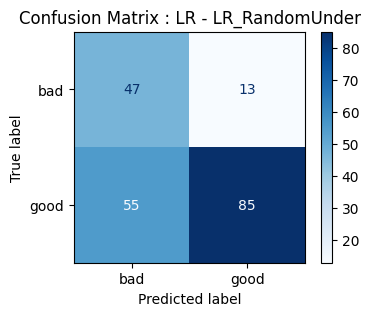


--- Classification Report for LR - LR_RandomUnder on Test Set ---
              precision    recall  f1-score   support

         bad       0.46      0.78      0.58        60
        good       0.87      0.61      0.71       140

    accuracy                           0.66       200
   macro avg       0.66      0.70      0.65       200
weighted avg       0.75      0.66      0.67       200


--- Key Metrics for LR - LR_RandomUnder on Test Set ---
  Accuracy: 0.6600
  F1-score (weighted): 0.6741
  F1-score (bad): 0.5802
  Precision (bad): 0.4608
  Recall (bad): 0.7833
-------------------------------------------------

F1 Score 'bad' finale LR sul Test Set: 0.5802


In [ ]:
print(f"\n{'='*15} SEZIONE 4.5: OTTIMIZZAZIONE LOGISTIC REGRESSION {'='*15}")

lr_results = {}

lr_param_grid = {
    'classifier__penalty': ['l1', 'l2'], # Tipo di regolarizzazione
    'classifier__C': [0.001, 0.01, 0.1, 1, 10, 100], # Inverso della forza di regolarizzazione
    'classifier__solver': ['liblinear'], # Algoritmo di ottimizzazione
    # 'classifier__max_iter': [5000] # Aumenta se ci sono warning di convergenza
    # Non includiamo class_weight qui, lo gestiamo separatamente
}

# ---- Esegui GridSearch per LR con ogni sampler ----
print("\n" + "="*30 + " LOGISTIC REGRESSION " + "="*30)

for name, sampler in samplers.items():
    print(f"\n{'='*20} GridSearch LR: {name} {'='*20}")
    # Impostiamo max_iter elevato per assicurare convergenza
    lr_classifier_base = LogisticRegression(random_state=RANDOM_SEED, max_iter=5000, solver='liblinear')

    # --- Usa la stessa firma di run_grid_search_cv ---
    lr_results[f"LR_{name}"] = run_grid_search_cv( # Aggiunto prefisso LR_
        model=lr_classifier_base,
        sampler=sampler,
        param_grid=lr_param_grid,
        X_train=X_train_processed_df,
        y_train=y_train_encoded,
        cv=cv,
        scoring_metric=f1_bad_scorer,
        cv_score_key=best_cv_score_key
    )

# ---- Esegui GridSearch per LR con ClassWeight ----
print(f"\n---- GridSearch LR con ClassWeight ----")
lr_param_grid_cw = lr_param_grid.copy()
lr_param_grid_cw['classifier__class_weight'] = ['balanced']
lr_classifier_cw = LogisticRegression(random_state=RANDOM_SEED, max_iter=2000, solver='liblinear')
lr_results['LR_ClassWeight'] = run_grid_search_cv(
    model=lr_classifier_cw,
    sampler=None,
    param_grid=lr_param_grid_cw,
    X_train=X_train_processed_df,
    y_train=y_train_encoded,
    cv=cv,
    scoring_metric=f1_bad_scorer,
    cv_score_key=best_cv_score_key
)

# ---- Esegui GridSearch per LR SENZA Bilanciamento (Baseline) ----
print(f"\n---- GridSearch LR SENZA Bilanciamento (Baseline) ----")
lr_classifier_nobalance = LogisticRegression(random_state=RANDOM_SEED, max_iter=2000, solver='liblinear')
lr_results['LR_NoBalance'] = run_grid_search_cv(
    model=lr_classifier_nobalance,
    sampler=None,
    param_grid=lr_param_grid,
    X_train=X_train_processed_df,
    y_train=y_train_encoded,
    cv=cv,
    scoring_metric=f1_bad_scorer,
    cv_score_key=best_cv_score_key
)

# --- Confronto e Valutazione Finale Logistic Regression ---

print(f"\n{'='*20} Selezione Finale del Modello Logistic Regression {'='*20}")

# Stampa riepilogo risultati CV
print("\nRiepilogo Risultati Cross-Validation LR (F1 Score 'bad'):")
lr_summary = []
for name, result in lr_results.items():
    if result and best_cv_score_key in result:
        score = result[best_cv_score_key]
        lr_summary.append({'Metodo': name, best_cv_score_key: score})
    else:
        lr_summary.append({'Metodo': name, best_cv_score_key: np.nan})

summary_cv_lr_df = pd.DataFrame(lr_summary).sort_values(best_cv_score_key, ascending=False)
display(summary_cv_lr_df.round(4).fillna('Errore'))

# Trova la miglior configurazione COMPLESSIVA
best_overall_lr_method_name = summary_cv_lr_df.iloc[0]['Metodo']

if pd.isna(summary_cv_lr_df.iloc[0][best_cv_score_key]):
     print("\nERRORE: Nessun risultato valido trovato da nessuna GridSearch per Logistic Regression.")
else:
    best_overall_lr_result = lr_results[best_overall_lr_method_name]
    best_overall_lr_cv_score = best_overall_lr_result[best_cv_score_key]
    best_lr_pipeline_final = best_overall_lr_result['best_model_estimator']

    print(f"\n---> Miglior Metodo Complessivo per Log. Regression (basato su CV F1 'bad'): {best_overall_lr_method_name}")
    print(f"---> Miglior F1-score 'bad' (CV): {best_overall_lr_cv_score:.4f}")
    print("Parametri Ottimali (all'interno della pipeline):")
    best_params_final_lr = best_overall_lr_result['best_params']
    for param, value in best_params_final_lr.items():
         print(f"  {param}: {value}")

    # Valutazione finale SUL TEST SET
    print(f"\n--- Valutazione Finale del Modello Migliore ({best_overall_lr_method_name}) sul Test Set ---")
    X_test_input = X_test_processed_df if X_test_processed_df is not None else X_test_processed
    final_f1_bad_test_lr = evaluate_model(
        model=best_lr_pipeline_final,
        X_test=X_test_input,
        y_test=y_test_encoded,
        model_name=f"LR - {best_overall_lr_method_name}",
        class_names=class_names,
        bad_label_index=bad_label_index
    )
    print(f"\nF1 Score 'bad' finale LR sul Test Set: {final_f1_bad_test_lr:.4f}")

## 5.6 AdaBoost

L'implementazione di AdaBoost prova diversi valori per i seguenti iperparametri:

* `n_estimators`: specifica il numero massimo di "weak learners" (stimatori deboli, alberi decisionali molto semplici) che verranno costruiti sequenzialmente. AdaBoost si ferma prima se raggiunge una classificazione perfetta o se non riesce a migliorare ulteriormente.
Ogni nuovo stimatore viene addestrato ponendo maggiore enfasi sui campioni che gli stimatori precedenti avevano classificato erroneamente. Aumentare n_estimators permette al modello di correggere progressivamente gli errori.
* `learning_rate`: controlla il contributo (o "peso") di ciascun weak learner alla combinazione finale. Riduce il contributo di ogni classificatore di un fattore pari a `learning_rate`.
Un learning_rate pari a 1.0 significa che ogni stimatore contribuisce pienamente.


============================== ADABOOST (Ottimizzato per F1 'bad')==============================

==================== GridSearch AdaBoost: None ====================
Fitting 5 folds for each of 25 candidates, totalling 125 fits
Migliori iperparametri (senza sampler None): {'classifier__learning_rate': 1.0, 'classifier__n_estimators': 400}
Miglior score (custom) (CV): 0.5280 su CV: 0.5280

==================== GridSearch AdaBoost: RandomOver ====================
Fitting 5 folds for each of 25 candidates, totalling 125 fits
Migliori iperparametri (con sampler RandomOverSampler): {'classifier__learning_rate': 1.0, 'classifier__n_estimators': 300}
Miglior score (custom) (CV): 0.6159 su CV: 0.6159

==================== GridSearch AdaBoost: SMOTE ====================
Fitting 5 folds for each of 25 candidates, totalling 125 fits
Migliori iperparametri (con sampler SMOTE): {'classifier__learning_rate': 1.0, 'classifier__n_estimators': 100}
Miglior score (custom) (CV): 0.6077 su CV: 0.6077

==

,Metodo,best_f1_bad_cv
5,Ada_SMOTETomek,0.6327
1,Ada_RandomOver,0.6159
2,Ada_SMOTE,0.6077
3,Ada_ADASYN,0.6067
4,Ada_RandomUnder,0.6046
0,Ada_None,0.5280
6,Ada_NoBalance,0.5280



---> Miglior Metodo Complessivo per AdaBoost (basato su CV F1 'bad'): Ada_SMOTETomek
---> Miglior F1-score 'bad' (CV): 0.6327
Parametri Ottimali (all'interno della pipeline):
  classifier__learning_rate: 0.5
  classifier__n_estimators: 300

--- Valutazione Finale del Modello Migliore (Ada_SMOTETomek) sul Test Set ---


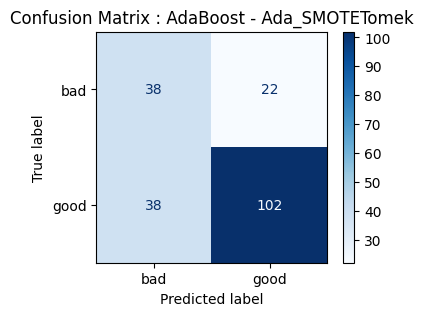


--- Classification Report for AdaBoost - Ada_SMOTETomek on Test Set ---
              precision    recall  f1-score   support

         bad       0.50      0.63      0.56        60
        good       0.82      0.73      0.77       140

    accuracy                           0.70       200
   macro avg       0.66      0.68      0.67       200
weighted avg       0.73      0.70      0.71       200


--- Key Metrics for AdaBoost - Ada_SMOTETomek on Test Set ---
  Accuracy: 0.7000
  F1-score (weighted): 0.7086
  F1-score (bad): 0.5588
  Precision (bad): 0.5000
  Recall (bad): 0.6333
-------------------------------------------------------

Estratto classificatore AdaBoost dalla pipeline finale.

Visualizzazione Feature Importances dal modello AdaBoost migliore:
Input 'model' trattato come classificatore diretto.


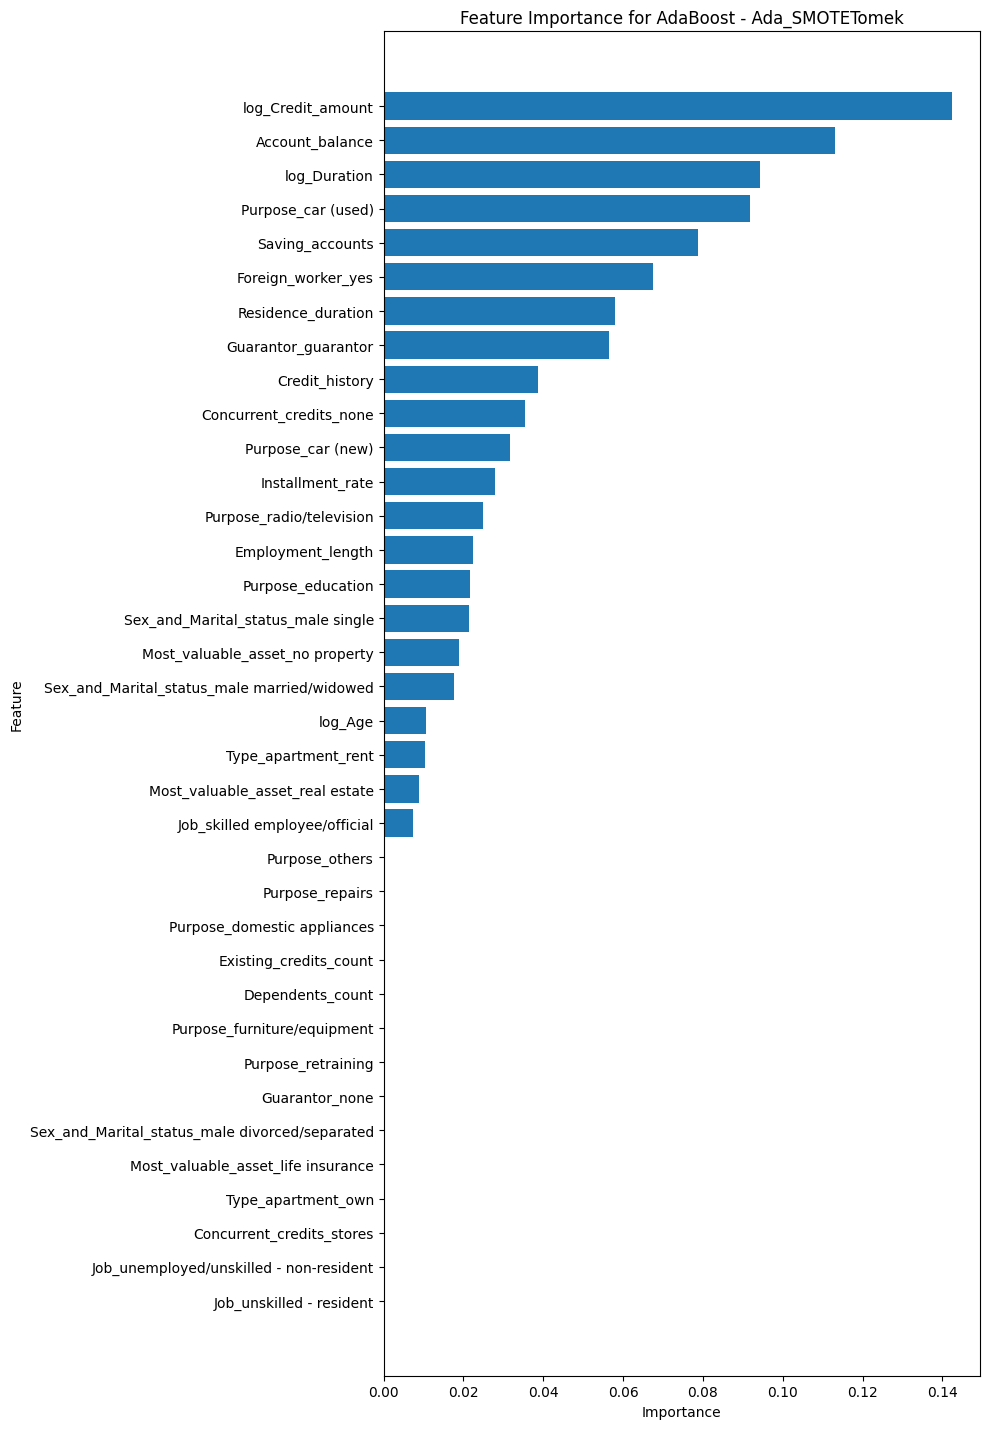


Visualizzazione del primo albero base (weak learner) dal modello AdaBoost migliore:


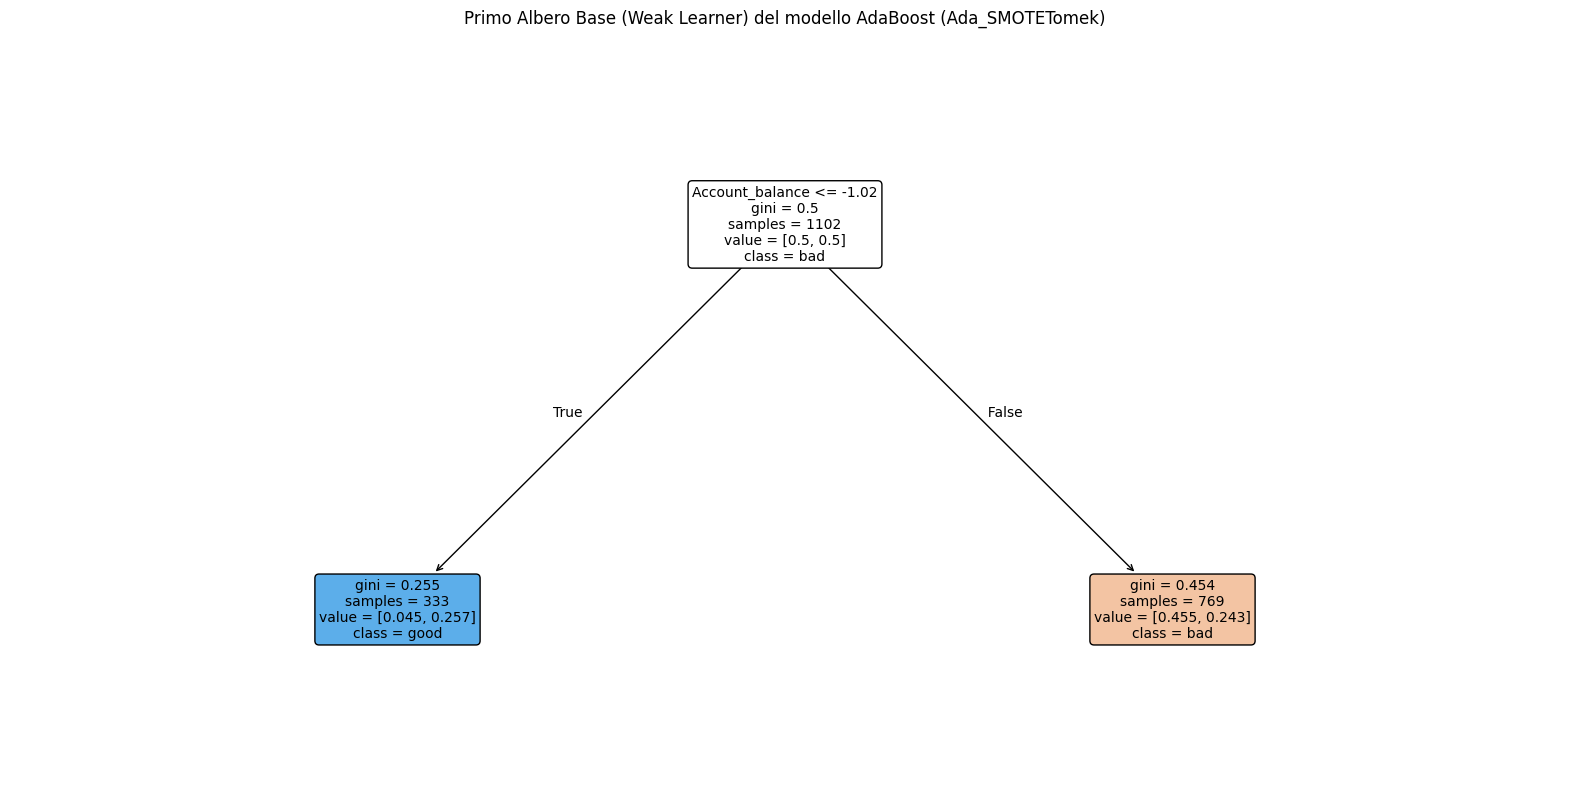

In [ ]:
# --- AdaBoost (Standardizzato come Decision Tree / Logistic Regression) ---

# Assicurati che f1_bad_scorer e best_cv_score_key siano definiti prima di questo blocco
# Esempio:
# f1_bad_scorer = make_scorer(f1_score, pos_label=bad_label_index, average='binary', zero_division=0)
# best_cv_score_key = 'best_f1_bad_cv' # F1 'bad' medio su cv

# Assumiamo che le seguenti variabili siano già definite dalle sezioni precedenti:
# RANDOM, X_train_processed_df, y_train_encoded, X_test_processed_df, y_test_encoded
# cv, samplers, label_encoder
# f1_bad_scorer, best_cv_score_key # Definiti come sopra
# La funzione run_grid_search_cv
# Le funzioni evaluate_model, get_feature_importances, visualize_feature_importances

RANDOM = 42

ada_param_grid = {
    'classifier__n_estimators': [50, 100, 200, 300, 400],
    'classifier__learning_rate': [0.01, 0.05, 0.1, 0.5, 1.0],
    # 'classifier__algorithm': ['SAMME.R', 'SAMME'] # SAMME.R è spesso migliore
}

# Esecuzione della grid search per ogni tecnica de resampling con AdaBoost
ada_results = {}
print("\n" + "="*30 + " ADABOOST (Ottimizzato per F1 'bad')" + "="*30)
for name, sampler in samplers.items():
    print(f"\n{'='*20} GridSearch AdaBoost: {name} {'='*20}")
    # Istanzia AdaBoostClassifier
    # Nota: AdaBoost di default usa DecisionTreeClassifier(max_depth=1) come base estimator
    ada_classifier = AdaBoostClassifier(random_state=RANDOM)

    # --- Usa run_grid_search_cv con f1_bad_scorer ---
    grid_result = run_grid_search_cv(
        model=ada_classifier,
        sampler=sampler,
        param_grid=ada_param_grid,
        X_train=X_train_processed_df,   # Usa DataFrame
        y_train=y_train_encoded,
        cv=cv,
        scoring_metric=f1_bad_scorer, # <-- MODIFICA: Usa f1_bad_scorer
        cv_score_key=best_cv_score_key  # <-- MODIFICA: Usa la chiave F1-bad
    )
    ada_results[f"Ada_{name}"] = grid_result # Salva con prefisso per chiarezza
    # Non calcoliamo/salviamo lo score sul test set qui

# --- Esegui GridSearch per AdaBoost SENZA Bilanciamento (Baseline) ---
# AdaBoost non ha un parametro 'class_weight' diretto, quindi testiamo solo senza sampler
print(f"\n{'='*20} GridSearch AdaBoost: Baseline (No Balancing) {'='*20}")
ada_classifier_nobalance = AdaBoostClassifier(random_state=RANDOM)
grid_result_nobalance = run_grid_search_cv(
    model=ada_classifier_nobalance,
    sampler=None,
    param_grid=ada_param_grid, # Griglia originale
    X_train=X_train_processed_df, # Usa DataFrame
    y_train=y_train_encoded,
    cv=cv,
    scoring_metric=f1_bad_scorer, # <-- MODIFICA: Usa f1_bad_scorer
    cv_score_key=best_cv_score_key # <-- MODIFICA: Usa la chiave F1-bad
)
ada_results['Ada_NoBalance'] = grid_result_nobalance # Salva con prefisso


# --- Confronto Globale e Valutazione Finale AdaBoost (come per DT/LR) ---

print(f"\n{'='*20} Confronto metodi e Valutazione Finale del Modello AdaBoost {'='*20}")

# Stampa riepilogo risultati CV per ogni metodo testato
print("\nRiepilogo Risultati Cross-Validation (F1 Score 'bad'):")
ada_results_summary = []
for name, result in ada_results.items():
    if result and best_cv_score_key in result:
        score = result[best_cv_score_key]
        ada_results_summary.append({'Metodo': name, best_cv_score_key: score})
    else:
        ada_results_summary.append({'Metodo': name, best_cv_score_key: np.nan})

ada_summary_cv_df = pd.DataFrame(ada_results_summary).sort_values(best_cv_score_key, ascending=False)
display(ada_summary_cv_df.round(4).fillna('Errore'))


# Trova la miglior configurazione COMPLESSIVA basata sul CV F1 score per 'bad'
ada_best_overall_method_name = ada_summary_cv_df.iloc[0]['Metodo'] # Il primo dopo l'ordinamento

# Gestisci caso in cui nessun risultato sia valido
if pd.isna(ada_summary_cv_df.iloc[0][best_cv_score_key]):
     print("\nERRORE: Nessun risultato valido trovato da nessuna GridSearch per AdaBoost.")
else:
    ada_best_overall_result = ada_results[ada_best_overall_method_name]
    ada_best_overall_cv_score = ada_best_overall_result[best_cv_score_key]
    # Ottieni la pipeline completa (con sampler se presente) e i parametri OTTIMIZZATI
    best_ada_pipeline_final = ada_best_overall_result['best_model_estimator'] # <-- Variabile finale

    print(f"\n---> Miglior Metodo Complessivo per AdaBoost (basato su CV F1 'bad'): {ada_best_overall_method_name}")
    print(f"---> Miglior F1-score 'bad' (CV): {ada_best_overall_cv_score:.4f}")
    print("Parametri Ottimali (all'interno della pipeline):")
    # Stampa i parametri specifici del classificatore trovati
    best_params_final = ada_best_overall_result['best_params']
    for param, value in best_params_final.items():
         print(f"  {param}: {value}")

    # Esegui la valutazione finale SUL TEST SET usando la pipeline migliore
    print(f"\n--- Valutazione Finale del Modello Migliore ({ada_best_overall_method_name}) sul Test Set ---")
    # Usa la funzione evaluate_model definita precedentemente
    final_f1_bad_test_ada = evaluate_model( # Salva l'output F1-bad se ti serve
        model=best_ada_pipeline_final,
        X_test=X_test_processed_df, # Usa DataFrame
        y_test=y_test_encoded,
        model_name=f"AdaBoost - {ada_best_overall_method_name}", # Nome descrittivo
        class_names=class_names,
        bad_label_index=bad_label_index
    )
    # print(f"\nF1 Score 'bad' finale sul Test Set per AdaBoost: {final_f1_bad_test_ada:.4f}")

     # --- Visualizzazioni per il Modello Finale Migliore ---
    feature_names_for_plot = X_train_processed_df.columns.tolist()

     # Estrai il classificatore effettivo dalla pipeline finale
    best_classifier_ada_final = None
    if hasattr(best_ada_pipeline_final, 'named_steps') and 'classifier' in best_ada_pipeline_final.named_steps:
        best_classifier_ada_final = best_ada_pipeline_final.named_steps['classifier']
        print("\nEstratto classificatore AdaBoost dalla pipeline finale.")
    elif isinstance(best_ada_pipeline_final, AdaBoostClassifier):
         best_classifier_ada_final = best_ada_pipeline_final # Se non è una pipeline
         print("\nUtilizzo l'estimator AdaBoost diretto (non pipeline).")
    else:
         print(f"\nATTENZIONE: Impossibile estrarre un classificatore AdaBoost valido dalla pipeline finale ({type(best_ada_pipeline_final).__name__}).")


    # Visualizza Feature Importances (se il modello è AdaBoost e ha feature_importances_)
    if best_classifier_ada_final is not None and isinstance(best_classifier_ada_final, AdaBoostClassifier) and hasattr(best_classifier_ada_final, 'feature_importances_'):
        print("\nVisualizzazione Feature Importances dal modello AdaBoost migliore:")
        try:
            # Passa il classificatore estratto e i nomi corretti
            # La funzione get_feature_importances dovrebbe già gestire l'estrazione se necessario
            importances_ada_df = get_feature_importances(best_classifier_ada_final, feature_names_for_plot)
            visualize_feature_importances(importances_ada_df, f"AdaBoost - {ada_best_overall_method_name}")
        except NameError:
            print("Funzioni 'get_feature_importances' o 'visualize_feature_importances' non trovate.")
        except Exception as e:
            print(f"Errore nella visualizzazione delle feature importance per AdaBoost: {e}")

        # Visualizza il primo weak learner (albero base) - Logica invariata
        print("\nVisualizzazione del primo albero base (weak learner) dal modello AdaBoost migliore:")
        if hasattr(best_classifier_ada_final, 'estimators_') and len(best_classifier_ada_final.estimators_) > 0:
            try:
                from sklearn.tree import plot_tree, DecisionTreeClassifier
                import matplotlib.pyplot as plt

                first_tree = best_classifier_ada_final.estimators_[0]
                if isinstance(first_tree, DecisionTreeClassifier):
                    plt.figure(figsize=(20,10))
                    plot_tree(first_tree,
                              feature_names=feature_names_for_plot,
                              class_names=class_names,
                              filled=True,
                              rounded=True,
                              fontsize=10)
                    plt.title(f"Primo Albero Base (Weak Learner) del modello AdaBoost ({ada_best_overall_method_name})")
                    plt.show()
                else:
                    print("Il primo estimator non è un DecisionTreeClassifier, visualizzazione non disponibile con plot_tree.")
            except Exception as e:
                print(f"Impossibile visualizzare l'albero base di AdaBoost: {e}")
        else:
            print("Nessun estimator trovato nel modello AdaBoost addestrato.")

    elif best_classifier_ada_final is not None:
         print(f"Il miglior classificatore finale ({type(best_classifier_ada_final).__name__}) non è AdaBoost o non ha 'feature_importances_'. Visualizzazione importanza non possibile.")

# else (corrispondente a if pd.isna(...)):
#     print("\nNessun risultato valido trovato per AdaBoost.") # Già gestito sopra

## 5.7 XGBoost


Il modello XGBoost viene testato grazie a `xgb_param_grid` per diversi iperparametri:

* `n_estimators`: rappresenta il numero totale di alberi che verranno costruiti sequenzialmente nel processo di boosting. Più alberi vengono aggiunti, più il modello cerca di correggere gli errori residui dei precedenti. Un numero troppo basso può portare a underfitting (il modello non impara abbastanza), mentre un numero troppo alto viceversa.

* `learning_rate`: è un fattore di "restringimento" il quale ridimensiona il contributo di ogni nuovo albero aggiunto al modello. Dopo che un albero è stato costruito, il suo contributo alle previsioni viene moltiplicato per questo valore. Valori più bassi rendono il processo di boosting più conservativo, richiedendo più alberi (n_estimators) per raggiungere un buon fit, ma spesso migliorano la generalizzazione e riducono l'overfitting. Valori più alti accelerano l'apprendimento ma aumentano il rischio di overfitting.

* `max_depth`: rappresenta la massima profondità consentita per ogni singolo albero decisionale costruito come weak learner. Un albero di profondità 4 ha al massimo 4 livelli di divisione (split) dal nodo radice alle foglie. Controlla la complessità di ciascun albero base. Alberi più profondi possono catturare interazioni più complesse nei dati, ma sono anche più inclini all'overfitting sul training set. Alberi meno profondi sono più semplici e robusti ma potrebbero non catturare tutte le sfumature. Nei modelli *boosted*, si usano spesso alberi relativamente poco profondi (a differenza, ad esempio, di un *Random Forest*).

* `subsample`: rappresenta la frazione di campioni (righe del training set) da utilizzare per addestrare ciascun albero. I campioni vengono selezionati casualmente  per ogni iterazione. Se impostato a un valore inferiore a *1.0*, introduce stocasticità nel processo di addestramento, il che aiuta a prevenire l'overfitting e migliora la robustezza del modello. Un valore di *1.0* significa che tutti i campioni vengono utilizzati per ogni albero.

* `colsample_bytree`: rappresenta la frazione di feature (colonne del training set) da utilizzare per costruire ciascun albero. Le feature vengono selezionate casualmente all'inizio della costruzione di ogni albero. Simile a `subsample`, ma agisce sulle colonne. Introdurre casualità nella selezione delle feature per ogni albero aiuta a prevenire l'overfitting e può migliorare le prestazioni se alcune feature sono altamente correlate. Un valore di *1.0* significa che tutte le feature vengono considerate per ogni albero.  

* `gamma`: rappresenta la minima riduzione della funzione di perdita (loss) richiesta per effettuare un'ulteriore divisione (split) su un nodo foglia dell'albero. Uno split verrà eseguito solo se migliora la loss di almeno il valore di gamma. È un parametro di regolarizzazione che controlla la complessità degli alberi. Valori più alti rendono l'algoritmo più conservativo (creando alberi meno complessi e più "potati"), aiutando a prevenire l'overfitting. Un valore di 0 non impone questa restrizione (uno split viene fatto se riduce la loss, anche di pochissimo).


============================== XGBOOST (Ottimizzato per F1 'bad')==============================

==================== GridSearch XGB: None ====================
Fitting 5 folds for each of 64 candidates, totalling 320 fits


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [07:39:18] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Migliori iperparametri (senza sampler None): {'classifier__colsample_bytree': 1.0, 'classifier__gamma': 0.1, 'classifier__learning_rate': 0.1, 'classifier__max_depth': 4, 'classifier__n_estimators': 200, 'classifier__subsample': 1.0}
Miglior score (custom) (CV): 0.5682 su CV: 0.5682

==================== GridSearch XGB: RandomOver ====================
Fitting 5 folds for each of 64 candidates, totalling 320 fits


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [07:39:50] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Migliori iperparametri (con sampler RandomOverSampler): {'classifier__colsample_bytree': 0.8, 'classifier__gamma': 0, 'classifier__learning_rate': 0.05, 'classifier__max_depth': 4, 'classifier__n_estimators': 150, 'classifier__subsample': 0.8}
Miglior score (custom) (CV): 0.5914 su CV: 0.5914

==================== GridSearch XGB: SMOTE ====================
Fitting 5 folds for each of 64 candidates, totalling 320 fits


...

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [07:43:40] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Migliori iperparametri (senza sampler None): {'classifier__colsample_bytree': 1.0, 'classifier__gamma': 0.1, 'classifier__learning_rate': 0.05, 'classifier__max_depth': 4, 'classifier__n_estimators': 150, 'classifier__scale_pos_weight': np.float64(0.42857142857142855), 'classifier__subsample': 0.8}
Miglior score (custom) (CV): 0.6169 su CV: 0.6169

==================== GridSearch XGB: Baseline (No Balancing) ====================
Fitting 5 folds for each of 64 candidates, totalling 320 fits
Migliori iperparametri (senza sampler None): {'classifier__colsample_bytree': 1.0, 'classifier__gamma': 0.1, 'classifier__learning_rate': 0.1, 'classifier__max_depth': 4, 'classifier__n_estimators': 200, 'classifier__subsample': 1.0}
Miglior score (custom) (CV): 0.5682 su CV: 0.5682

==================== Confronto metodi e Valutazione Finale del Modello XGBoost ====================

Riepilogo Risultati Cross-Validation (F1 Score 'bad'):


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [07:44:07] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


,Metodo,best_f1_bad_cv
6,XGB_ScalePosWeight,0.6169
4,XGB_RandomUnder,0.6148
1,XGB_RandomOver,0.5914
5,XGB_SMOTETomek,0.5892
2,XGB_SMOTE,0.5868
3,XGB_ADASYN,0.5772
0,XGB_None,0.5682
7,XGB_NoBalance,0.5682



---> Miglior Metodo Complessivo per XGBoost (basato su CV F1 'bad'): XGB_ScalePosWeight
---> Miglior F1-score 'bad' (CV): 0.6169
Parametri Ottimali (all'interno della pipeline):
  classifier__colsample_bytree: 1.0
  classifier__gamma: 0.1
  classifier__learning_rate: 0.05
  classifier__max_depth: 4
  classifier__n_estimators: 150
  classifier__scale_pos_weight: 0.42857142857142855
  classifier__subsample: 0.8

--- Valutazione Finale del Modello Migliore (XGB_ScalePosWeight) sul Test Set ---


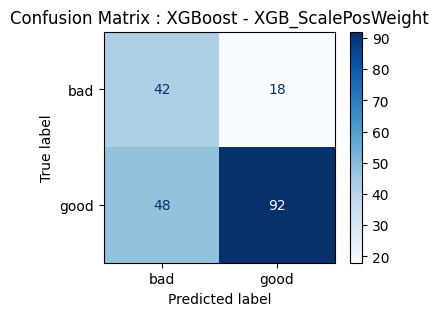


--- Classification Report for XGBoost - XGB_ScalePosWeight on Test Set ---
              precision    recall  f1-score   support

         bad       0.47      0.70      0.56        60
        good       0.84      0.66      0.74       140

    accuracy                           0.67       200
   macro avg       0.65      0.68      0.65       200
weighted avg       0.73      0.67      0.68       200


--- Key Metrics for XGBoost - XGB_ScalePosWeight on Test Set ---
  Accuracy: 0.6700
  F1-score (weighted): 0.6832
  F1-score (bad): 0.5600
  Precision (bad): 0.4667
  Recall (bad): 0.7000
----------------------------------------------------------

Estratto classificatore XGBoost dalla pipeline finale.

Visualizzazione Feature Importances dal modello XGBoost migliore:
Input 'model' trattato come classificatore diretto.


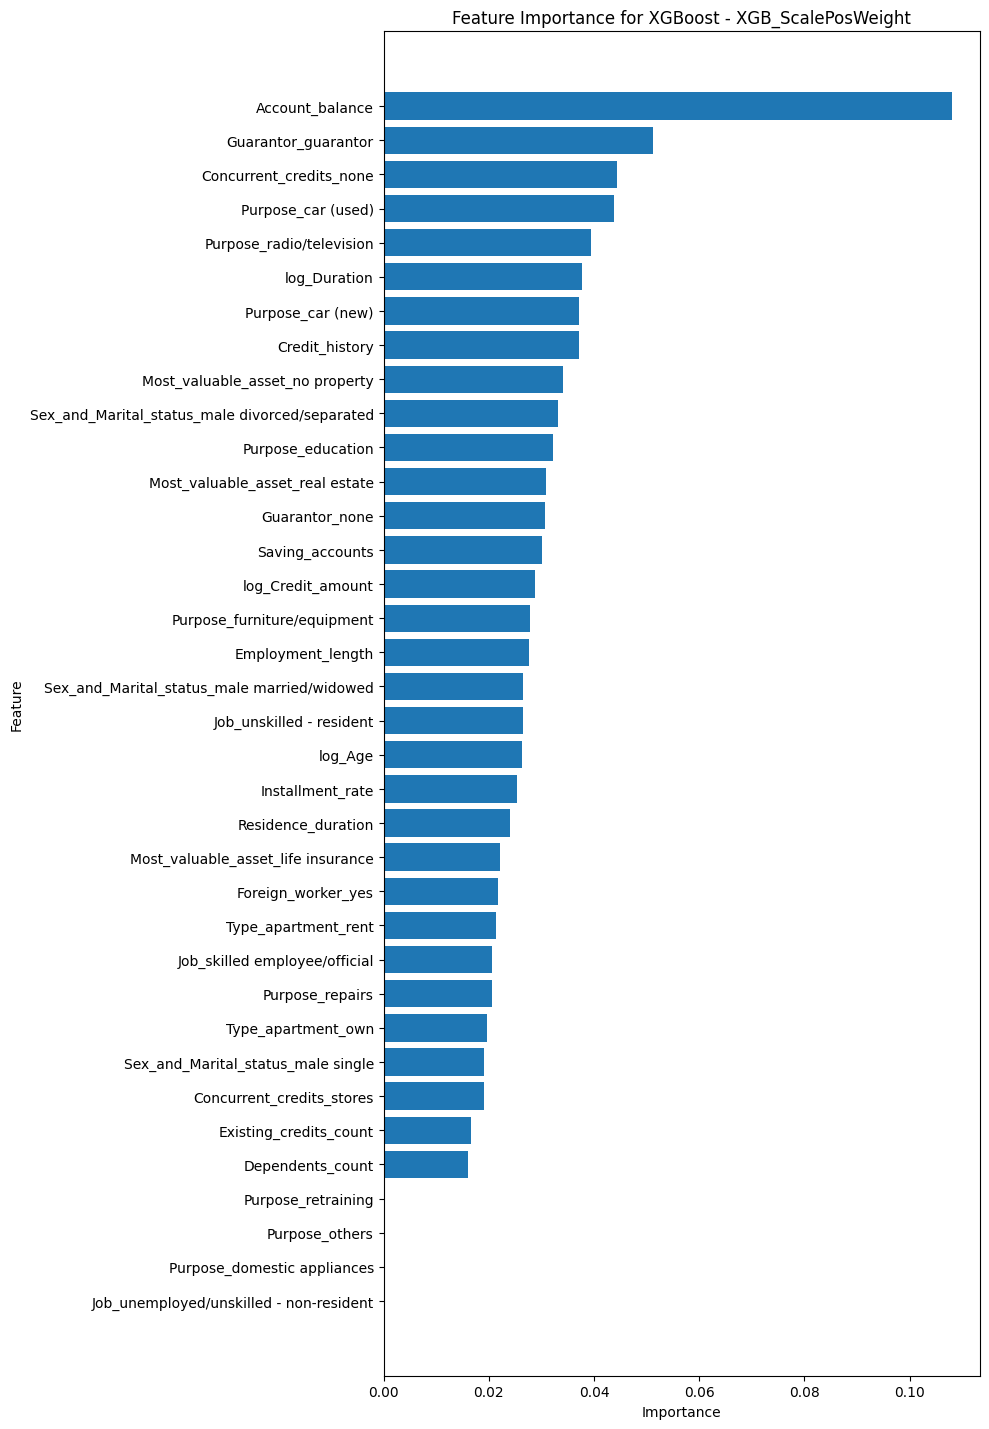

In [ ]:
# --- XGBoost (Standardizzato come Decision Tree / Logistic Regression) ---

RANDOM = 42
# Assicurati che f1_bad_scorer e best_cv_score_key siano definiti prima di questo blocco
# Esempio:
# f1_bad_scorer = make_scorer(f1_score, pos_label=bad_label_index, average='binary', zero_division=0)
# best_cv_score_key = 'best_f1_bad_cv' # F1 'bad' medio su cv

# Assumiamo che le seguenti variabili siano già definite:
# RANDOM, X_train_processed_df, y_train_encoded, X_test_processed_df, y_test_encoded
# cv, samplers, label_encoder
# f1_bad_scorer, best_cv_score_key # Definiti come sopra
# La funzione run_grid_search_cv
# Le funzioni evaluate_model, get_feature_importances, visualize_feature_importances
import xgboost as xgb # Assicurati che sia importato

# Parametri per XGBoost
xgb_param_grid = {
    'classifier__n_estimators': [150, 200],
    'classifier__learning_rate': [0.05, 0.1],
    'classifier__max_depth': [4, 5],
    'classifier__subsample': [0.8, 1.0],
    'classifier__colsample_bytree': [0.8, 1.0],
    'classifier__gamma': [0, 0.1]
}

# Esecuzione della grid search per ogni tecnica di resampling con XGBoost
xgb_results = {}
print("\n" + "="*30 + " XGBOOST (Ottimizzato per F1 'bad')" + "="*30)
for name, sampler in samplers.items():
    print(f"\n{'='*20} GridSearch XGB: {name} {'='*20}")
    xgb_classifier = xgb.XGBClassifier(objective='binary:logistic', eval_metric='logloss',
                                       random_state=RANDOM, use_label_encoder=False) # use_label_encoder=False è raccomandato

    # --- Usa run_grid_search_cv con f1_bad_scorer ---
    grid_result = run_grid_search_cv(
        model=xgb_classifier,
        sampler=sampler,
        param_grid=xgb_param_grid,
        X_train=X_train_processed_df,   # Usa DataFrame
        y_train=y_train_encoded,
        cv=cv,
        scoring_metric=f1_bad_scorer, # <-- MODIFICA: Usa f1_bad_scorer
        cv_score_key=best_cv_score_key  # <-- MODIFICA: Usa la chiave F1-bad
    )
    xgb_results[f"XGB_{name}"] = grid_result # Salva con prefisso
    # Non calcoliamo lo score sul test set qui

# --- Gestione separata per scale_pos_weight ---
print(f"\n{'='*20} GridSearch XGB: ScalePosWeight {'='*20}")
try:
    count_neg = sum(y_train_encoded == 0)
    count_pos = sum(y_train_encoded == 1)
    # Gestisci divisione per zero se count_pos == 0
    scale_pos_weight_value = 1 if count_pos == 0 else count_neg / count_pos
except NameError:
     print("ERRORE: y_train_encoded non definito, impossibile calcolare scale_pos_weight.")
     scale_pos_weight_value = 1 # Fallback

xgb_param_grid_scale_pos_weight = xgb_param_grid.copy()
xgb_param_grid_scale_pos_weight['classifier__scale_pos_weight'] = [scale_pos_weight_value]

xgb_classifier_spw = xgb.XGBClassifier(objective='binary:logistic', eval_metric='logloss',
                                       random_state=RANDOM, use_label_encoder=False)

# --- Usa run_grid_search_cv con f1_bad_scorer ---
grid_result_spw = run_grid_search_cv(
    model=xgb_classifier_spw,
    sampler=None,
    param_grid=xgb_param_grid_scale_pos_weight,
    X_train=X_train_processed_df,   # Usa DataFrame
    y_train=y_train_encoded,
    cv=cv,
    scoring_metric=f1_bad_scorer, # <-- MODIFICA: Usa f1_bad_scorer
    cv_score_key=best_cv_score_key  # <-- MODIFICA: Usa la chiave F1-bad
)
xgb_results['XGB_ScalePosWeight'] = grid_result_spw # Salva con prefisso
# Non calcoliamo lo score sul test set qui

# --- Esegui GridSearch per XGBoost SENZA Bilanciamento (Baseline) ---
print(f"\n{'='*20} GridSearch XGB: Baseline (No Balancing) {'='*20}")
xgb_classifier_nobalance = xgb.XGBClassifier(objective='binary:logistic', eval_metric='logloss',
                                             random_state=RANDOM, use_label_encoder=False)
grid_result_nobalance = run_grid_search_cv(
    model=xgb_classifier_nobalance,
    sampler=None,
    param_grid=xgb_param_grid, # Griglia originale senza scale_pos_weight
    X_train=X_train_processed_df, # Usa DataFrame
    y_train=y_train_encoded,
    cv=cv,
    scoring_metric=f1_bad_scorer, # <-- MODIFICA: Usa f1_bad_scorer
    cv_score_key=best_cv_score_key # <-- MODIFICA: Usa la chiave F1-bad
)
xgb_results['XGB_NoBalance'] = grid_result_nobalance # Salva con prefisso


# --- Confronto Globale e Valutazione Finale XGBoost ---

print(f"\n{'='*20} Confronto metodi e Valutazione Finale del Modello XGBoost {'='*20}")

# Stampa riepilogo risultati CV per ogni metodo testato
print("\nRiepilogo Risultati Cross-Validation (F1 Score 'bad'):")
xgb_results_summary = []
for name, result in xgb_results.items():
    if result and best_cv_score_key in result:
        score = result[best_cv_score_key]
        xgb_results_summary.append({'Metodo': name, best_cv_score_key: score})
    else:
        xgb_results_summary.append({'Metodo': name, best_cv_score_key: np.nan})

xgb_summary_cv_df = pd.DataFrame(xgb_results_summary).sort_values(best_cv_score_key, ascending=False)
display(xgb_summary_cv_df.round(4).fillna('Errore'))


# Trova la miglior configurazione COMPLESSIVA basata sul CV F1 score per 'bad'
xgb_best_overall_method_name = xgb_summary_cv_df.iloc[0]['Metodo'] # Il primo dopo l'ordinamento

# Gestisci caso in cui nessun risultato sia valido
if pd.isna(xgb_summary_cv_df.iloc[0][best_cv_score_key]):
     print("\nERRORE: Nessun risultato valido trovato da nessuna GridSearch per XGBoost.")
     best_xgb_pipeline_final = None # Imposta a None se non c'è modello valido
else:
    xgb_best_overall_result = xgb_results[xgb_best_overall_method_name]
    xgb_best_overall_cv_score = xgb_best_overall_result[best_cv_score_key]
    # Ottieni la pipeline completa (con sampler se presente) e i parametri OTTIMIZZATI
    best_xgb_pipeline_final = xgb_best_overall_result['best_model_estimator'] # <-- Variabile finale

    print(f"\n---> Miglior Metodo Complessivo per XGBoost (basato su CV F1 'bad'): {xgb_best_overall_method_name}")
    print(f"---> Miglior F1-score 'bad' (CV): {xgb_best_overall_cv_score:.4f}")
    print("Parametri Ottimali (all'interno della pipeline):")
    # Stampa i parametri specifici del classificatore trovati
    best_params_final = xgb_best_overall_result['best_params']
    for param, value in best_params_final.items():
         print(f"  {param}: {value}")

    # Esegui la valutazione finale SUL TEST SET usando la pipeline migliore
    print(f"\n--- Valutazione Finale del Modello Migliore ({xgb_best_overall_method_name}) sul Test Set ---")
    # Usa la funzione evaluate_model definita precedentemente
    final_f1_bad_test_xgb = evaluate_model( # Salva l'output F1-bad se ti serve
        model=best_xgb_pipeline_final,
        X_test=X_test_processed_df, # Usa DataFrame
        y_test=y_test_encoded,
        model_name=f"XGBoost - {xgb_best_overall_method_name}", # Nome descrittivo
        class_names=class_names,
        bad_label_index=bad_label_index
    )
    # print(f"\nF1 Score 'bad' finale sul Test Set per XGBoost: {final_f1_bad_test_xgb:.4f}")

     # --- Visualizzazioni per il Modello Finale Migliore ---
    feature_names_for_plot = X_train_processed_df.columns.tolist()

     # Estrai il classificatore effettivo dalla pipeline finale
    best_classifier_xgb_final = None
    if hasattr(best_xgb_pipeline_final, 'named_steps') and 'classifier' in best_xgb_pipeline_final.named_steps:
        best_classifier_xgb_final = best_xgb_pipeline_final.named_steps['classifier']
        print("\nEstratto classificatore XGBoost dalla pipeline finale.")
    elif isinstance(best_xgb_pipeline_final, xgb.XGBClassifier):
         best_classifier_xgb_final = best_xgb_pipeline_final # Se non è una pipeline
         print("\nUtilizzo l'estimator XGBoost diretto (non pipeline).")
    else:
         print(f"\nATTENZIONE: Impossibile estrarre un classificatore XGBoost valido dalla pipeline finale ({type(best_xgb_pipeline_final).__name__}).")


    # Visualizza Feature Importances (se il modello è XGBoost e ha feature_importances_)
    if best_classifier_xgb_final is not None and isinstance(best_classifier_xgb_final, xgb.XGBClassifier) and hasattr(best_classifier_xgb_final, 'feature_importances_'):
        print("\nVisualizzazione Feature Importances dal modello XGBoost migliore:")
        try:
            # Passa il classificatore estratto e i nomi corretti
            importances_xgb_df = get_feature_importances(best_classifier_xgb_final, feature_names_for_plot)
            visualize_feature_importances(importances_xgb_df, f"XGBoost - {xgb_best_overall_method_name}")
        except NameError:
            print("Funzioni 'get_feature_importances' o 'visualize_feature_importances' non trovate.")
        except Exception as e:
            print(f"Errore nella visualizzazione delle feature importance per XGBoost: {e}")

        # Visualizza un albero (opzionale) - Logica invariata, ma usa classifier finale
        # print("\nVisualizzazione di un albero di esempio dal modello XGBoost migliore:")
        # try:
        #    import matplotlib.pyplot as plt
            # Assicurati che xgb.plot_tree esista
        #    if hasattr(xgb, 'plot_tree'):
         #       fig, ax = plt.subplots(figsize=(30, 15))
         #       xgb.plot_tree(best_classifier_xgb_final, num_trees=0, ax=ax, rankdir='LR')
         #       plt.title(f"Primo albero del modello XGBoost ({xgb_best_overall_method_name})")
         #       plt.show()
          #  else:
           #     print("Funzione xgb.plot_tree non trovata.")
        #except Exception as e:
         #   print(f"Impossibile visualizzare l'albero XGBoost: {e}")

    elif best_classifier_xgb_final is not None:
         print(f"Il miglior classificatore finale ({type(best_classifier_xgb_final).__name__}) non è XGBoost o non ha 'feature_importances_'. Visualizzazione importanza non possibile.")

# else (corrispondente a if pd.isna(...)): gestito inizializzando best_xgb_pipeline_final a None
if best_xgb_pipeline_final is None:
    print("\nNessun risultato valido trovato per XGBoost dopo GridSearch.")

# 6 ROC Curve


Questa porzione di codice serve a visualizzare un confronto delle performance dei diversi modelli di classificazione trainati nei blocchi precedenti (impostando per ciascuno la propria configurazione migliore) utilizzando le *curve ROC* (Receiver Operating Characteristic) e i relativi punteggi *AUC* (Area Under the Curve).


Verifica modelli per grafico ROC:
  - OK: Dummy Classifier
  - OK: XGBoost
  - OK: Decision Tree
  - OK: Logistic Regression
  - OK: AdaBoost
  - OK: Random Forest
  - OK: SVM (RBF)

Classe positiva per ROC/AUC: 'bad' (indice 0)

Calcolo curve ROC e AUC...
INFO: Usando dati di tipo <class 'pandas.core.frame.DataFrame'> per predict_proba nel grafico ROC.
  - Elaborazione: Dummy Classifier
      AUC = 0.4643
  - Elaborazione: XGBoost
      AUC = 0.7569
  - Elaborazione: Decision Tree
      AUC = 0.6799
  - Elaborazione: Logistic Regression
      AUC = 0.7495
  - Elaborazione: AdaBoost
      AUC = 0.7487
  - Elaborazione: Random Forest
      AUC = 0.7789
  - Elaborazione: SVM (RBF)
      AUC = 0.7351


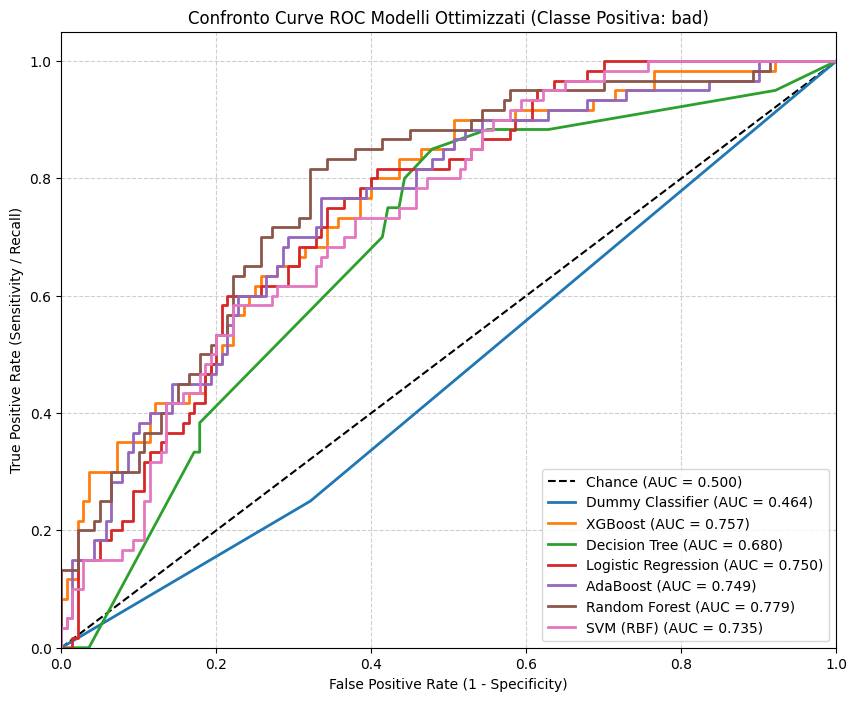


--- Riepilogo AUC (Area Under ROC Curve) ---
  Random Forest: 0.7789
  XGBoost: 0.7569
  Logistic Regression: 0.7495
  AdaBoost: 0.7487
  SVM (RBF): 0.7351
  Decision Tree: 0.6799
  Dummy Classifier: 0.4643


In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, RocCurveDisplay, confusion_matrix, ConfusionMatrixDisplay, classification_report, accuracy_score, f1_score, precision_score, recall_score # Assicurati che tutte le metriche siano importate
from sklearn.dummy import DummyClassifier
import numpy as np
from sklearn.svm import SVC

# --- Dummy Classifier ---
X_train_dummy_input = X_train_processed_df if 'X_train_processed_df' in locals() and X_train_processed_df is not None else X_train_processed

try:
    # Prova a recuperare un modello pre-esistente (se presente)
    dummy_model_base = models_dict_base['Dummy Classifier'] # Assumi che models_dict_base possa esistere
    if not hasattr(dummy_model_base, 'classes_'):
         print("Addestramento Dummy Classifier base (da models_dict_base)...")
         dummy_model_base.fit(X_train_dummy_input, y_train_encoded)
except (NameError, KeyError):
     # Se models_dict_base non esiste o non ha la chiave, crea e fitta un nuovo Dummy
     print("Attenzione: Creazione e addestramento Dummy Classifier di base.")
     dummy_model_base = DummyClassifier(strategy='stratified', random_state=RANDOM)
     try:
         dummy_model_base.fit(X_train_dummy_input, y_train_encoded)
     except Exception as e_dummy:
         print(f"ERRORE durante il fit del DummyClassifier: {e_dummy}")
         dummy_model_base = None # Imposta a None se fallisce

# --- Dizionario Modelli Migliori ---
best_trained_models = {
    "Dummy Classifier": dummy_model_base,
    "XGBoost": best_xgb_pipeline_final if 'best_xgb_pipeline_final' in locals() else None,
    "Decision Tree": best_dt_pipeline_final if 'best_dt_pipeline_final' in locals() else None,
    "Logistic Regression": best_lr_pipeline_final if 'best_lr_pipeline_final' in locals() else None,
    "AdaBoost": best_ada_pipeline_final if 'best_ada_pipeline_final' in locals() else None,
    "Random Forest": best_rf_pipeline_final if 'best_rf_pipeline_final' in locals() else None,
    "SVM (RBF)": best_svm_pipeline_final if 'best_svm_pipeline_final' in locals() else None,
    #"SVM (Linear)": best_svm_linear_pipeline_final if 'best_svm_linear_pipeline_final' in locals() else None,
}

# --- Filtro Modelli per ROC ---
valid_models_for_roc = {}
print("\nVerifica modelli per grafico ROC:")
for name, model in best_trained_models.items():
    if model is not None:
        # Controllo specifico per SVM senza probability=True
        is_svm_no_proba = False
        classifier_to_check = None
        # Estrai il classificatore effettivo (da pipeline o diretto)
        if hasattr(model, 'named_steps') and 'classifier' in model.named_steps:
            classifier_to_check = model.named_steps['classifier']
        elif hasattr(model, '_estimator_type') and model._estimator_type == "classifier": # Verifica se è un classificatore diretto
             classifier_to_check = model
        else: # Altrimenti, per sicurezza, usa il modello stesso se non classificabile sopra
             classifier_to_check = model

        # Controllo SVM
        if isinstance(classifier_to_check, SVC) and not getattr(classifier_to_check, 'probability', False):
             print(f"  - ATTENZIONE: Modello SVM '{name}' ha probability=False. Escluso da ROC.")
             continue # Salta questo modello SVM

        # Verifica generica per predict_proba sull'oggetto modello/pipeline originale
        if hasattr(model, 'predict_proba'):
              valid_models_for_roc[name] = model
              print(f"  - OK: {name}")
        else:
            print(f"  - ATTENZIONE: Modello '{name}' (o pipeline) non ha 'predict_proba'. Escluso da ROC.")
    else:
        print(f"  - ATTENZIONE: Modello '{name}' non trovato (None). Escluso da ROC.")


# --- PASSO 2: Identifica la Classe Positiva ---
positive_class_label = 'bad'
try:
    # Assumi che label_encoder sia disponibile
    positive_class_index = list(label_encoder.classes_).index(positive_class_label)
    print(f"\nClasse positiva per ROC/AUC: '{positive_class_label}' (indice {positive_class_index})")
except (NameError, ValueError) as e:
    print(f"ERRORE CRITICO: Impossibile determinare l'indice della classe positiva ('{positive_class_label}'). Errore: {e}")
    raise SystemExit("Errore configurazione ROC.")
except Exception as e:
     print(f"ERRORE CRITICO imprevisto: {e}")
     raise SystemExit("Errore configurazione ROC.")


# --- PASSI 3, 4 & 5: Calcola Probabilità, ROC/AUC e Disegna ---
if not valid_models_for_roc:
    print("\nNessun modello valido trovato per generare il grafico ROC.")
else:
    plt.figure(figsize=(10, 8))
    ax = plt.gca()
    plt.plot([0, 1], [0, 1], 'k--', label='Chance (AUC = 0.500)') # Linea casuale

    model_auc_scores = {}
    print("\nCalcolo curve ROC e AUC...")

    X_test_roc_input = X_test_processed_df if 'X_test_processed_df' in locals() and X_test_processed_df is not None else X_test_processed
    print(f"INFO: Usando dati di tipo {type(X_test_roc_input)} per predict_proba nel grafico ROC.")

    for name, model in valid_models_for_roc.items():
        print(f"  - Elaborazione: {name}")
        try:
            # Ottieni le probabilità per la classe positiva
            # Usa X_test_roc_input
            y_pred_proba = model.predict_proba(X_test_roc_input)[:, positive_class_index]

            # Calcola FPR, TPR
            fpr, tpr, thresholds = roc_curve(y_test_encoded, y_pred_proba, pos_label=positive_class_index)

            # Calcola AUC
            roc_auc = auc(fpr, tpr)
            model_auc_scores[name] = roc_auc
            print(f"      AUC = {roc_auc:.4f}")

            # Disegna la curva ROC
            plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {roc_auc:.3f})')

        except IndexError:
            print(f"    ERRORE (Indice) durante calcolo ROC per {name}: problema nel recuperare probabilità per classe {positive_class_index}.")
        except Exception as e:
            print(f"    ERRORE durante il calcolo ROC per {name}: {e}")
            print(f"    Verifica che il modello sia correttamente addestrato e i dati test siano nel formato corretto ({type(X_test_roc_input)}).")

    # Personalizza il grafico
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate (1 - Specificity)')
    plt.ylabel('True Positive Rate (Sensitivity / Recall)')
    plt.title(f'Confronto Curve ROC Modelli Ottimizzati (Classe Positiva: {positive_class_label})')
    plt.legend(loc="lower right")
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

    # Stampa riepilogo AUC ordinato
    print("\n--- Riepilogo AUC (Area Under ROC Curve) ---")
    if model_auc_scores:
        sorted_auc = sorted(model_auc_scores.items(), key=lambda item: item[1], reverse=True)
        for name, score in sorted_auc:
            print(f"  {name}: {score:.4f}")
    else:
        print("  Nessun punteggio AUC calcolato.")

Dalla seguente analisi risulta come Random Forest sia il modello maggiormente performante, seppur anche gli altri abbiano raggiunto buoni livelli.

Rispetto alla valutazione effettuata nel capitolo 4.1 qui si può apprezzare quanto il lavoro dedicato all'ottimizzazione degli iperparametri abbia portato ad un miglioramente delle performance per ciascun modello.

# 7 Riduzione feature

Questa sezione del codice esegue una selezione delle feature più importanti per ogni modello e verifica come esso si comporta utilizzando solo un numero limitato di feature.

Per ciascuno dei modelli presi con le configuarazioni migliori di iperparametri:
*   Estrae l'algoritmo base
*   Esegue SFS usando quell'algoritmo specifico per trovare le k feature migliori
*   Ri-addestra una nuova istanza di quell'algoritmo solo sulle k feature selezionate
*   Valuta questo nuovo modello "ridotto" sul set di test
*   Salva le feature selezionate, i modelli ridotti e le loro performance.

Al termine di queste operazione viene generato un grafico ROC che confronta le performance dei modelli originali con quelle dei modelli ri-addestrati usando solo le feature selezionate da SFS.


 INIZIO ANALISI CON SEQUENTIAL FEATURE SELECTOR (SFS)
INFO: 'X_train_processed' è già un DataFrame.
INFO: Dati pronti per SFS. Numero feature totali: 36
INFO: Shape X_train per SFS: (800, 36)
INFO: SFS userà scoring='f1_score' (basato su f1_bad_scorer) e la strategia CV esistente (StratifiedKFold(n_splits=5, random_state=42, shuffle=True)).

INFO: Recupero/Ricalcolo score baseline sul test set...
INFO: Usando positive_class_index = 0 per AUC.
  - Dummy Classifier: Baseline F1=0.5500, AUC=0.5357
  - XGBoost: Baseline F1=0.6832, AUC=0.2431
  - Decision Tree: Baseline F1=0.6358, AUC=0.3201
  - Logistic Regression: Baseline F1=0.6741, AUC=0.2505
  - AdaBoost: Baseline F1=0.7086, AUC=0.2513
  - Random Forest: Baseline F1=0.7221, AUC=0.2211
  - SVM (RBF): Baseline F1=0.6644, AUC=0.2649

============================== ESECUZIONE SFS (k=4) ==============================

--- Processando SFS per: Dummy Classifier ---
  INFO: Estratto estimator 'DummyClassifier' dalla pipeline.
  INFO: Creato c

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done  36 out of  36 | elapsed:    0.5s finished
Features: 1/4[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done  35 out of  35 | elapsed:    0.4s finished
Features: 2/4[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done  34 out of  34 | elapsed:    0.4s finished
Features: 3/4[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done  33 out of  33 | elapsed:    0.4s finished
Features: 4/4[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.



  INFO: SFS completato.
  Feature selezionate (4): ['log_Duration', 'log_Credit_amount', 'log_Age', 'Installment_rate']
  Score CV interno SFS (make_scorer(f1_score, response_method='predict', pos_label=0, average=binary, zero_division=0)): 0.2887
  INFO: Creati dataset ridotti (Train: (800, 4), Test: (200, 4))
  INFO: Ri-addestramento modello finale 'Dummy Classifier'...
  INFO: Valutazione SFS completata. Test F1=0.5500, Test AUC=0.5357
  Tempo SFS + Retraining per Dummy Classifier: 1.80 secondi

--- Processando SFS per: XGBoost ---
  INFO: Estratto estimator 'XGBClassifier' dalla pipeline.
  INFO: Creato clone 'XGBClassifier' per SFS.
  INFO: Avvio fitting SFS...


[Parallel(n_jobs=-1)]: Done  36 out of  36 | elapsed:    3.3s finished
Features: 1/4[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done  35 out of  35 | elapsed:    4.8s finished
Features: 2/4[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done  34 out of  34 | elapsed:    4.0s finished
Features: 3/4[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done  33 out of  33 | elapsed:    3.9s finished
Features: 4/4[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.



  INFO: SFS completato.
  Feature selezionate (4): ['Account_balance', 'Purpose_domestic appliances', 'Most_valuable_asset_real estate', 'Foreign_worker_yes']
  Score CV interno SFS (make_scorer(f1_score, response_method='predict', pos_label=0, average=binary, zero_division=0)): 0.5938
  INFO: Creati dataset ridotti (Train: (800, 4), Test: (200, 4))
  INFO: Ri-addestramento modello finale 'XGBoost'...
  ATTENZIONE: Warning durante fit finale SFS per XGBoost:
    - UserWarning: [07:44:26] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  INFO: Valutazione SFS completata. Test F1=0.6786, Test AUC=0.2423
  Tempo SFS + Retraining per XGBoost: 16.09 secondi

--- Processando SFS per: Decision Tree ---
  INFO: Estratto estimator 'DecisionTreeClassifier' dalla pipeline.
  INFO: Creato clone 'DecisionTreeClassifier' per SFS.
  INFO: Avvio fitting SFS...


...


  INFO: SFS completato.
  Feature selezionate (4): ['Account_balance', 'Credit_history', 'Saving_accounts', 'Guarantor_guarantor']
  Score CV interno SFS (make_scorer(f1_score, response_method='predict', pos_label=0, average=binary, zero_division=0)): 0.4942
  INFO: Creati dataset ridotti (Train: (800, 4), Test: (200, 4))
  INFO: Ri-addestramento modello finale 'AdaBoost'...
  INFO: Valutazione SFS completata. Test F1=0.7185, Test AUC=0.2463
  Tempo SFS + Retraining per AdaBoost: 312.18 secondi

--- Processando SFS per: Random Forest ---
  INFO: Estratto estimator 'RandomForestClassifier' dalla pipeline.
  INFO: Creato clone 'RandomForestClassifier' per SFS.
  INFO: Avvio fitting SFS...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done  36 out of  36 | elapsed:   26.9s finished
Features: 1/4[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done  35 out of  35 | elapsed:   31.3s finished
Features: 2/4[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done  34 out of  34 | elapsed:   28.1s finished
Features: 3/4[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done  33 out of  33 | elapsed:   27.7s finished
Features: 4/4


  INFO: SFS completato.
  Feature selezionate (4): ['log_Duration', 'log_Credit_amount', 'Account_balance', 'Credit_history']
  Score CV interno SFS (make_scorer(f1_score, response_method='predict', pos_label=0, average=binary, zero_division=0)): 0.5003
  INFO: Creati dataset ridotti (Train: (800, 4), Test: (200, 4))
  INFO: Ri-addestramento modello finale 'Random Forest'...
  INFO: Valutazione SFS completata. Test F1=0.7619, Test AUC=0.2323
  Tempo SFS + Retraining per Random Forest: 114.26 secondi

--- Processando SFS per: SVM (RBF) ---
  INFO: Estratto estimator 'SVC' dalla pipeline.
  INFO: Creato clone 'SVC' per SFS.
  INFO: Avvio fitting SFS...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done  36 out of  36 | elapsed:   12.1s finished
Features: 1/4[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done  35 out of  35 | elapsed:   11.9s finished
Features: 2/4[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done  34 out of  34 | elapsed:   11.8s finished
Features: 3/4[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done  33 out of  33 | elapsed:   11.2s finished
Features: 4/4


  INFO: SFS completato.
  Feature selezionate (4): ['log_Duration', 'Account_balance', 'Guarantor_guarantor', 'Job_unemployed/unskilled - non-resident']
  Score CV interno SFS (make_scorer(f1_score, response_method='predict', pos_label=0, average=binary, zero_division=0)): 0.5919
  INFO: Creati dataset ridotti (Train: (800, 4), Test: (200, 4))
  INFO: Ri-addestramento modello finale 'SVM (RBF)'...
  INFO: Valutazione SFS completata. Test F1=0.6181, Test AUC=0.3183
  Tempo SFS + Retraining per SVM (RBF): 47.13 secondi

 CONFRONTO PERFORMANCE TEST SET: BASELINE vs SFS (k=4)
Modello              | Metric       | Baseline   | SFS        | Differenza   | Features / Stato SFS
---------------------------------------------------------------------------------------------------
Nota: 'nan' indica score non calcolato (es. AUC non disponibile o errore). '+' indica miglioramento SFS.
AdaBoost             | F1 Weighted  | 0.7086     | 0.7185     | +0.0099      | Account_balance, Credit_history, Sav

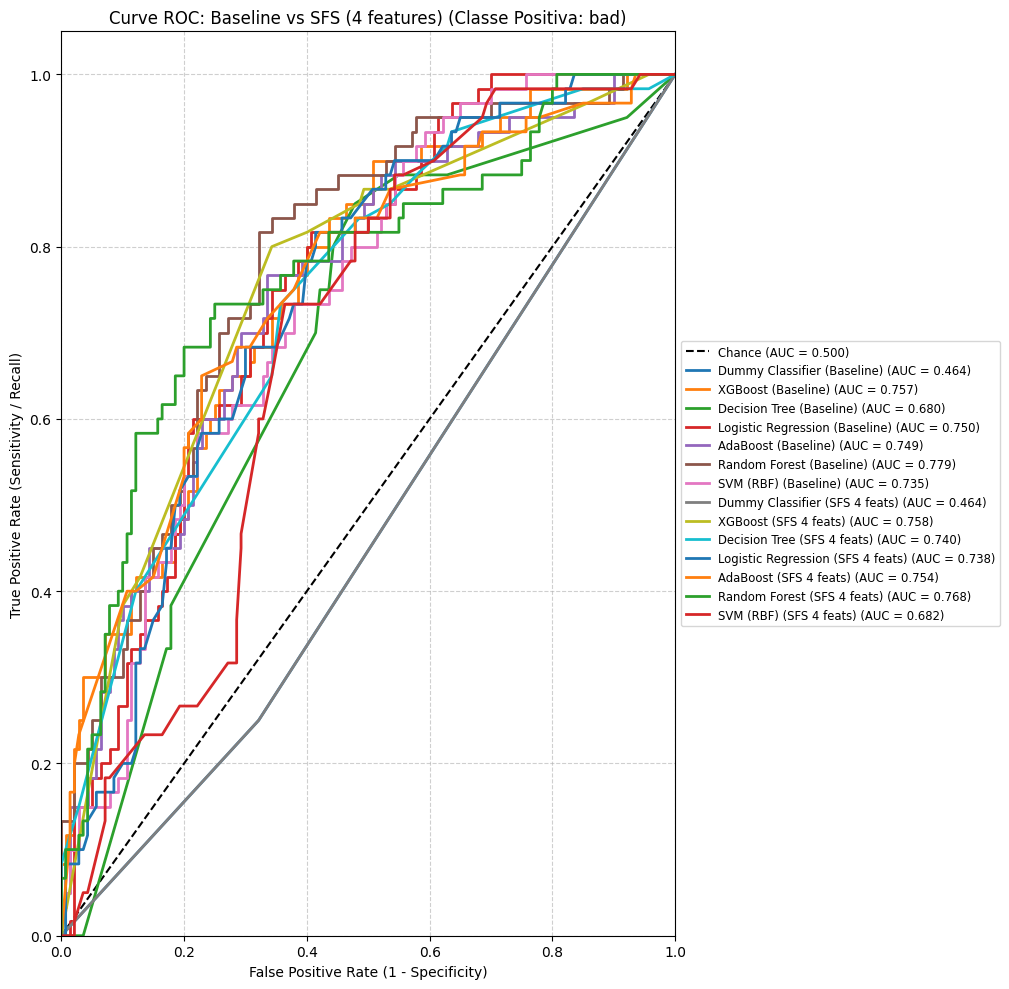


--- Riepilogo AUC Finale (Ordinato, modelli plottati) ---
  Random Forest (Baseline)                     : 0.7789
  Random Forest (SFS 4 feats)                  : 0.7677
  XGBoost (SFS 4 feats)                        : 0.7577
  XGBoost (Baseline)                           : 0.7569
  AdaBoost (SFS 4 feats)                       : 0.7537
  Logistic Regression (Baseline)               : 0.7495
  AdaBoost (Baseline)                          : 0.7487
  Decision Tree (SFS 4 feats)                  : 0.7396
  Logistic Regression (SFS 4 feats)            : 0.7377
  SVM (RBF) (Baseline)                         : 0.7351
  SVM (RBF) (SFS 4 feats)                      : 0.6817
  Decision Tree (Baseline)                     : 0.6799
  Dummy Classifier (Baseline)                  : 0.4643
  Dummy Classifier (SFS 4 feats)               : 0.4643

 FINE ANALISI SFS 


In [ ]:
# ------------- SEQUENTIAL FEATURE SELECTOR (SFS) -------------

import pandas as pd
from mlxtend.feature_selection import SequentialFeatureSelector as SFS
from sklearn.base import clone, is_classifier
from sklearn.metrics import f1_score, roc_auc_score, roc_curve, auc
import matplotlib.pyplot as plt
import time
import numpy as np
from sklearn.model_selection import StratifiedKFold
import warnings

print("\n" + "="*40)
print(" INIZIO ANALISI CON SEQUENTIAL FEATURE SELECTOR (SFS)")
print("="*40)

# --- 1. Verifica e Preparazione Dati per SFS ---
feature_names = None
X_train_sfs_df = None
X_test_sfs_df = None

try:
    # Controlla se X_train_processed esiste
    if 'X_train_processed' not in locals() or 'X_test_processed' not in locals():
        raise NameError("Variabili 'X_train_processed' o 'X_test_processed' non trovate.")

    if isinstance(X_train_processed_df, pd.DataFrame):
        print("INFO: 'X_train_processed' è già un DataFrame.")
        feature_names = X_train_processed_df.columns.tolist()
        X_train_sfs_df = X_train_processed_df.copy()
        X_test_sfs_df = X_test_processed_df.copy() # Assumi che X_test_processed sia compatibile
    elif hasattr(X_train_processed_df, 'shape'):
        print("INFO: 'X_train_processed' è un array NumPy. Tentativo recupero nomi feature...")
        num_features = X_train_processed_df.shape[1]

        # Tentativo prioritario di recupero nomi da preprocessor comune
        preprocessor_found = None
        common_preprocessor_names = ['preprocessor', 'col_transformer', 'column_transformer', 'ct']
        for pp_name in common_preprocessor_names:
            if pp_name in locals() and hasattr(locals()[pp_name], 'get_feature_names_out'):
                try:
                    feature_names = locals()[pp_name].get_feature_names_out()
                    # Verifica coerenza numero feature
                    if len(feature_names) == num_features:
                        print(f"INFO: Nomi feature recuperati da '{pp_name}.get_feature_names_out()'.")
                        preprocessor_found = True
                        break
                    else:
                         print(f"ATTENZIONE: Numero nomi da '{pp_name}' ({len(feature_names)}) non corrisponde a shape dati ({num_features}). Ignoro.")
                         feature_names = None # Resetta se le dimensioni non combaciano
                except Exception as e_gn:
                    print(f"ATTENZIONE: Errore nel chiamare get_feature_names_out su '{pp_name}': {e_gn}. Ignoro.")
                    feature_names = None # Resetta in caso di errore

        # Tentativo secondario: usare nomi da X_train originale (se esiste e dimensioni combaciano)
        if not preprocessor_found and 'X_train' in locals() and isinstance(X_train, pd.DataFrame):
             if X_train.shape[1] == num_features:
                 feature_names = X_train.columns.tolist()
                 print("INFO: Usati nomi feature da DataFrame 'X_train' originale (dimensioni corrispondenti).")
             else:
                 print(f"ATTENZIONE: Dimensioni 'X_train' ({X_train.shape[1]}) non corrispondono a 'X_train_processed' ({num_features}). Impossibile usare nomi originali.")

        # Ultima risorsa: nomi generici
        if feature_names is None:
             print("ATTENZIONE: Nomi feature non recuperati. Genero nomi default ('feat_0', 'feat_1', ...).")
             feature_names = [f'feat_{i}' for i in range(num_features)]

        # Crea i DataFrame
        X_train_sfs_df = pd.DataFrame(X_train_processed_df, columns=feature_names)
        X_test_sfs_df = pd.DataFrame(X_test_processed_df, columns=feature_names)

    else:
        # Se non è DataFrame né array NumPy riconoscibile
        raise TypeError("X_train_processed non è né un DataFrame né un array NumPy riconoscibile.")

    # Controllo finale
    if X_train_sfs_df is None or X_test_sfs_df is None:
         raise ValueError("Creazione DataFrame X_train_sfs_df o X_test_sfs_df fallita.")

    print(f"INFO: Dati pronti per SFS. Numero feature totali: {len(feature_names)}")
    print(f"INFO: Shape X_train per SFS: {X_train_sfs_df.shape}")

except (NameError, TypeError, ValueError) as e:
    print(f"ERRORE CRITICO nella preparazione dati SFS: {e}")
    print("Impossibile procedere con l'analisi SFS.")
    # Interrompi l'esecuzione della cella o dello script se preferisci
    raise SystemExit("Errore dati critico per SFS.")
except Exception as e:
    print(f"ERRORE CRITICO imprevisto nella preparazione dati SFS: {e}")
    raise SystemExit("Errore dati critico per SFS.")

# --- 2. Definizione Parametri SFS ---
k_features_to_select = 4  # <--- IMPOSTA QUI il numero di feature desiderato

# Recupera cv dallo scope precedente, o definisci default
sfs_cv_strategy = None
try:
    if 'cv' in locals(): # Assumi che cv sia un oggetto CV valido o un intero
         sfs_cv_strategy = cv
    else:
        print("ATTENZIONE: 'cv' non trovata nello scope. Uso default StratifiedKFold(n_splits=5) per SFS.")
        sfs_cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM)

    # Assicurati che f1_bad_scorer sia definito prima di questa cella
    if 'f1_bad_scorer' in locals():
        sfs_scoring_metric = f1_bad_scorer
        # Ottieni il nome della metrica per la stampa (un po' più complesso per scorer custom)
        scorer_name = getattr(f1_bad_scorer, '_score_func', {}).__name__ if hasattr(f1_bad_scorer,'_score_func') else 'custom_scorer (f1_bad)'
        print(f"INFO: SFS userà scoring='{scorer_name}' (basato su f1_bad_scorer) e la strategia CV esistente ({sfs_cv_strategy}).")
    else:
        print("ERRORE CRITICO: 'f1_bad_scorer' non trovato. Impossibile ottimizzare SFS per F1 'bad'.")
        raise NameError("Variabile 'f1_bad_scorer' non definita. Impossibile procedere con SFS standardizzato.")

except NameError:
     print("ERRORE: 'RANDOM' non definito. Imposta una seed o definisci 'cv' manualmente.")
     raise SystemExit("Errore configurazione CV per SFS.")
except Exception as e:
     print(f"ERRORE nella configurazione dei parametri SFS: {e}")
     raise SystemExit("Errore configurazione SFS.")


# --- 3. Recupero Score Baseline (con Gestione Errori Migliorata) ---
print("\nINFO: Recupero/Ricalcolo score baseline sul test set...")
baseline_test_scores = {}

# MODIFICA: Controllo esplicito per positive_class_index all'inizio
if 'positive_class_index' not in locals() or not isinstance(positive_class_index, int):
     print("ERRORE CRITICO: 'positive_class_index' non definito o non è un intero.")
     print("Questo è necessario per calcolare l'AUC. Esegui la cella ROC precedente.")
     raise SystemExit("Errore configurazione AUC.")
else:
    print(f"INFO: Usando positive_class_index = {positive_class_index} per AUC.")

# MODIFICA: Assicurati che y_test_encoded esista
if 'y_test_encoded' not in locals():
    print("ERRORE CRITICO: 'y_test_encoded' non trovato. Impossibile calcolare score.")
    raise SystemExit("Errore dati target.")

for name, model in best_trained_models.items():
    baseline_test_scores[name] = {'f1_weighted': np.nan, 'auc': np.nan} # Inizializza a NaN
    if model:
        try:
            # Calcola F1 Weighted
            y_pred_base = model.predict(X_test_sfs_df)
            f1_base = f1_score(y_test_encoded, y_pred_base, average='weighted')
            baseline_test_scores[name]['f1_weighted'] = f1_base

            # Calcola AUC solo se possibile
            auc_base = np.nan
            can_predict_proba = hasattr(model, 'predict_proba')
            # Gestione specifica SVM
            classifier_to_check = model.named_steps.get('classifier', model) if hasattr(model, 'named_steps') else model
            if isinstance(classifier_to_check, SVC) and not getattr(classifier_to_check, 'probability', False):
                can_predict_proba = False
                print(f"  - INFO ({name}): Modello SVM senza probability=True, AUC non calcolabile.")

            if can_predict_proba:
                 try:
                     y_proba_base = model.predict_proba(X_test_sfs_df)[:, positive_class_index]
                     auc_base = roc_auc_score(y_test_encoded, y_proba_base)
                     baseline_test_scores[name]['auc'] = auc_base
                 except IndexError:
                     print(f"  - ATTENZIONE ({name}): Errore indice nel recuperare probabilità per classe {positive_class_index}. AUC=nan.")
                 except Exception as e_proba_auc:
                     print(f"  - ATTENZIONE ({name}): Errore nel calcolo predict_proba/AUC baseline: {e_proba_auc}. AUC=nan.")
            # Stampa gli score ottenuti (o NaN)
            print(f"  - {name}: Baseline F1={baseline_test_scores[name]['f1_weighted']:.4f}, AUC={baseline_test_scores[name]['auc']:.4f}")

        except Exception as e_pred:
            # Errore generico durante predict/f1_score
            print(f"  - ERRORE nel valutare baseline {name}: {e_pred}. Score impostati a NaN.")
            # baseline_test_scores[name] è già NaN di default
    else:
        print(f"  - {name}: Modello baseline non disponibile (None).")
        # baseline_test_scores[name] è già NaN di default


# --- 4. Esecuzione SFS e Retraining (con Gestione Errori Rafforzata) ---
sfs_results = {} # Per statistiche e score SFS
sfs_trained_models = {} # Per i modelli finali addestrati con SFS

print("\n" + "="*30 + f" ESECUZIONE SFS (k={k_features_to_select}) " + "="*30)

# Controllo esistenza y_train_encoded
if 'y_train_encoded' not in locals():
    print("ERRORE CRITICO: 'y_train_encoded' non trovato. Impossibile eseguire SFS.")
    raise SystemExit("Errore dati target per SFS.")


for model_name, fitted_model_or_pipeline in best_trained_models.items():
    start_time = time.time()
    print(f"\n--- Processando SFS per: {model_name} ---")
    # Inizializza risultati per questo modello (utile se fallisce presto)
    sfs_results[model_name] = {
            'sfs_cv_score': np.nan, 'selected_features': [], 'k_features': 0,
            'test_f1_weighted': np.nan, 'test_auc': np.nan, 'error': None
    }
    sfs_trained_models[model_name] = None

    if fitted_model_or_pipeline is None:
        print(f"  INFO: Modello '{model_name}' è None. Salto SFS.")
        sfs_results[model_name]['error'] = "Modello base è None"
        continue

    # 4.a Estrarre l'estimator di base (con parametri ottimali)
    estimator_base = None
    try:
        if hasattr(fitted_model_or_pipeline, 'named_steps') and 'classifier' in fitted_model_or_pipeline.named_steps:
            estimator_base = fitted_model_or_pipeline.named_steps['classifier']
            # MODIFICA: Verifica che sia un classificatore sklearn
            if not is_classifier(estimator_base):
                 raise TypeError(f"Lo step 'classifier' non è un classificatore Sklearn valido ({type(estimator_base).__name__})")
            print(f"  INFO: Estratto estimator '{type(estimator_base).__name__}' dalla pipeline.")
        elif is_classifier(fitted_model_or_pipeline): # Modello diretto che sia classificatore
            estimator_base = fitted_model_or_pipeline
            print(f"  INFO: Usato modello diretto '{type(estimator_base).__name__}'.")
        else:
            raise TypeError("L'oggetto fornito non è né una pipeline con step 'classifier' né un classificatore Sklearn valido.")
    except Exception as e:
        print(f"  ERRORE nell'estrarre estimator valido per {model_name}: {e}. Salto SFS.")
        sfs_results[model_name]['error'] = f"Errore estrazione estimator: {e}"
        continue

    # 4.b Clonare l'estimator base per SFS (versione pulita, non fittata)
    try:
        estimator_for_sfs = clone(estimator_base)
        # Rimuovi attributi di fitting (più robusto che semplice delattr)
        if hasattr(estimator_for_sfs, 'fit'):
             # Reset forzato se clone non basta (dipende dall'estimator)
             pass # In genere clone è sufficiente, ma tieni d'occhio se vedi fitting residuo
        print(f"  INFO: Creato clone '{type(estimator_for_sfs).__name__}' per SFS.")
    except Exception as e:
         print(f"  ERRORE nel clonare estimator per SFS: {e}. Salto {model_name}.")
         sfs_results[model_name]['error'] = f"Errore clonazione estimator: {e}"
         continue

    # 4.c Configurare ed Eseguire SFS
    sfs = SFS(estimator=estimator_for_sfs,
              k_features=k_features_to_select,
              forward=True,
              floating=False,
              scoring=sfs_scoring_metric,
              cv=sfs_cv_strategy,
              n_jobs=-1,
              verbose=1)

    selected_feature_names = [] # Inizializza
    try:
        print(f"  INFO: Avvio fitting SFS...")
        # MODIFICA: Gestione warning specifici durante SFS fit
        with warnings.catch_warnings(record=True) as caught_warnings:
            warnings.simplefilter("always") # Cattura tutti i warning
            sfs.fit(X_train_sfs_df, y_train_encoded)

            # Stampa i warning catturati (opzionale, ma informativo)
            if caught_warnings:
                 print(f"  ATTENZIONE: Warning durante SFS fit per {model_name}:")
                 for w in caught_warnings:
                     print(f"    - {w.category.__name__}: {w.message}")

    except Exception as e:
        print(f"\n  ERRORE CRITICO durante il fitting di SFS per {model_name}: {e}")
        print(f"  Possibili cause: metrica '{sfs_scoring_metric}' non valida, problemi CV, memoria, incompatibilità dati/modello.")
        sfs_results[model_name]['error'] = f"Errore SFS fit: {e}"
        continue # Passa al prossimo modello

    # 4.d Ottenere Risultati SFS (solo se fit ha successo)
    selected_feature_names = list(sfs.k_feature_names_)
    sfs_internal_cv_score = sfs.k_score_
    sfs_results[model_name]['sfs_cv_score'] = sfs_internal_cv_score
    sfs_results[model_name]['selected_features'] = selected_feature_names
    sfs_results[model_name]['k_features'] = len(selected_feature_names)
    print(f"\n  INFO: SFS completato.")
    print(f"  Feature selezionate ({len(selected_feature_names)}): {selected_feature_names}")
    print(f"  Score CV interno SFS ({sfs_scoring_metric}): {sfs_internal_cv_score:.4f}")

    # Verifica se sono state selezionate feature
    if not selected_feature_names:
         print(f"  ATTENZIONE: SFS per {model_name} non ha selezionato feature. Impossibile riaddestrare.")
         sfs_results[model_name]['error'] = "SFS non ha selezionato feature"
         continue

    # 4.e Creare Dataset Ridotti
    try:
        X_train_reduced = X_train_sfs_df[selected_feature_names]
        X_test_reduced = X_test_sfs_df[selected_feature_names]
        print(f"  INFO: Creati dataset ridotti (Train: {X_train_reduced.shape}, Test: {X_test_reduced.shape})")
    except KeyError as e_key:
        print(f"  ERRORE CRITICO nella creazione dataset ridotti (feature non trovata?): {e_key}. Salto retraining.")
        sfs_results[model_name]['error'] = f"Errore creazione dataset ridotti: {e_key}"
        continue
    except Exception as e_data:
         print(f"  ERRORE CRITICO imprevisto nella creazione dataset ridotti: {e_data}. Salto retraining.")
         sfs_results[model_name]['error'] = f"Errore imprevisto creazione dataset ridotti: {e_data}"
         continue

    # 4.f Ri-Addestrare il Modello Finale su Feature Selezionate
    print(f"  INFO: Ri-addestramento modello finale '{model_name}'...")
    final_sfs_model = clone(estimator_base) # Usa un NUOVO clone pulito

    try:
        # MODIFICA: Cattura warning anche nel fit finale
        with warnings.catch_warnings(record=True) as caught_warnings_fit:
             warnings.simplefilter("always")
             final_sfs_model.fit(X_train_reduced, y_train_encoded)
             if caught_warnings_fit:
                  print(f"  ATTENZIONE: Warning durante fit finale SFS per {model_name}:")
                  for w in caught_warnings_fit:
                      print(f"    - {w.category.__name__}: {w.message}")

        sfs_trained_models[model_name] = final_sfs_model # Salva il modello addestrato

        # 4.g Valutare il Modello SFS sul Test Set Ridotto
        y_pred_sfs = final_sfs_model.predict(X_test_reduced)
        f1_sfs = f1_score(y_test_encoded, y_pred_sfs, average='weighted')
        sfs_results[model_name]['test_f1_weighted'] = f1_sfs

        # Calcola AUC SFS solo se possibile
        auc_sfs = np.nan
        can_predict_proba_sfs = hasattr(final_sfs_model, 'predict_proba')
        if isinstance(final_sfs_model, SVC) and not getattr(final_sfs_model, 'probability', False):
            can_predict_proba_sfs = False
            print(f"  - INFO (SFS {model_name}): Modello SVM senza probability=True, AUC SFS non calcolabile.")

        if can_predict_proba_sfs:
            try:
                y_proba_sfs = final_sfs_model.predict_proba(X_test_reduced)[:, positive_class_index]
                auc_sfs = roc_auc_score(y_test_encoded, y_proba_sfs)
                sfs_results[model_name]['test_auc'] = auc_sfs
            except IndexError:
                print(f"    ATTENZIONE (SFS {model_name}): Errore indice nel recuperare probabilità per classe {positive_class_index}. AUC SFS=nan.")
            except Exception as e_auc_sfs:
                print(f"    ATTENZIONE (SFS {model_name}): Errore nel calcolo predict_proba/AUC SFS: {e_auc_sfs}. AUC SFS=nan.")

        print(f"  INFO: Valutazione SFS completata. Test F1={f1_sfs:.4f}, Test AUC={auc_sfs:.4f}")
        sfs_results[model_name]['error'] = None # Resetta errore se tutto ok alla fine

    except Exception as e:
        # Errore durante fit finale o valutazione finale
        print(f"\n  ERRORE durante ri-addestramento/valutazione SFS per {model_name}: {e}")
        sfs_results[model_name]['error'] = f"Errore retraining/valutazione SFS: {e}"
        # Non sovrascrivere sfs_trained_models[model_name], resta None

    end_time = time.time()
    print(f"  Tempo SFS + Retraining per {model_name}: {end_time - start_time:.2f} secondi")


# --- 5. Tabella Riassuntiva di Confronto Performance (Migliorata) ---
print("\n" + "="*50)
print(f" CONFRONTO PERFORMANCE TEST SET: BASELINE vs SFS (k={k_features_to_select})")
print("="*50)
# MODIFICA: Header dinamico e nota su NaN
base_header = f"{'Modello':<20} | {'Metric':<12} | {'Baseline':<10} | {'SFS':<10} | {'Differenza':<12} | {'Features / Stato SFS'}"
print(base_header)
print("-" * len(base_header))
print(f"Nota: 'nan' indica score non calcolato (es. AUC non disponibile o errore). '+' indica miglioramento SFS.")

sorted_models = sorted(best_trained_models.keys()) # Ordina per nome modello base

for name in sorted_models:
    # Recupera dati SFS, gestendo il caso in cui SFS potrebbe non essere nemmeno arrivato a popolare sfs_results[name]
    sfs_res = sfs_results.get(name, {'error': 'SFS non eseguito/fallito presto', 'test_f1_weighted': np.nan, 'test_auc': np.nan, 'selected_features': []})
    base_scores = baseline_test_scores.get(name, {'f1_weighted': np.nan, 'auc': np.nan})

    # Recupera score F1
    sfs_f1 = sfs_res.get('test_f1_weighted', np.nan)
    base_f1 = base_scores.get('f1_weighted', np.nan)
    diff_f1 = sfs_f1 - base_f1 if pd.notna(sfs_f1) and pd.notna(base_f1) else np.nan # Usa pd.notna per robustezza

    # Recupera score AUC
    sfs_auc = sfs_res.get('test_auc', np.nan)
    base_auc = base_scores.get('auc', np.nan)
    diff_auc = sfs_auc - base_auc if pd.notna(sfs_auc) and pd.notna(base_auc) else np.nan

    # Determina stringa stato/features SFS
    sfs_status_str = ""
    if sfs_res.get('error'):
        sfs_status_str = f"Errore SFS: {sfs_res['error']}"
    elif sfs_res.get('selected_features'):
        sfs_status_str = ', '.join(sfs_res['selected_features'])
    else:
        sfs_status_str = "Stato SFS non definito"

    # Stampa riga per F1
    print(f"{name:<20} | {'F1 Weighted':<12} | {base_f1:<10.4f} | {sfs_f1:<10.4f} | {diff_f1:<+12.4f} | {sfs_status_str}")

    # Stampa riga per AUC (se calcolato per almeno uno dei due o c'è stato errore SFS)
    # Mostra la riga AUC anche se SFS ha fallito, per vedere il baseline AUC
    if pd.notna(base_auc) or pd.notna(sfs_auc) or sfs_res.get('error'):
         # Se SFS ha fallito, la stringa dello stato è già stata stampata, non ripeterla
         auc_status_str = "" if sfs_res.get('error') else "|" # Aggiunge solo il separatore se SFS ok
         print(f"{'':<20} | {'AUC':<12} | {base_auc:<10.4f} | {sfs_auc:<10.4f} | {diff_auc:<+12.4f} {auc_status_str}")

    print("-" * len(base_header)) # Separatore tra modelli

# --- 6. NUOVO Grafico ROC Comparativo (Baseline vs SFS) (Logica invariata ma usa i check precedenti) ---
print("\n" + "="*50)
print(f" NUOVO GRAFICO ROC: BASELINE vs SFS (k={k_features_to_select})")
print("="*50)

models_for_final_roc = {}
print("INFO: Verifica modelli per grafico ROC finale (richiede AUC valido)...")

# Aggiungi modelli Baseline validi (AUC non NaN)
for name, model in best_trained_models.items():
    if model and name in baseline_test_scores and pd.notna(baseline_test_scores[name]['auc']):
        models_for_final_roc[f"{name} (Baseline)"] = {'model': model, 'data': X_test_sfs_df}
        print(f"  - OK (Baseline): {name} (AUC={baseline_test_scores[name]['auc']:.4f})")

# Aggiungi modelli SFS validi (AUC non NaN e modello addestrato)
for name, model in sfs_trained_models.items():
     if model and name in sfs_results and pd.notna(sfs_results[name]['test_auc']):
        selected_features = sfs_results[name]['selected_features']
        # Controllo aggiuntivo che le feature esistano prima di creare il dizionario
        if selected_features and all(feat in X_test_sfs_df.columns for feat in selected_features):
             models_for_final_roc[f"{name} (SFS {k_features_to_select} feats)"] = {
                 'model': model,
                 'data': X_test_sfs_df[selected_features] # Usa dati ridotti!
             }
             print(f"  - OK (SFS): {name} (AUC={sfs_results[name]['test_auc']:.4f})")
        elif not selected_features:
             print(f"  - INFO (SFS): {name} non ha feature selezionate valide, escluso da ROC.")
        else:
             print(f"  - ATTENZIONE (SFS): Feature selezionate per {name} ({selected_features}) non trovate nei dati test. Escluso da ROC.")


if not models_for_final_roc:
    print("\nATTENZIONE: Nessun modello (Baseline o SFS) con AUC valido trovato per generare il grafico ROC comparativo.")
else:
    plt.figure(figsize=(12, 10))
    ax = plt.gca()
    plt.plot([0, 1], [0, 1], 'k--', label='Chance (AUC = 0.500)')

    print("\nINFO: Calcolo curve ROC finali...")
    final_auc_scores = {}
    for name, info in models_for_final_roc.items():
        model_to_plot = info['model']
        data_to_plot = info['data']
        try:
            # Verifica nuovamente predict_proba per sicurezza (anche se filtrato prima)
            if not hasattr(model_to_plot, 'predict_proba'):
                 print(f"  - ATTENZIONE: {name} non ha predict_proba. Salto plot ROC.")
                 continue

            y_proba = model_to_plot.predict_proba(data_to_plot)[:, positive_class_index]
            fpr, tpr, _ = roc_curve(y_test_encoded, y_proba, pos_label=positive_class_index)
            roc_auc_val = auc(fpr, tpr)
            final_auc_scores[name] = roc_auc_val # Salva AUC effettivo del plot
            plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {roc_auc_val:.3f})')
            print(f"  - Curva ROC plottata per: {name} (AUC={roc_auc_val:.4f})")
        except IndexError:
             print(f"  - ERRORE (Plot ROC {name}): Errore indice nel recuperare probabilità per classe {positive_class_index}.")
        except Exception as e:
            print(f"  - ERRORE (Plot ROC {name}): {e}")

    # Personalizzazione Grafico
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate (1 - Specificity)')
    plt.ylabel('True Positive Rate (Sensitivity / Recall)')
    plt.title(f'Curve ROC: Baseline vs SFS ({k_features_to_select} features) (Classe Positiva: {positive_class_label})')
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize='small')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout(rect=[0, 0, 0.85, 1])
    plt.show()

    # Riepilogo AUC Finale Ordinato (basato su AUC calcolati per il plot)
    print("\n--- Riepilogo AUC Finale (Ordinato, modelli plottati) ---")
    if final_auc_scores:
        sorted_final_auc = sorted(final_auc_scores.items(), key=lambda item: item[1], reverse=True)
        for name, score in sorted_final_auc:
            print(f"  {name:<45}: {score:.4f}")
    else:
        print("  Nessun punteggio AUC valido calcolato per il plot.")

print("\n" + "="*40)
print(" FINE ANALISI SFS ")
print("="*40)